# 📊 SignAlign - Análise de Experimentos (Métricas de TESTE)

Este notebook carrega automaticamente todos os experimentos da pasta `experiments/` e permite:

1. **Comparação de métricas** entre diferentes configurações usando **conjunto de TESTE**
2. **Visualização de curvas** de treinamento
3. **Análise de erros** do conjunto de teste

**IMPORTANTE**: Este notebook usa métricas do conjunto de TESTE (15% do dataset), não validação.


In [1]:
# Imports
import sys
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# Adicionar path do projeto
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Configurações de plot
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print(f"📁 Diretório do projeto: {project_root}")


📁 Diretório do projeto: /home/lucas/Documentos/PósGaduação/UFPR/Mestrado/Projeto/Experimentos/SigAlignGit


## 1. 📂 Carregar Experimentos (Métricas de TESTE)


In [2]:
def load_all_experiments(experiments_dir: str = "../experiments"):
    """
    Carrega todos os experimentos de um diretório.
    AGORA USA MÉTRICAS DE TESTE (test_metrics.json) ao invés de validação.
    """
    exp_path = Path(experiments_dir).resolve()
    experiments = []
    
    if not exp_path.exists():
        print(f"⚠️ Diretório {exp_path} não encontrado.")
        return pd.DataFrame()
    
    for exp_dir in exp_path.iterdir():
        if not exp_dir.is_dir():
            continue
        if exp_dir.name == 'internal':
            continue
        
        metadata_path = exp_dir / "metadata.json"
        config_path = exp_dir / "config.json"
        test_metrics_path = exp_dir / "metrics" / "test_metrics.json"
        val_history_path = exp_dir / "metrics" / "val_history.json"
        
        exp_data = {"name": exp_dir.name, "path": str(exp_dir)}
        
        # Metadata
        if metadata_path.exists():
            with open(metadata_path) as f:
                metadata = json.load(f)
                exp_data["best_epoch"] = metadata.get("best_epoch")
                exp_data["best_metric"] = metadata.get("best_metric", {})
        
        # Config
        if config_path.exists():
            with open(config_path) as f:
                config = json.load(f)
                exp_data["model_type"] = config.get("model", {}).get("type")
                exp_data["model_name"] = config.get("model", {}).get("name")
                exp_data["loss_type"] = config.get("loss", {}).get("primary_loss")
                exp_data["use_triplet"] = config.get("loss", {}).get("use_triplet_loss", False)
                exp_data["triplet_weight"] = config.get("loss", {}).get("triplet_weight", 0.0)
                exp_data["freeze_vision"] = config.get("model", {}).get("freeze_vision_encoder", False)
                exp_data["freeze_text"] = config.get("model", {}).get("freeze_text_encoder", False)
                
                # Verificar augmentation
                aug_config = config.get("data", {}).get("augmentation", {})
                if isinstance(aug_config, dict):
                    exp_data["use_augmentation"] = aug_config.get("enabled", True)
                else:
                    exp_data["use_augmentation"] = config.get("data", {}).get("use_augmentation", True)
                
                if "noaug" in exp_dir.name.lower():
                    exp_data["use_augmentation"] = False
                exp_data["epochs"] = config.get("training", {}).get("epochs", 0)
        
        # ===== MÉTRICAS DE TESTE (PRINCIPAL) =====
        if test_metrics_path.exists():
            with open(test_metrics_path) as f:
                test_metrics = json.load(f)
                for key, value in test_metrics.items():
                    exp_data[f"test_{key}"] = value
        else:
            print(f"⚠️ test_metrics.json não encontrado para {exp_dir.name}")
        
        # Carregar val_history para curvas de treinamento (opcional)
        if val_history_path.exists():
            with open(val_history_path) as f:
                val_history = json.load(f)
                exp_data["val_history"] = val_history
                if val_history:
                    last_epoch = val_history[-1]
                    for key, value in last_epoch.items():
                        if key.startswith("val_"):
                            exp_data[key] = value
        
        experiments.append(exp_data)
    
    df = pd.DataFrame(experiments)
    
    # Criar colunas derivadas
    # "frozen" = avaliação sem treino: detectado pelo nome (*_frozen_eval) ou epochs == 0
    # (mais robusto que usar só as flags freeze_*, pois o text encoder não é congelado,
    #  o que tornava finetuned sempre True)
    is_frozen = (
        df["name"].str.contains("frozen", case=False, na=False)
        | (df["epochs"].fillna(0) == 0)
    )
    df["finetuned"] = ~is_frozen
    df["has_augmentation"] = df["use_augmentation"].fillna(True)
    df["has_triplet"] = df["use_triplet"].fillna(False)
    
    # Extrair arquitetura
    def get_architecture(row):
        name = row.get("model_name", "")
        model_type = row.get("model_type", "")
        
        if pd.isna(name):
            name = ""
        name = name.lower()
        
        if "tinyclip" in name:
            return "TinyCLIP"
        elif "siglip" in name:
            return "SigLIP"
        elif "patch16" in name or "vit-b-16" in name or "vit_b_16" in name:
            return "CLIP-B/16"
        elif "patch32" in name or "vit-b-32" in name or "vit_b_32" in name:
            return "CLIP-B/32"
        
        if model_type == "tinyclip":
            return "TinyCLIP"
        elif model_type == "siglip":
            return "SigLIP"
        elif model_type == "clip":
            return "CLIP-B/32"
        
        return "unknown"
    
    df["architecture"] = df.apply(get_architecture, axis=1)
    
    print(f"✅ {len(df)} experimentos carregados com métricas de TESTE.")
    return df

def aggregate_by_config(df_runs):
    """Agrega os runs por configuração (uma linha por config).

    Para cada métrica numérica calcula a MÉDIA entre as seeds e adiciona uma
    coluna companheira '<metrica>_std' (desvio padrão amostral, ddof=1) e
    'n_seeds'. Colunas categóricas/booleanas são mantidas (constantes por
    config). Mantém os mesmos nomes de coluna usados pelas análises RQ, de modo
    que tudo passa a refletir a MÉDIA entre seeds automaticamente.
    """
    cat_cols = ["path", "model_type", "model_name", "loss_type", "architecture",
                "use_triplet", "use_augmentation", "freeze_vision", "freeze_text",
                "finetuned", "has_augmentation", "has_triplet", "triplet_weight",
                "epochs"]
    num_cols = [c for c in df_runs.select_dtypes(include=[np.number]).columns
                if c != "seed"]
    rows = []
    for name, g in df_runs.groupby("name"):
        row = {"name": name,
               "n_seeds": int(g["seed"].nunique()) if "seed" in g.columns else len(g)}
        for c in cat_cols:
            if c in g.columns:
                row[c] = g[c].iloc[0]
        for m in num_cols:
            row[m] = g[m].mean()
            row[f"{m}_std"] = g[m].std(ddof=1) if len(g) > 1 else 0.0
        rows.append(row)
    return pd.DataFrame(rows)


def fmt_pm(mean, std, dec=4):
    """Formata 'média ± desvio' para tabelas."""
    if mean is None or (isinstance(mean, float) and np.isnan(mean)):
        return "N/A"
    if std is None or (isinstance(std, float) and np.isnan(std)):
        std = 0.0
    return f"{mean:.{dec}f} ± {std:.{dec}f}"


def ms(obj, metric):
    """Retorna (média, desvio) de uma métrica para um DataFrame de 1 linha ou Series."""
    if isinstance(obj, pd.DataFrame):
        if metric not in obj.columns or len(obj) == 0:
            return (np.nan, 0.0)
        mean = obj[metric].values[0]
        std = obj[f"{metric}_std"].values[0] if f"{metric}_std" in obj.columns else 0.0
    else:
        mean = obj.get(metric, np.nan)
        std = obj.get(f"{metric}_std", 0.0)
    return (mean, std)


# Carregar experimentos: grid multi-seed (experiments/significance/seed_*) agregado
SIGNIFICANCE_DIR = Path("../experiments/significance")

if SIGNIFICANCE_DIR.exists() and any(SIGNIFICANCE_DIR.glob("seed_*")):
    seed_frames = []
    for seed_dir in sorted(SIGNIFICANCE_DIR.glob("seed_*")):
        try:
            seed = int(seed_dir.name.split("_", 1)[1])
        except (IndexError, ValueError):
            continue
        df_seed = load_all_experiments(str(seed_dir))
        if len(df_seed) == 0:
            continue
        df_seed["seed"] = seed
        seed_frames.append(df_seed)
    df_runs = pd.concat(seed_frames, ignore_index=True)
    df_experiments = aggregate_by_config(df_runs)
    print(f"\n✅ Grid multi-seed agregado: {df_experiments['name'].nunique()} configs × "
          f"{df_runs['seed'].nunique()} seeds = {len(df_runs)} runs "
          f"(métricas = média ± desvio entre seeds)")
else:
    # Fallback: layout antigo (um experimento por config)
    df_runs = load_all_experiments()
    df_experiments = df_runs.copy()
    df_experiments["n_seeds"] = 1
    for col in list(df_experiments.select_dtypes(include=[np.number]).columns):
        df_experiments[f"{col}_std"] = 0.0
    print(f"\n✅ Layout antigo: {len(df_experiments)} experimentos (1 seed cada)")

# Mostrar colunas de teste disponíveis
test_cols = [c for c in df_experiments.columns
             if c.startswith('test_') and not c.endswith('_std')]
print(f"📊 Métricas de teste disponíveis: {len(test_cols)}")
print(test_cols[:10], "..." if len(test_cols) > 10 else "")


✅ 40 experimentos carregados com métricas de TESTE.
✅ 40 experimentos carregados com métricas de TESTE.
✅ 40 experimentos carregados com métricas de TESTE.
✅ 40 experimentos carregados com métricas de TESTE.
✅ 40 experimentos carregados com métricas de TESTE.

✅ Grid multi-seed agregado: 40 configs × 5 seeds = 200 runs (métricas = média ± desvio entre seeds)
📊 Métricas de teste disponíveis: 33
['test_accuracy_1_neg', 'test_correct_1_neg', 'test_total_1_neg', 'test_num_negative_samples_1_neg', 'test_mean_positive_similarity_1_neg', 'test_std_positive_similarity_1_neg', 'test_mean_negative_similarity_1_neg', 'test_std_negative_similarity_1_neg', 'test_similarity_gap_1_neg', 'test_mrr_1_neg'] ...


In [3]:
# Verificar estrutura dos dados
display_cols = ["name", "architecture", "finetuned", "loss_type", "has_triplet", 
                "triplet_weight", "has_augmentation", 
                "test_accuracy_1_neg", "test_accuracy_2_neg", "test_accuracy_3_neg"]
available_cols = [c for c in display_cols if c in df_experiments.columns]
display(df_experiments[available_cols].head(15))


,name,architecture,finetuned,loss_type,has_triplet,triplet_weight,has_augmentation,test_accuracy_1_neg,test_accuracy_2_neg,test_accuracy_3_neg
0,siglip_sigmoid,SigLIP,True,sigmoid,False,0.2,True,0.895652,0.878261,0.843478
1,tinyclip_combined_tw03_noaug,TinyCLIP,True,infonce,True,0.3,False,0.991304,0.982609,0.913043
2,clip_vit_b32_combined_tw02_noaug,CLIP-B/32,True,infonce,True,0.2,False,0.965217,0.973913,0.930435
3,clip_vit_b32_infonce_noaug,CLIP-B/32,True,infonce,False,0.2,False,0.965217,0.973913,0.939130
4,tinyclip_combined_tw04_noaug,TinyCLIP,True,infonce,True,0.4,False,0.991304,0.991304,0.913043
5,clip_vit_b16_frozen_eval,CLIP-B/16,False,cross_entropy,False,0.2,False,0.973913,0.965217,0.939130
6,clip_vit_b32_combined_tw02,CLIP-B/32,True,infonce,True,0.2,True,0.982609,0.973913,0.973913
7,tinyclip_combined_tw03,TinyCLIP,True,infonce,True,0.3,True,0.991304,0.982609,0.930435
8,tinyclip_combined_tw02,TinyCLIP,True,infonce,True,0.2,True,0.982609,0.982609,0.921739
9,clip_vit_b32_combined_tw05_noaug,CLIP-B/32,True,infonce,True,0.5,False,0.965217,0.956522,0.930435


## 📸 Visualização do Dataset Público

Esta seção apresenta amostras do dataset SignAlign para ilustração.

### 1.1 Grid de Assinaturas com Nomes (3x5)

Amostras aleatórias de assinaturas com seus respectivos nomes de signatários.


📊 Dataset carregado: 4542 amostras
   - Identificadas: 3647
   - UNKNOWN: 895
   - Indivíduos únicos: 753


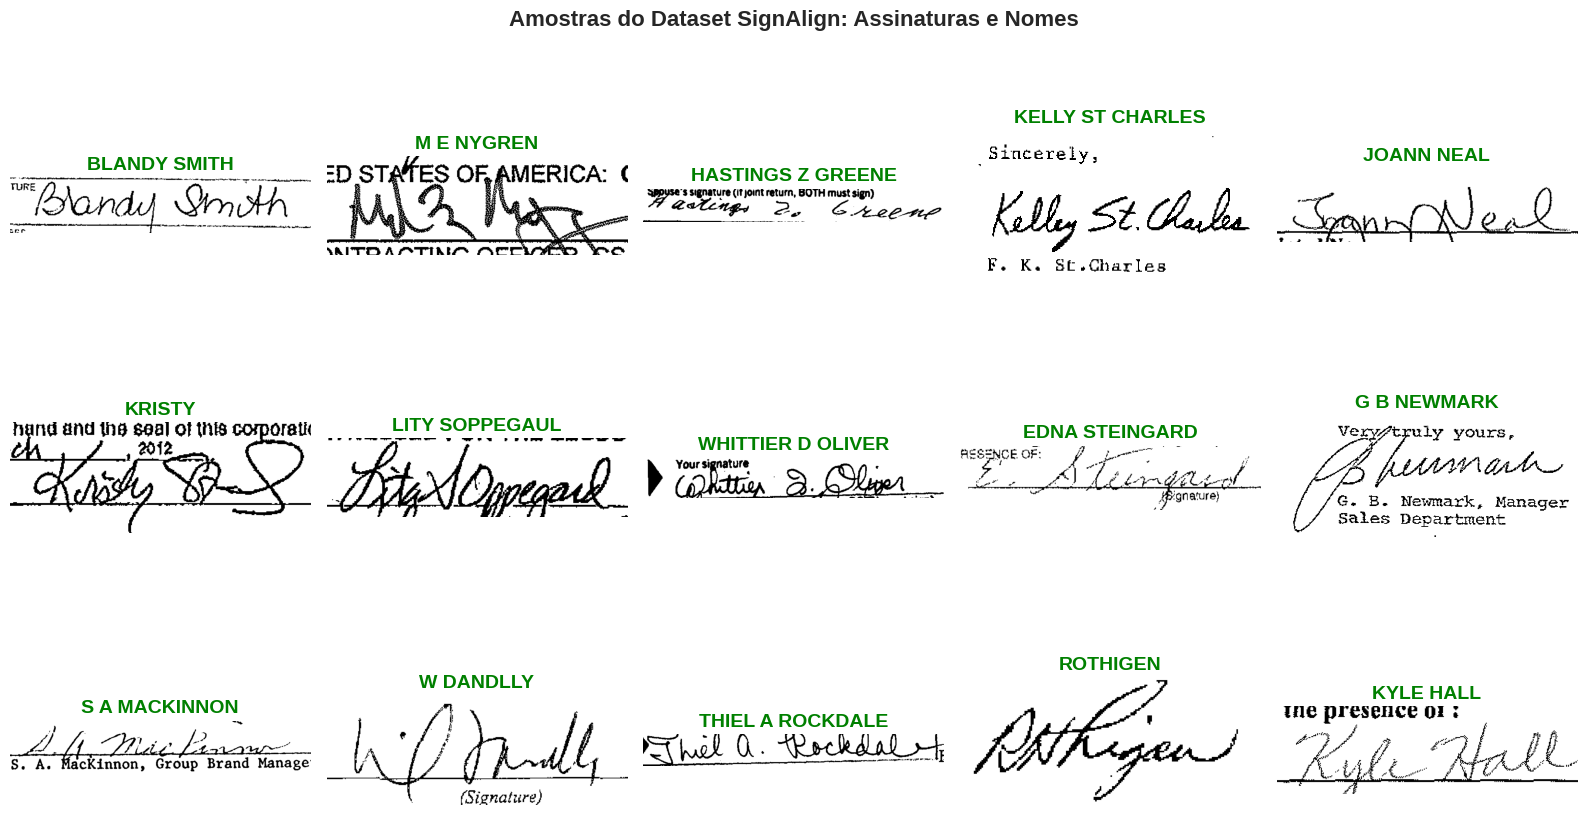

In [3]:
# Grid de Assinaturas 3x5 com nomes
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

def display_signature_grid(df, images_base_path, rows=3, cols=5, figsize=(16, 10), seed=42):
    """
    Exibe um grid de assinaturas com seus nomes correspondentes.
    
    Args:
        df: DataFrame com colunas human_name e image_path
        images_base_path: Caminho base para as imagens
        rows, cols: Dimensões do grid
        figsize: Tamanho da figura
        seed: Seed para amostragem aleatória
    """
    np.random.seed(seed)
    
    # Filtrar apenas assinaturas identificadas
    df_known = df[df['human_name'] != 'UNKNOWN'].copy()
    
    # Selecionar indivíduos únicos
    unique_individuals = df_known['human_name'].unique()
    n_samples = min(rows * cols, len(unique_individuals))
    selected_names = np.random.choice(unique_individuals, n_samples, replace=False)
    
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten()
    
    for idx, name in enumerate(selected_names):
        if idx >= rows * cols:
            break
            
        # Pegar uma amostra do indivíduo
        sample = df_known[df_known['human_name'] == name].sample(1).iloc[0]
        img_path = images_base_path / sample['image_path']
        
        try:
            img = Image.open(img_path).convert('RGB')
            axes[idx].imshow(img)
            
            # Formatar nome (quebrar se muito longo)
            display_name = name
            if len(name) > 20:
                words = name.split()
                if len(words) > 2:
                    display_name = ' '.join(words[:2]) + '\n' + ' '.join(words[2:])
            
            axes[idx].set_title(display_name, fontsize=14, fontweight='bold', wrap=True, color="green")
        except Exception as e:
            axes[idx].text(0.5, 0.7, f'Erro:\n{str(e)[:30]}', ha='center', va='center', fontsize=8)
        
        axes[idx].axis('off')
    
    # Esconder eixos vazios
    for idx in range(n_samples, rows * cols):
        axes[idx].axis('off')
    
    plt.suptitle('Amostras do Dataset SignAlign: Assinaturas e Nomes', 
                 fontsize=16, fontweight='bold', y=0.95)
    plt.tight_layout()
    
    # Salvar
    Path('article_outputs/img_dataset').mkdir(parents=True, exist_ok=True)
    plt.savefig('article_outputs/img_dataset/dataset_grid_3x5.png', dpi=150, bbox_inches='tight')
    plt.show()

# Carregar dataset
dataset_path = project_root / "datasets" / "dataset-sign-align" / "dataset.csv"
df_full_dataset = pd.read_csv(dataset_path)
images_base_path = project_root / "datasets" / "dataset-sign-align"

print(f"📊 Dataset carregado: {len(df_full_dataset)} amostras")
print(f"   - Identificadas: {len(df_full_dataset[df_full_dataset['human_name'] != 'UNKNOWN'])}")
print(f"   - UNKNOWN: {len(df_full_dataset[df_full_dataset['human_name'] == 'UNKNOWN'])}")
print(f"   - Indivíduos únicos: {df_full_dataset[df_full_dataset['human_name'] != 'UNKNOWN']['human_name'].nunique()}")

# Exibir grid
display_signature_grid(df_full_dataset, images_base_path, rows=3, cols=5, seed=2024)


### 1.2 Documentos com Múltiplas Assinaturas

Exemplo de documentos do dataset contendo múltiplas assinaturas - cenário relevante para a tarefa de recuperação.


📊 Documentos com múltiplas assinaturas: 1110
   Selecionados para exibição: 4


/tmp/ipykernel_11153/3291756053.py:77: UserWarning: Glyph 128196 (\N{PAGE FACING UP}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_11153/3291756053.py:77: UserWarning: Glyph 128101 (\N{BUSTS IN SILHOUETTE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_11153/3291756053.py:77: UserWarning: Glyph 128209 (\N{BOOKMARK TABS}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_11153/3291756053.py:80: UserWarning: Glyph 128196 (\N{PAGE FACING UP}) missing from font(s) Liberation Sans.
  plt.savefig('article_outputs/img_dataset/multi_signature_documents.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_11153/3291756053.py:80: UserWarning: Glyph 128101 (\N{BUSTS IN SILHOUETTE}) missing from font(s) Liberation Sans.
  plt.savefig('article_outputs/img_dataset/multi_signature_documents.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_11153/3291756053.py:80: UserWarning: Glyph 128209 (\N{BOOKMARK TABS}) missing from 

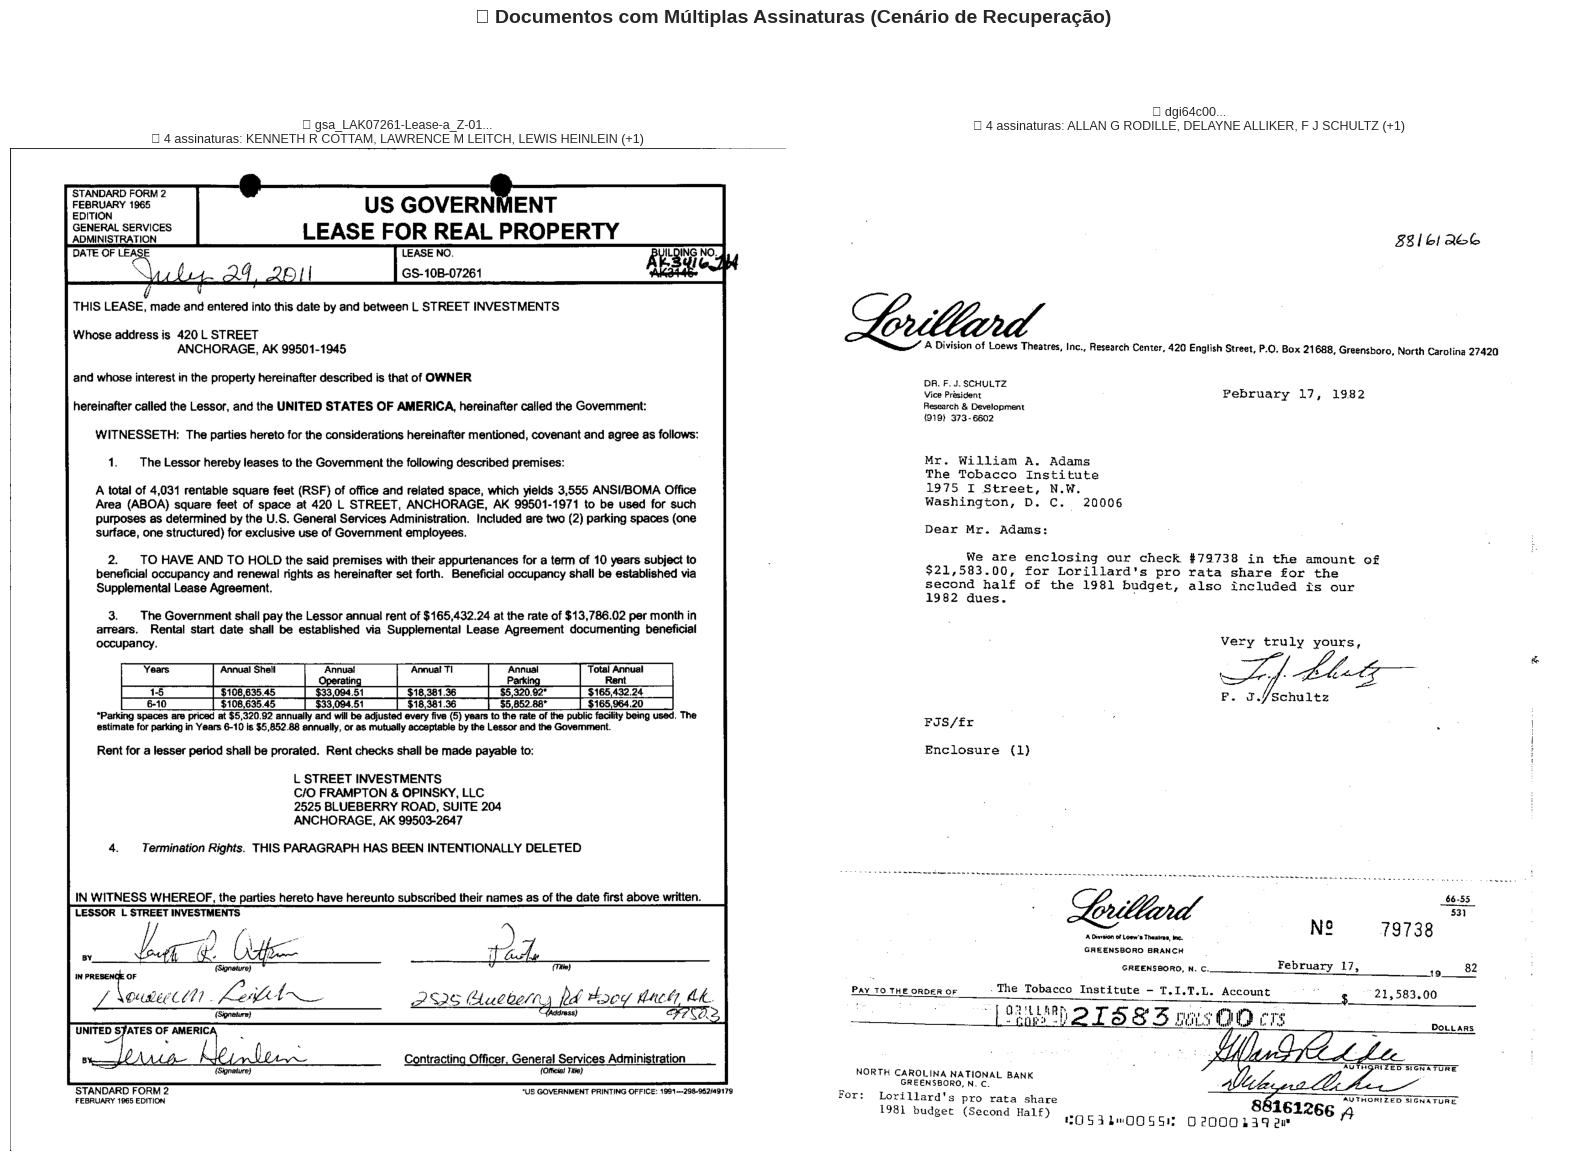


📊 Distribuição de assinaturas por documento:
   1 assinatura(s): 931 documentos
   2 assinatura(s): 693 documentos
   3 assinatura(s): 412 documentos
   4 assinatura(s): 5 documentos
   5 assinatura(s): 1 documentos
   >5 assinaturas: 4 documentos


In [4]:
# Exibir documentos com múltiplas assinaturas
def display_multi_signature_documents(df, images_base_path, n_docs=4, figsize=(16, 12)):
    """
    Exibe documentos que contêm múltiplas assinaturas.
    
    Args:
        df: DataFrame com colunas document, human_name, image_path
        images_base_path: Caminho base para as imagens
        n_docs: Número de documentos a exibir
        figsize: Tamanho da figura
    """
    # Filtrar assinaturas identificadas
    df_known = df[df['human_name'] != 'UNKNOWN'].copy()
    
    # Contar assinaturas únicas por documento
    doc_sig_counts = df_known.groupby('document')['human_name'].nunique().sort_values(ascending=False)
    
    # Selecionar documentos com múltiplas assinaturas (2-4 para melhor visualização)
    multi_sig_docs = doc_sig_counts[(doc_sig_counts >= 2) & (doc_sig_counts <= 4)]
    selected_docs = multi_sig_docs.head(n_docs).index.tolist()
    
    print(f"📊 Documentos com múltiplas assinaturas: {len(multi_sig_docs)}")
    print(f"   Selecionados para exibição: {n_docs}")
    
    # Criar figura
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    axes = axes.flatten()
    
    documents_path = images_base_path / "documents"
    
    for idx, doc_name in enumerate(selected_docs):
        if idx >= len(axes):
            break
        
        ax = axes[idx]
        
        # Tentar carregar imagem do documento
        doc_img_path = documents_path / f"{doc_name}.png"
        
        if doc_img_path.exists():
            try:
                doc_img = Image.open(doc_img_path).convert('RGB')
                ax.imshow(doc_img)
                
                # Obter nomes dos signatários
                signers = df_known[df_known['document'] == doc_name]['human_name'].unique()
                signer_list = ', '.join(signers[:3])
                if len(signers) > 3:
                    signer_list += f' (+{len(signers)-3})'
                
                ax.set_title(f"📄 {doc_name[:30]}...\n👥 {len(signers)} assinaturas: {signer_list}", 
                           fontsize=9, wrap=True)
            except Exception as e:
                ax.text(0.5, 0.5, f'Erro: {str(e)[:40]}', ha='center', va='center')
        else:
            # Mostrar as assinaturas individuais se não tiver o documento
            doc_sigs = df_known[df_known['document'] == doc_name]
            n_sigs = len(doc_sigs)
            
            # Criar subgrid para assinaturas
            ax.text(0.5, 0.9, f"📄 {doc_name[:25]}...\n({n_sigs} assinaturas)", 
                   ha='center', va='top', fontsize=10, transform=ax.transAxes)
            
            signers = doc_sigs['human_name'].unique()
            signer_text = '\n'.join([f"• {s}" for s in signers[:5]])
            ax.text(0.5, 0.5, signer_text, ha='center', va='center', fontsize=8, 
                   transform=ax.transAxes)
        
        ax.axis('off')
    
    # Esconder eixos não utilizados
    for idx in range(len(selected_docs), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('📑 Documentos com Múltiplas Assinaturas (Cenário de Recuperação)', 
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Salvar
    plt.savefig('article_outputs/img_dataset/multi_signature_documents.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Estatísticas de documentos
    print("\n📊 Distribuição de assinaturas por documento:")
    for n_sigs in range(1, 6):
        count = (doc_sig_counts == n_sigs).sum()
        if count > 0:
            print(f"   {n_sigs} assinatura(s): {count} documentos")
    count_more = (doc_sig_counts > 5).sum()
    if count_more > 0:
        print(f"   >5 assinaturas: {count_more} documentos")

# Exibir documentos
display_multi_signature_documents(df_full_dataset, images_base_path, n_docs=4)


### 1.3 Divergência entre Anotações Humanas e LLM

Análise comparativa entre rótulos atribuídos por humanos (`human_name`) e pelo LLM Gemini (`llm_name`).
O LLM foi usado para extrair nomes de documentos, mas apresenta inconsistências para o mesmo indivíduo.


📊 ANÁLISE DE DIVERGÊNCIA: Anotação Humana vs LLM (Gemini)

📈 Estatísticas Gerais:
   Total de amostras identificadas: 3647
   ✅ Nomes coincidentes: 1492 (40.9%)
   ❌ Nomes divergentes: 2155 (59.1%)

👥 Indivíduos com inconsistências: 199

🔍 Caso Selecionado: ALFRED X MORGAN
   Amostras: 38
   Nomes LLM: ['ALFRED X MORGAN', 'FRIED X MORGAN', 'REFUGIO R MOYA', 'ALFRED K MORGAN', 'APRIL R MCGRAGAN', 'REED L MORGAN', 'ALFRED K MORGAIN', 'FREED X MORGAN', 'PIERCE L MORGAN', 'HPRECS K MORGAN', 'APRILE R MORGAN', 'LORECK R THORPE', 'APRICE R MCGOGAN', 'UNKNOWN', 'REED X MORGAN', 'SPRECK P MORGAN', 'ALFRED T MORGAN', 'FRED X MORGAN']
ALFRED T MORGAN
/home/lucas/Documentos/PósGaduação/UFPR/Mestrado/Projeto/Experimentos/SigAlignGit/datasets/dataset-sign-align/signatures/nist_r0748_01_sign3.png


FRIED X MORGAN
/home/lucas/Documentos/PósGaduação/UFPR/Mestrado/Projeto/Experimentos/SigAlignGit/datasets/dataset-sign-align/signatures/nist_r0752_01_sign1.png
FRED X MORGAN
/home/lucas/Documentos/PósGaduação/UFPR/Mestrado/Projeto/Experimentos/SigAlignGit/datasets/dataset-sign-align/signatures/nist_r0762_01_sign1.png
UNKNOWN
/home/lucas/Documentos/PósGaduação/UFPR/Mestrado/Projeto/Experimentos/SigAlignGit/datasets/dataset-sign-align/signatures/nist_r0764_01_sign2.png
ALFRED X MORGAN
/home/lucas/Documentos/PósGaduação/UFPR/Mestrado/Projeto/Experimentos/SigAlignGit/datasets/dataset-sign-align/signatures/nist_r0844_01_sign2.png
FREED X MORGAN
/home/lucas/Documentos/PósGaduação/UFPR/Mestrado/Projeto/Experimentos/SigAlignGit/datasets/dataset-sign-align/signatures/nist_r0892_01_sign1.png


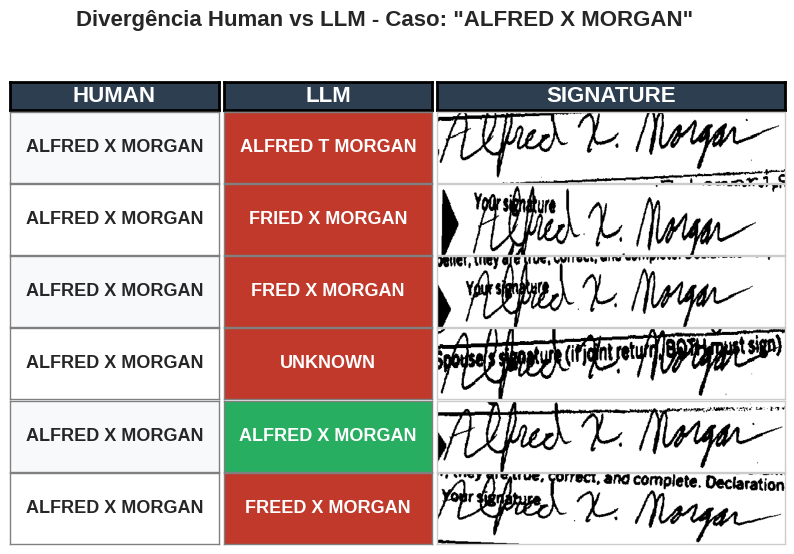


📊 TOP 10 INDIVÍDUOS COM MAIOR DIVERGÊNCIA:


,Nome Humano,Amostras,Nomes LLM Únicos,Taxa Divergência
589,ROBERT SCOTT,59,43,93.2%
136,DEBORAH D ORKOWSKI,50,13,24.0%
9,ALFRED X MORGAN,38,18,55.3%
188,ERIN H WINSCHEL,35,35,97.1%
542,R DUNE WOOD,31,31,96.8%
193,ERSKINE W MITCHELL,30,12,36.7%
141,DELTA K AURON,29,17,96.6%
387,KENDALL V LAMAR,29,12,37.9%
432,LORAS F BROWN,29,11,75.9%
520,PAST O DALE,29,25,100.0%


In [5]:
# Análise de Divergência: Human vs LLM - Formato Tabela
def analyze_human_llm_divergence_table(df, images_base_path, n_rows=6, figsize=(10, 6)):
    """
    Visualiza divergências em formato de tabela: HUMAN | LLM | SIGNATURE
    """
    # Filtrar amostras identificadas (não UNKNOWN)
    df_known = df[df['human_name'] != 'UNKNOWN'].copy()
    
    # Calcular divergência
    df_known['human_clean'] = df_known['human_name'].str.upper().str.strip()
    df_known['llm_clean'] = df_known['llm_name'].str.upper().str.strip()
    df_known['names_match'] = df_known['human_clean'] == df_known['llm_clean']
    
    # Estatísticas gerais
    total = len(df_known)
    matches = df_known['names_match'].sum()
    divergences = total - matches
    
    print("=" * 70)
    print("📊 ANÁLISE DE DIVERGÊNCIA: Anotação Humana vs LLM (Gemini)")
    print("=" * 70)
    print(f"\n📈 Estatísticas Gerais:")
    print(f"   Total de amostras identificadas: {total}")
    print(f"   ✅ Nomes coincidentes: {matches} ({100*matches/total:.1f}%)")
    print(f"   ❌ Nomes divergentes: {divergences} ({100*divergences/total:.1f}%)")
    
    # Encontrar um caso de divergência interessante
    person_divergence = df_known.groupby('human_name').agg({
        'llm_name': ['nunique', 'count', lambda x: list(x.unique())],
        'names_match': 'sum'
    }).reset_index()
    person_divergence.columns = ['human_name', 'unique_llm_names', 'total_samples', 'llm_names_list', 'correct_matches']
    person_divergence['divergence_rate'] = 1 - (person_divergence['correct_matches'] / person_divergence['total_samples'])
    
    # Filtrar pessoas com divergências
    interesting_cases = person_divergence[
        (person_divergence['total_samples'] >= 3) & 
        (person_divergence['divergence_rate'] > 0)
    ].sort_values('total_samples', ascending=False)
    
    print(f"\n👥 Indivíduos com inconsistências: {len(interesting_cases)}")
    
    if len(interesting_cases) == 0:
        print("   Nenhum caso encontrado.")
        return df_known
    
    # Selecionar caso
    selected_person = interesting_cases.iloc[2]
    human_name = selected_person['human_name']
    person_samples = df_known[df_known['human_name'] == human_name].tail(n_rows)
    n_samples = len(person_samples)
    
    print(f"\n🔍 Caso Selecionado: {human_name}")
    print(f"   Amostras: {selected_person['total_samples']}")
    print(f"   Nomes LLM: {selected_person['llm_names_list']}")
    
    # ============================================
    # VISUALIZAÇÃO EM FORMATO TABELA
    # ============================================
    
    # Criar figura com GridSpec para controle preciso
    fig = plt.figure(figsize=figsize)
    
    # Proporções: header menor, dados maiores
    height_ratios = [0.4] + [1.0] * n_samples
    gs = fig.add_gridspec(n_samples + 1, 3, 
                          width_ratios=[1.2, 1.2, 2],
                          height_ratios=height_ratios,
                          hspace=0.02, wspace=0.02)
    
    # Cores
    header_color = '#2C3E50'
    match_color = '#27AE60'
    diverge_color = '#C0392B'
    
    # ---- CABEÇALHO ----
    headers = ['HUMAN', 'LLM', 'SIGNATURE']
    for col, header in enumerate(headers):
        ax = fig.add_subplot(gs[0, col])
        ax.set_facecolor(header_color)
        ax.text(0.5, 0.5, header, fontsize=16, fontweight='bold', color='white',
                ha='center', va='center')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xticks([])
        ax.set_yticks([])
        # Borda preta
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color('black')
            spine.set_linewidth(2)
    
    # ---- LINHAS DE DADOS ----
    for row_idx, (_, sample) in enumerate(person_samples.iterrows()):
        row_num = row_idx + 1  # +1 por causa do header
        is_match = sample['names_match']
        bg_color = '#F8F9FA' if row_idx % 2 == 0 else '#FFFFFF'
        
        # Coluna HUMAN
        ax_human = fig.add_subplot(gs[row_num, 0])
        ax_human.set_facecolor(bg_color)
        # Quebrar nome se muito longo
        human_text = sample['human_name']
        if len(human_text) > 20:
            human_text = human_text[:20] + "..."
        ax_human.text(0.5, 0.5, human_text, fontsize=13, fontweight='bold',
                     ha='center', va='center')
        ax_human.set_xlim(0, 1)
        ax_human.set_ylim(0, 1)
        ax_human.set_xticks([])
        ax_human.set_yticks([])
        for spine in ax_human.spines.values():
            spine.set_visible(True)
            spine.set_color('gray')
            spine.set_linewidth(1)
        
        # Coluna LLM - com cor de fundo indicando match/divergência
        ax_llm = fig.add_subplot(gs[row_num, 1])
        llm_bg = match_color if is_match else diverge_color
        ax_llm.set_facecolor(llm_bg)
        
        # Nome do LLM com status
        llm_text = sample['llm_name']
        if len(llm_text) > 20:
            llm_text = llm_text[:20] + "..."

        ax_llm.text(0.5, 0.5,  llm_text, fontsize=13, fontweight='bold',
                   ha='center', va='center', color='white')
        ax_llm.set_xlim(0, 1)
        ax_llm.set_ylim(0, 1)
        ax_llm.set_xticks([])
        ax_llm.set_yticks([])
        for spine in ax_llm.spines.values():
            spine.set_visible(True)
            spine.set_color('gray')
            spine.set_linewidth(1)
        
        # Coluna SIGNATURE (imagem)
        ax_img = fig.add_subplot(gs[row_num, 2])
        ax_img.set_facecolor(bg_color)
        
        img_path = images_base_path / sample['image_path']
        try:
            print(llm_text)
            print(img_path)
            img = Image.open(img_path).convert('RGB')
            ax_img.imshow(img, aspect='auto')
        except:
            ax_img.text(0.5, 0.5, 'Imagem não encontrada', ha='center', va='center', fontsize=10)
        
        ax_img.set_xticks([])
        ax_img.set_yticks([])
        
        # Borda colorida na imagem
        #border_color = match_color if is_match else diverge_color
        #for spine in ax_img.spines.values():
        #    spine.set_visible(True)
        #    spine.set_color(border_color)
        #    spine.set_linewidth(4)
    
    plt.suptitle(f'Divergência Human vs LLM - Caso: "{human_name}"', 
                fontsize=16, fontweight='bold', y=1)
    
    plt.savefig('article_outputs/img_dataset/human_vs_llm_divergence_table.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # ============================================
    # TOP DIVERGENTES
    # ============================================
    print("\n📊 TOP 10 INDIVÍDUOS COM MAIOR DIVERGÊNCIA:")
    top_divergent = interesting_cases.head(10)[['human_name', 'total_samples', 'unique_llm_names', 'divergence_rate']].copy()
    top_divergent['divergence_rate'] = (top_divergent['divergence_rate'] * 100).round(1).astype(str) + '%'
    top_divergent.columns = ['Nome Humano', 'Amostras', 'Nomes LLM Únicos', 'Taxa Divergência']
    display(top_divergent)
    
    return df_known

# Executar análise em formato tabela
df_divergence = analyze_human_llm_divergence_table(df_full_dataset, images_base_path, n_rows=6)


### 1.4 Visualização das Aumentações de Dados

Tabela mostrando cada tipo de aumentação aplicada durante o treinamento.

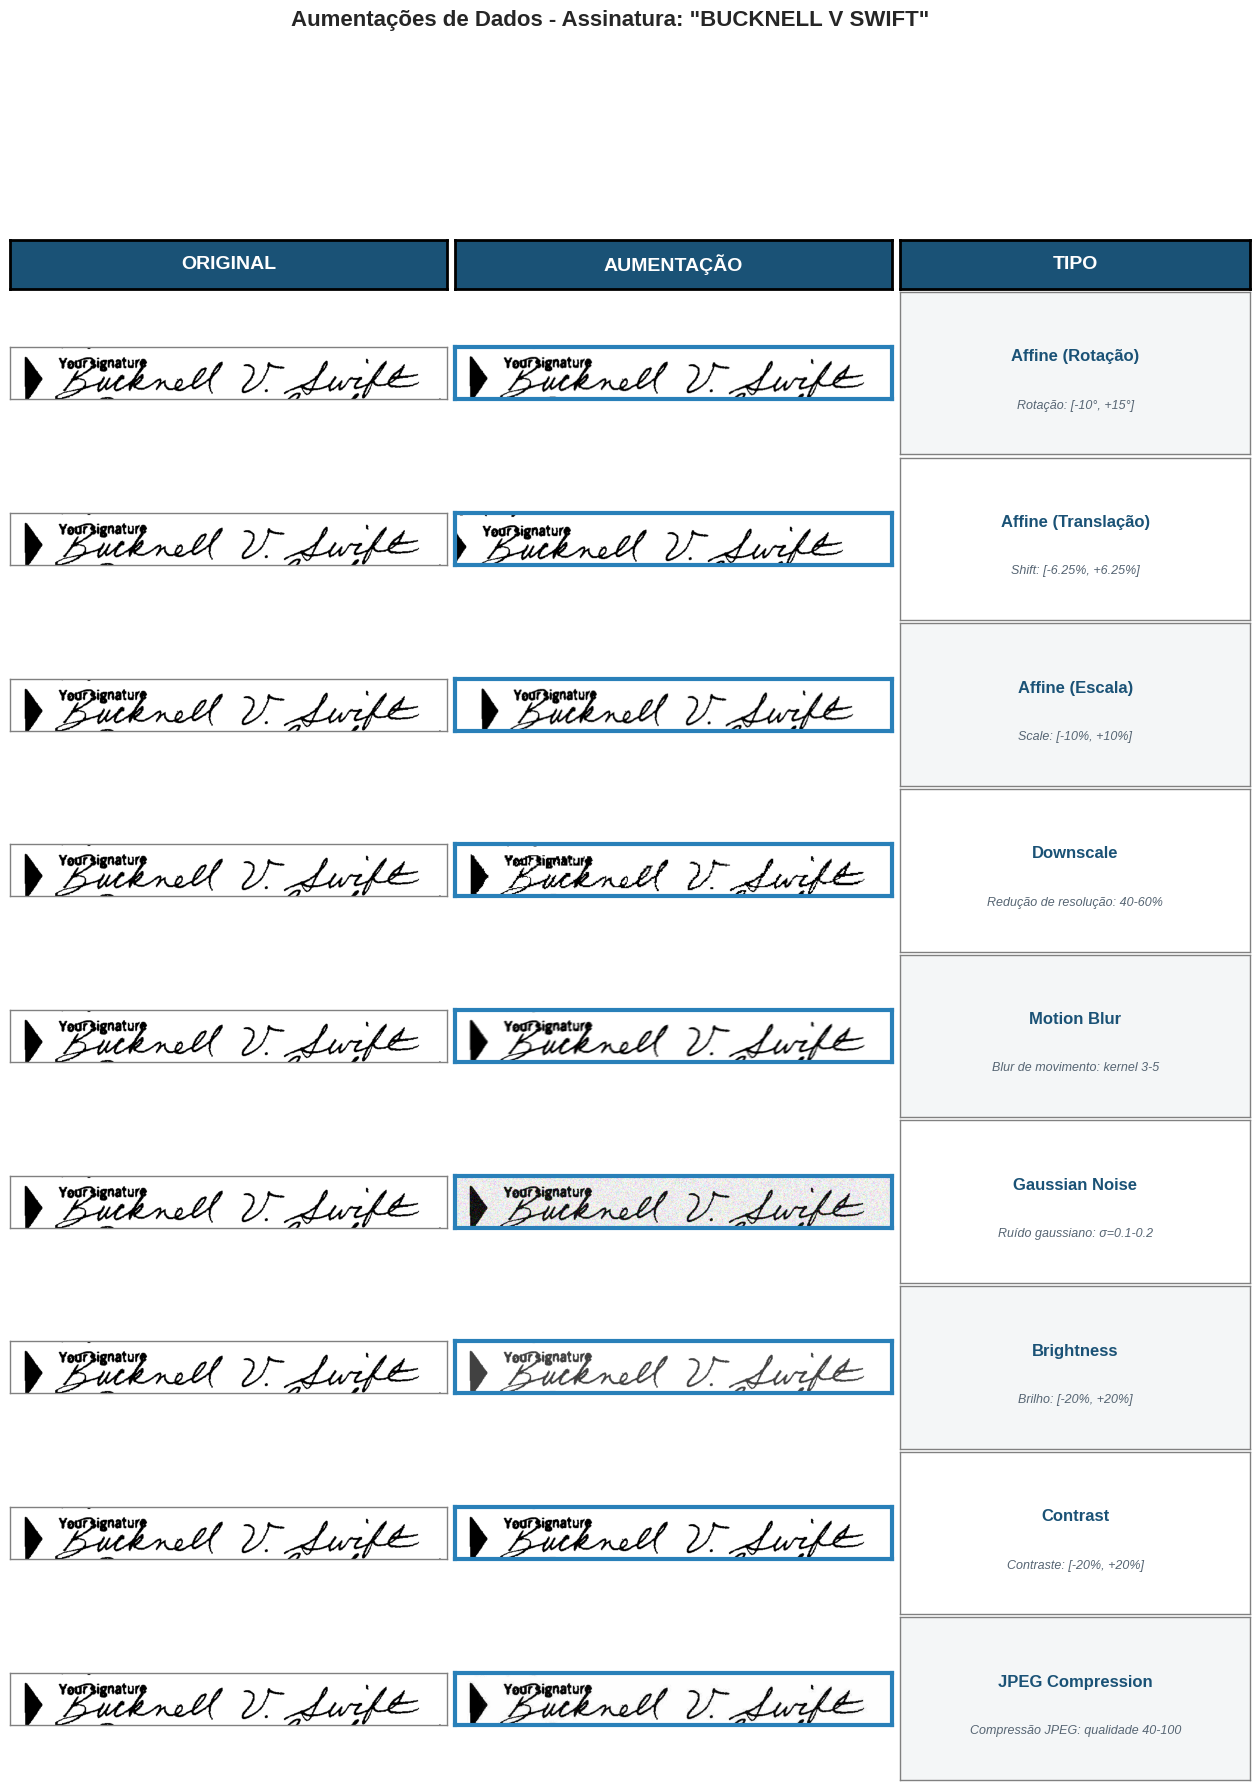


📋 RESUMO DAS AUMENTAÇÕES:
  • Affine (Rotação)     - Rotação: [-10°, +15°]
  • Affine (Translação)  - Shift: [-6.25%, +6.25%]
  • Affine (Escala)      - Scale: [-10%, +10%]
  • Downscale            - Redução de resolução: 40-60%
  • Motion Blur          - Blur de movimento: kernel 3-5
  • Gaussian Noise       - Ruído gaussiano: σ=0.1-0.2
  • Brightness           - Brilho: [-20%, +20%]
  • Contrast             - Contraste: [-20%, +20%]
  • JPEG Compression     - Compressão JPEG: qualidade 40-100

Probabilidades durante treinamento:
  • Geométricas (Affine/Downscale): p=0.2
  • Blur/Noise: p=0.2
  • Brightness/Contrast: p=0.2
  • Compressão JPEG: p=0.2


In [6]:
# Visualização das Aumentações de Dados em Formato Tabela
import albumentations as A
import cv2
import numpy as np

def visualize_augmentations_table(df, images_base_path, figsize=(16, 20)):
    """
    Visualiza cada tipo de aumentação em formato de tabela:
    ORIGINAL | AUMENTAÇÃO | TIPO
    """
    # Pegar uma imagem de exemplo
    sample = df[df['human_name'] != 'UNKNOWN'].sample(1, random_state=42).iloc[0]
    img_path = images_base_path / sample['image_path']
    
    # Carregar imagem original
    original_img = np.array(Image.open(img_path).convert('RGB'))
    
    # Definir cada augmentação individualmente para visualização
    augmentations = [
        {
            "name": "Affine (Rotação)",
            "transform": A.Affine(rotate=(-15, 15), p=1.0, border_mode=cv2.BORDER_CONSTANT, fill=255),
            "description": "Rotação: [-10°, +15°]"
        },
        {
            "name": "Affine (Translação)",
            "transform": A.Affine(translate_percent={"x": (-0.1, 0.1), "y": (-0.1, 0.1)}, p=1.0, 
                                  border_mode=cv2.BORDER_CONSTANT, fill=255),
            "description": "Shift: [-6.25%, +6.25%]"
        },
        {
            "name": "Affine (Escala)",
            "transform": A.Affine(scale=(0.9, 1.1), p=1.0, border_mode=cv2.BORDER_CONSTANT, fill=255),
            "description": "Scale: [-10%, +10%]"
        },
        {
            "name": "Downscale",
            "transform": A.Downscale(scale_range=(0.4, 0.6), p=1.0),
            "description": "Redução de resolução: 40-60%"
        },
        {
            "name": "Motion Blur",
            "transform": A.MotionBlur(blur_limit=(5, 7), p=1.0),
            "description": "Blur de movimento: kernel 3-5"
        },
        {
            "name": "Gaussian Noise",
            "transform": A.GaussNoise(std_range=(0.15, 0.25), p=1.0),
            "description": "Ruído gaussiano: σ=0.1-0.2"
        },
        {
            "name": "Brightness",
            "transform": A.RandomBrightnessContrast(brightness_limit=(0.2, 0.3), contrast_limit=(0, 0), p=1.0),
            "description": "Brilho: [-20%, +20%]"
        },
        {
            "name": "Contrast",
            "transform": A.RandomBrightnessContrast(brightness_limit=(0, 0), contrast_limit=(0.2, 0.3), p=1.0),
            "description": "Contraste: [-20%, +20%]"
        },
        {
            "name": "JPEG Compression",
            "transform": A.ImageCompression(quality_range=(30, 50), p=1.0),
            "description": "Compressão JPEG: qualidade 40-100"
        },
    ]
    
    n_augs = len(augmentations)
    
    # Criar figura
    fig = plt.figure(figsize=figsize)
    
    # Proporções
    height_ratios = [0.3] + [1.0] * n_augs
    gs = fig.add_gridspec(n_augs + 1, 3, 
                          width_ratios=[1.5, 1.5, 1.2],
                          height_ratios=height_ratios,
                          hspace=0.02, wspace=0.02)
    
    # Cores
    header_color = '#1A5276'
    
    # ---- CABEÇALHO ----
    headers = ['ORIGINAL', 'AUMENTAÇÃO', 'TIPO']
    for col, header in enumerate(headers):
        ax = fig.add_subplot(gs[0, col])
        ax.set_facecolor(header_color)
        ax.text(0.5, 0.5, header, fontsize=14, fontweight='bold', color='white',
                ha='center', va='center')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color('black')
            spine.set_linewidth(2)
    
    # ---- LINHAS DE DADOS ----
    np.random.seed(42)
    
    for row_idx, aug_info in enumerate(augmentations):
        row_num = row_idx + 1
        bg_color = '#F4F6F7' if row_idx % 2 == 0 else '#FFFFFF'
        
        # Aplicar augmentação
        augmented = aug_info["transform"](image=original_img)["image"]
        
        # Coluna ORIGINAL
        ax_orig = fig.add_subplot(gs[row_num, 0])
        ax_orig.imshow(original_img)
        ax_orig.set_xticks([])
        ax_orig.set_yticks([])
        for spine in ax_orig.spines.values():
            spine.set_visible(True)
            spine.set_color('gray')
            spine.set_linewidth(1)
        
        # Coluna AUMENTAÇÃO
        ax_aug = fig.add_subplot(gs[row_num, 1])
        ax_aug.imshow(augmented)
        ax_aug.set_xticks([])
        ax_aug.set_yticks([])
        for spine in ax_aug.spines.values():
            spine.set_visible(True)
            spine.set_color('#2980B9')
            spine.set_linewidth(3)
        
        # Coluna TIPO
        ax_type = fig.add_subplot(gs[row_num, 2])
        ax_type.set_facecolor(bg_color)
        
        # Nome e descrição
        ax_type.text(0.5, 0.6, aug_info["name"], fontsize=12, fontweight='bold',
                    ha='center', va='center', color='#1A5276')
        ax_type.text(0.5, 0.3, aug_info["description"], fontsize=9,
                    ha='center', va='center', color='#566573', style='italic')
        
        ax_type.set_xlim(0, 1)
        ax_type.set_ylim(0, 1)
        ax_type.set_xticks([])
        ax_type.set_yticks([])
        for spine in ax_type.spines.values():
            spine.set_visible(True)
            spine.set_color('gray')
            spine.set_linewidth(1)
    
    plt.suptitle(f'Aumentações de Dados - Assinatura: "{sample["human_name"]}"', 
                fontsize=16, fontweight='bold', y=0.995)
    
    plt.savefig('article_outputs/img_dataset/data_augmentations_table.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Tabela resumo
    print("\n📋 RESUMO DAS AUMENTAÇÕES:")
    print("=" * 70)
    for aug in augmentations:
        print(f"  • {aug['name']:20s} - {aug['description']}")
    print("=" * 70)
    print("\nProbabilidades durante treinamento:")
    print("  • Geométricas (Affine/Downscale): p=0.2")
    print("  • Blur/Noise: p=0.2")
    print("  • Brightness/Contrast: p=0.2")
    print("  • Compressão JPEG: p=0.2")

# Executar visualização
visualize_augmentations_table(df_full_dataset, images_base_path)


---
# 📝 Análise para o Artigo (USANDO MÉTRICAS DE TESTE)

## Questões de Pesquisa:

1. **RQ1**: Vale a pena fazer fine-tuning? (Frozen vs Finetuned)
2. **RQ2**: Qual arquitetura é melhor? (TinyCLIP vs CLIP vs SigLIP)
3. **RQ3**: Qual a influência da loss combinada com triplet?
4. **RQ4**: A triplet loss melhora a separação de embeddings?
5. **RQ5**: Qual a influência da augmentação de dados?
6. **RQ6**: Qual o melhor modelo final?


### RQ1: Vale a pena fazer Fine-tuning?
Comparação entre modelos frozen (pré-treinados sem ajuste) vs finetuned (com ajuste fino)


📊 RQ1: IMPACTO DO FINE-TUNING (MÉTRICAS DE TESTE)


,Arquitetura,Acc@1neg (Frozen),Acc@1neg (Finetuned),Δ Acc@1neg,Acc@2neg (Frozen),Acc@2neg (Finetuned),Δ Acc@2neg,Acc@3neg (Frozen),Acc@3neg (Finetuned),Δ Acc@3neg
0,TinyCLIP,0.9165 ± 0.0099,0.9687 ± 0.0132,+0.0522,0.8643 ± 0.0479,0.9478 ± 0.0123,+0.0835,0.8296 ± 0.0401,0.9304 ± 0.0238,+0.1009
1,CLIP-B/32,0.8852 ± 0.0129,0.9739 ± 0.0137,+0.0887,0.8052 ± 0.0340,0.9409 ± 0.0156,+0.1357,0.7722 ± 0.0371,0.9148 ± 0.0129,+0.1426
2,SigLIP,0.5791 ± 0.0235,0.9513 ± 0.0235,+0.3722,0.3930 ± 0.0339,0.9043 ± 0.0254,+0.5113,0.3200 ± 0.0333,0.8643 ± 0.0170,+0.5443


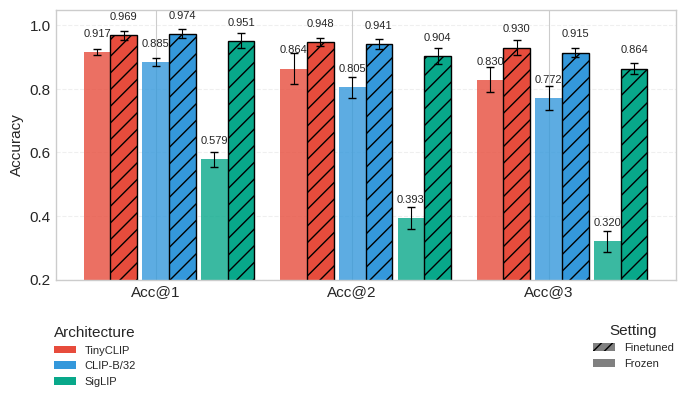

In [55]:
# RQ1: Fine-tuning vs Frozen (MÉTRICAS DE TESTE)
def analyze_finetuning_impact():
    """Analisa o impacto do fine-tuning usando MÉTRICAS DE TESTE."""
    
    frozen = df_experiments[~df_experiments["finetuned"]].copy()
    finetuned = df_experiments[df_experiments["finetuned"]].copy()
    
    baseline_finetuned = finetuned[
        (~finetuned["has_triplet"]) & 
        (~finetuned["has_augmentation"])
    ].copy()
    
    print("=" * 80)
    print("📊 RQ1: IMPACTO DO FINE-TUNING (MÉTRICAS DE TESTE)")
    print("=" * 80)
    
    metrics = ["test_accuracy_1_neg", "test_accuracy_2_neg", "test_accuracy_3_neg"]
    metric_labels = ["Acc@1neg", "Acc@2neg", "Acc@3neg"]
    
    results = []
    for arch in ["TinyCLIP", "CLIP-B/32", "SigLIP"]:
        frozen_arch = frozen[frozen["architecture"] == arch]
        finetuned_arch = baseline_finetuned[baseline_finetuned["architecture"] == arch]
        
        if len(frozen_arch) > 0 and len(finetuned_arch) > 0:
            row = {"Arquitetura": arch}
            for metric, label in zip(metrics, metric_labels):
                frozen_val, frozen_std = ms(frozen_arch, metric)
                finetuned_val, finetuned_std = ms(finetuned_arch, metric)
                
                row[f"{label} (Frozen)"] = fmt_pm(frozen_val, frozen_std) if pd.notna(frozen_val) else "N/A"
                row[f"{label} (Finetuned)"] = fmt_pm(finetuned_val, finetuned_std) if pd.notna(finetuned_val) else "N/A"
                # valores numéricos (média/desvio) p/ o gráfico com barras de erro
                row[f"{label} (Frozen)_mean"] = frozen_val
                row[f"{label} (Finetuned)_mean"] = finetuned_val
                row[f"{label} (Frozen)_std"] = frozen_std
                row[f"{label} (Finetuned)_std"] = finetuned_std
                
                if pd.notna(frozen_val) and pd.notna(finetuned_val):
                    delta = finetuned_val - frozen_val
                    row[f"Δ {label}"] = f"{delta:+.4f}"
            
            results.append(row)
    
    df_results = pd.DataFrame(results)
    # exibir só as colunas legíveis (média ± desvio), ocultando as auxiliares numéricas
    show_cols = [c for c in df_results.columns
                 if not (c.endswith("_mean") or c.endswith("_std"))]
    display(df_results[show_cols])
    
    return df_results

def plot_finetuning_clean(df_results):
    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.patches import Patch

    colors = {
        "TinyCLIP": "#e74c3c",
        "CLIP-B/32": "#3498db",
        "SigLIP": "#08A88A"
    }

    ks = [1, 2, 3]
    group_gap = 1.4  # 🔥 aumenta espaço entre Acc@k
    x = np.arange(len(ks)) * group_gap

    width = 0.19  # 🔥 consistente com augment

    fig, ax = plt.subplots(figsize=(8, 4.5))

    architectures = df_results["Arquitetura"].tolist()

    for i, arch in enumerate(architectures):
        row = df_results.iloc[i]

        # 🔥 evita sobreposição entre grupos
        offset = (i - 1) * 2.2 * width

        frozen_vals = [float(row[f"Acc@{k}neg (Frozen)_mean"]) for k in ks]
        ft_vals     = [float(row[f"Acc@{k}neg (Finetuned)_mean"]) for k in ks]
        frozen_errs = [float(row.get(f"Acc@{k}neg (Frozen)_std", 0) or 0) for k in ks]
        ft_errs     = [float(row.get(f"Acc@{k}neg (Finetuned)_std", 0) or 0) for k in ks]

        # Frozen (base)
        bars_frozen = ax.bar(
            x + offset,
            frozen_vals,
            width,
            yerr=frozen_errs,
            capsize=3,
            error_kw={"elinewidth": 0.8},
            color=colors[arch],
            alpha=0.8
        )

        # Finetuned (destaque)
        bars_ft = ax.bar(
            x + offset + width,
            ft_vals,
            width,
            yerr=ft_errs,
            capsize=3,
            error_kw={"elinewidth": 0.8},
            color=colors[arch],
            hatch='//',
            edgecolor='black'
        )

        # labels (evitando sobreposição)
        for bars in [bars_frozen, bars_ft]:
            for bar in bars:
                height = bar.get_height()
                ax.annotate(
                    f"{height:.3f}",
                    xy=(bar.get_x() + bar.get_width()/2, height + 0.025),
                    xytext=(0, 4),
                    textcoords="offset points",
                    ha='center',
                    va='bottom',
                    fontsize=8
                )

    # eixo X
    ax.set_xticks(x)
    ax.set_xticklabels([f"Acc@{k}" for k in ks])

    ax.set_ylabel("Accuracy")
    ax.set_ylim(0.2, 1.05)

    ax.grid(axis='y', linestyle='--', alpha=0.3)

    # espaço para legendas
    plt.subplots_adjust(bottom=0.28)

    # =========================
    # 🔵 ARQUITETURAS (ESQUERDA)
    # =========================
    arch_legend = [
        Patch(facecolor=colors["TinyCLIP"], label="TinyCLIP"),
        Patch(facecolor=colors["CLIP-B/32"], label="CLIP-B/32"),
        Patch(facecolor=colors["SigLIP"], label="SigLIP")
    ]

    fig.legend(
        handles=arch_legend,
        loc='lower left',
        bbox_to_anchor=(0.11, 0.02),
        fontsize=8,
        title="Architecture"
    )

    # =========================
    # 🔳 SETTING (DIREITA)
    # =========================
    setting_legend = [
        Patch(facecolor='gray', hatch='///', label="Finetuned"),
        Patch(facecolor='gray', label="Frozen")
    ]

    fig.legend(
        handles=setting_legend,
        loc='lower right',
        bbox_to_anchor=(0.91, 0.06),
        fontsize=8,
        title="Setting"
    )

    #plt.title("Effect of Fine-tuning on Retrieval Accuracy", fontsize=12)

    plt.savefig(
        "article_outputs/img_metrics/rq1_finetuning_clean.pdf",
        format="pdf",
        bbox_inches='tight'
    )

    plt.show()


rq1_results = analyze_finetuning_impact()
plot_finetuning_clean(rq1_results)

### RQ2: Qual arquitetura é a melhor?
Comparação entre TinyCLIP, CLIP-B/32 e SigLIP considerando apenas modelos finetuned baseline


📊 RQ2: COMPARAÇÃO DE ARQUITETURAS (MÉTRICAS DE TESTE)

📈 Resultados Baseline (Finetuned, sem Triplet, com Augmentação) - TESTE:


,Arquitetura,Loss,Acc@1neg,Acc@2neg,Acc@3neg,MRR@1neg,MRR@2neg,MRR@3neg
0,TinyCLIP,infonce,0.979130,0.953043,0.946087,0.989565,0.974203,0.968841
1,CLIP-B/32,infonce,0.979130,0.958261,0.940870,0.989565,0.977391,0.966957
2,SigLIP,sigmoid,0.951304,0.906087,0.880000,0.975652,0.949855,0.934928


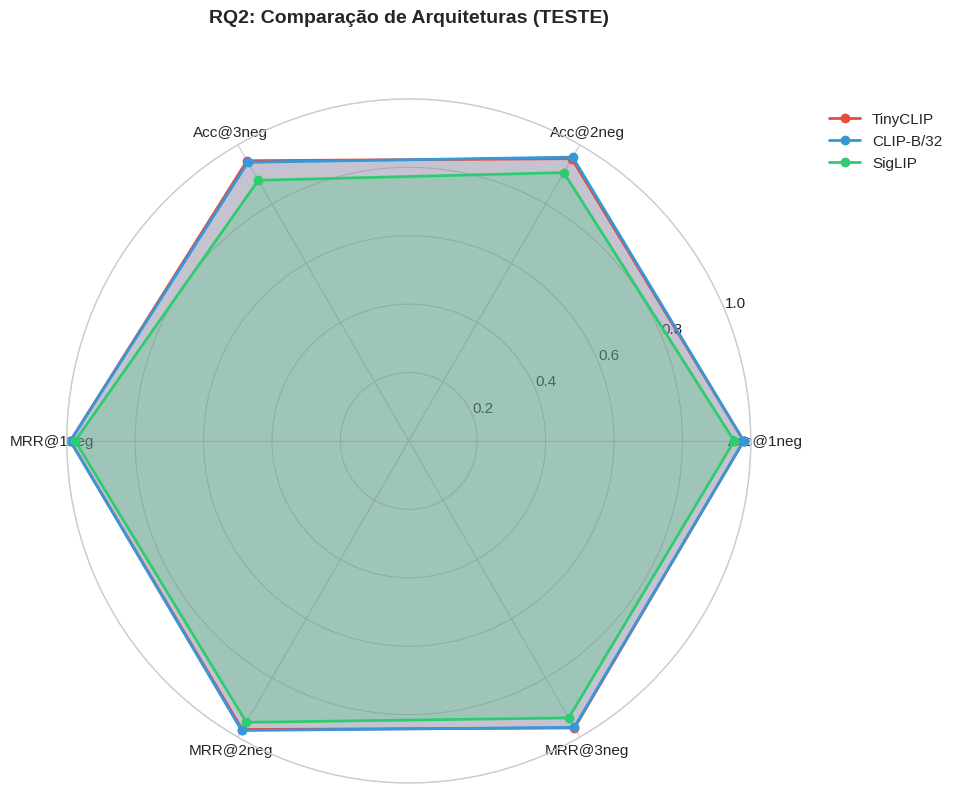


🏆 Melhor arquitetura (Acc@3neg no TESTE): TinyCLIP


In [8]:
# RQ2: Comparação de Arquiteturas (MÉTRICAS DE TESTE)
def analyze_architectures():
    """Compara as diferentes arquiteturas usando MÉTRICAS DE TESTE."""
    
    baseline = df_experiments[
        (df_experiments["finetuned"]) & 
        (~df_experiments["has_triplet"]) & 
        (df_experiments["has_augmentation"])
    ].copy()
    
    print("=" * 80)
    print("📊 RQ2: COMPARAÇÃO DE ARQUITETURAS (MÉTRICAS DE TESTE)")
    print("=" * 80)
    
    metrics = {
        "test_accuracy_1_neg": "Acc@1neg",
        "test_accuracy_2_neg": "Acc@2neg", 
        "test_accuracy_3_neg": "Acc@3neg",
        "test_mrr_1_neg": "MRR@1neg",
        "test_mrr_2_neg": "MRR@2neg",
        "test_mrr_3_neg": "MRR@3neg"
    }
    
    results = []
    for arch in ["TinyCLIP", "CLIP-B/32", "SigLIP"]:
        arch_data = baseline[baseline["architecture"] == arch]
        if len(arch_data) > 0:
            row = {"Arquitetura": arch, "Loss": arch_data["loss_type"].values[0]}
            for metric, label in metrics.items():
                if metric in arch_data.columns:
                    row[label] = arch_data[metric].values[0]
            results.append(row)
    
    df_results = pd.DataFrame(results)
    
    print("\n📈 Resultados Baseline (Finetuned, sem Triplet, com Augmentação) - TESTE:")
    display(df_results.style.highlight_max(subset=list(metrics.values()), color='lightgreen'))
    
    # Visualização radar chart
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection='polar'))
    
    categories = ["Acc@1neg", "Acc@2neg", "Acc@3neg", "MRR@1neg", "MRR@2neg", "MRR@3neg"]
    num_vars = len(categories)
    angles = [n / float(num_vars) * 2 * np.pi for n in range(num_vars)]
    angles += angles[:1]
    
    colors = ['#e74c3c', '#3498db', '#2ecc71']
    
    for idx, row in df_results.iterrows():
        values = [row.get(cat, 0) for cat in categories]
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=row["Arquitetura"], color=colors[idx])
        ax.fill(angles, values, alpha=0.25, color=colors[idx])
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=11)
    ax.set_ylim(0, 1)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    plt.title('RQ2: Comparação de Arquiteturas (TESTE)', size=14, fontweight='bold', y=1.1)
    plt.tight_layout()
    plt.savefig('article_outputs/img_metrics/rq2_architecture_comparison_test.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    if "Acc@3neg" in df_results.columns:
        best_arch = df_results.loc[df_results["Acc@3neg"].idxmax(), "Arquitetura"]
        print(f"\n🏆 Melhor arquitetura (Acc@3neg no TESTE): {best_arch}")
    
    return df_results

rq2_results = analyze_architectures()


### RQ3-RQ6: Análises Completas


📊 RQ3: IMPACTO DA TRIPLET LOSS (MÉTRICAS DE TESTE)

📈 Resultados por Peso de Triplet Loss (TESTE):


,Arquitetura,Triplet Weight,Config,Acc@1neg,Acc@2neg,Acc@3neg,Similarity Gap
6,CLIP-B/32,0.0,Baseline,0.973913,0.940870,0.914783,0.409931
7,CLIP-B/32,0.1,TW=0.1,0.979130,0.939130,0.918261,0.412788
8,CLIP-B/32,0.2,TW=0.2,0.973913,0.946087,0.914783,0.407528
9,CLIP-B/32,0.3,TW=0.3,0.972174,0.939130,0.914783,0.409810
10,CLIP-B/32,0.4,TW=0.4,0.973913,0.939130,0.911304,0.410362
11,CLIP-B/32,0.5,TW=0.5,0.972174,0.940870,0.914783,0.403976
12,SigLIP,0.0,Baseline,0.951304,0.904348,0.864348,0.351602
13,SigLIP,0.1,TW=0.1,0.951304,0.900870,0.845217,0.348846
14,SigLIP,0.2,TW=0.2,0.949565,0.907826,0.850435,0.343839
15,SigLIP,0.3,TW=0.3,0.933913,0.909565,0.836522,0.345510


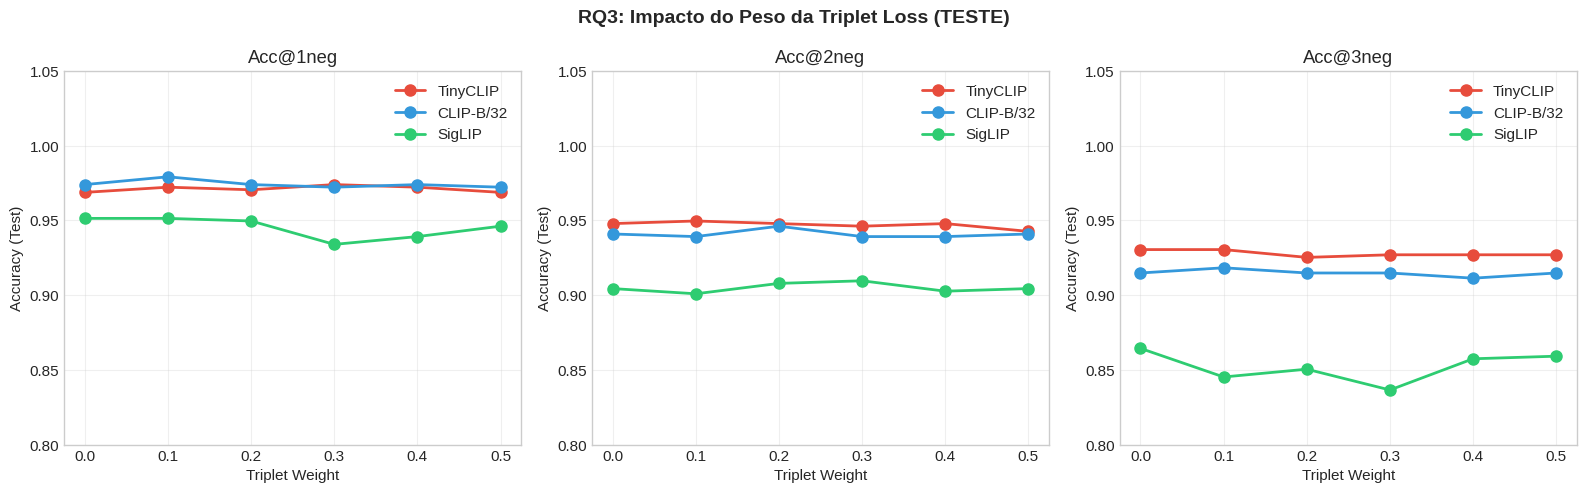


🏆 Melhor configuração por arquitetura (Acc@3neg no TESTE):
   TinyCLIP: TW=0.0 → Acc@3neg=0.9304
   CLIP-B/32: TW=0.1 → Acc@3neg=0.9183
   SigLIP: TW=0.0 → Acc@3neg=0.8643


In [9]:
# RQ3: Influência da Triplet Loss (MÉTRICAS DE TESTE)
def analyze_triplet_loss_impact():
    """Analisa o impacto do peso da triplet loss usando MÉTRICAS DE TESTE."""
    
    finetuned = df_experiments[
        (df_experiments["finetuned"]) & 
        (~df_experiments["has_augmentation"])
    ].copy()
    
    print("=" * 80)
    print("📊 RQ3: IMPACTO DA TRIPLET LOSS (MÉTRICAS DE TESTE)")
    print("=" * 80)
    
    results = []
    gap_cols = ["test_similarity_gap_1_neg", "test_similarity_gap_2_neg", "test_similarity_gap_3_neg"]

    for arch in ["TinyCLIP", "CLIP-B/32", "SigLIP"]:
        arch_data = finetuned[finetuned["architecture"] == arch]
        
        # Baseline (sem triplet)
        baseline = arch_data[~arch_data["has_triplet"]]
        if len(baseline) > 0:
            row = {
                "Arquitetura": arch,
                "Triplet Weight": 0.0,
                "Config": "Baseline",
                "Acc@1neg": baseline["test_accuracy_1_neg"].values[0] if "test_accuracy_1_neg" in baseline.columns else None,
                "Acc@2neg": baseline["test_accuracy_2_neg"].values[0] if "test_accuracy_2_neg" in baseline.columns else None,
                "Acc@3neg": baseline["test_accuracy_3_neg"].values[0] if "test_accuracy_3_neg" in baseline.columns else None,
                "Similarity Gap": baseline[gap_cols].iloc[0].mean() if all(c in baseline.columns for c in gap_cols) else None,
            }
            results.append(row)
        
        # Com triplet (diferentes pesos)
        triplet_data = arch_data[arch_data["has_triplet"]]
        for _, exp in triplet_data.iterrows():
            tw = exp.get("triplet_weight", 0)
            row = {
                "Arquitetura": arch,
                "Triplet Weight": tw,
                "Config": f"TW={tw}",
                "Acc@1neg": exp.get("test_accuracy_1_neg"),
                "Acc@2neg": exp.get("test_accuracy_2_neg"),
                "Acc@3neg": exp.get("test_accuracy_3_neg"),
                "Similarity Gap": np.mean(
                    [exp.get(gap) for gap in gap_cols]
                )
            }
            results.append(row)
    
    df_results = pd.DataFrame(results)
    df_results = df_results.sort_values(["Arquitetura", "Triplet Weight"])
    
    print("\n📈 Resultados por Peso de Triplet Loss (TESTE):")
    display(df_results)
    
    # Visualização
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    metrics_plot = ["Acc@1neg", "Acc@2neg", "Acc@3neg"]
    colors = {"TinyCLIP": "#e74c3c", "CLIP-B/32": "#3498db", "SigLIP": "#2ecc71"}
    
    for idx, metric in enumerate(metrics_plot):
        ax = axes[idx]
        
        for arch in ["TinyCLIP", "CLIP-B/32", "SigLIP"]:
            arch_data = df_results[df_results["Arquitetura"] == arch].sort_values("Triplet Weight")
            if len(arch_data) > 0:
                ax.plot(arch_data["Triplet Weight"], arch_data[metric], 
                       'o-', label=arch, color=colors[arch], linewidth=2, markersize=8)
        
        ax.set_xlabel('Triplet Weight')
        ax.set_ylabel('Accuracy (Test)')
        ax.set_title(f'{metric}')
        ax.legend()
        ax.grid(alpha=0.3)
        ax.set_ylim(0.8, 1.05)
    
    plt.suptitle('RQ3: Impacto do Peso da Triplet Loss (TESTE)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('article_outputs/img_metrics/rq3_triplet_loss_impact_test.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n🏆 Melhor configuração por arquitetura (Acc@3neg no TESTE):")
    for arch in ["TinyCLIP", "CLIP-B/32", "SigLIP"]:
        arch_data = df_results[df_results["Arquitetura"] == arch]
        if len(arch_data) > 0 and "Acc@3neg" in arch_data.columns:
            arch_data_valid = arch_data.dropna(subset=["Acc@3neg"])
            if len(arch_data_valid) > 0:
                best_idx = arch_data_valid["Acc@3neg"].idxmax()
                best = arch_data_valid.loc[best_idx]
                print(f"   {arch}: TW={best['Triplet Weight']:.1f} → Acc@3neg={best['Acc@3neg']:.4f}")
    
    return df_results

rq3_results = analyze_triplet_loss_impact()


📊 RQ5: IMPACTO DA AUGMENTAÇÃO (ISOLADO) - TESTE

📈 Comparação (Com vs Sem Augmentação):


,Arquitetura,Acc@1neg (Aug),Acc@1neg (NoAug),Δ Acc@1neg,Acc@2neg (Aug),Acc@2neg (NoAug),Δ Acc@2neg,Acc@3neg (Aug),Acc@3neg (NoAug),Δ Acc@3neg
0,TinyCLIP,0.9791,0.9687,0.0104,0.9530,0.9478,0.0052,0.9461,0.9304,0.0157
1,CLIP-B/32,0.9791,0.9739,0.0052,0.9583,0.9409,0.0174,0.9409,0.9148,0.0261
2,SigLIP,0.9513,0.9513,0.0000,0.9061,0.9043,0.0017,0.8800,0.8643,0.0157



📊 Análise geral:
   Δ médio global: +0.0108


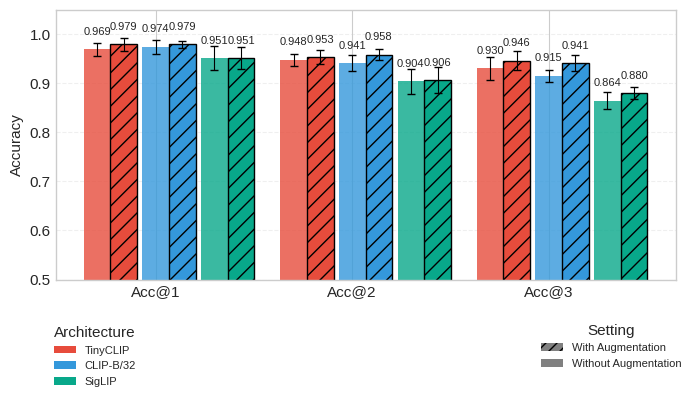

In [59]:
# RQ5: Influência da Augmentação de Dados (MÉTRICAS DE TESTE)
def analyze_augmentation_impact():
    """Analisa o impacto da augmentação isolando outras variáveis."""
    
    # 🔒 FIXAMOS: finetuned + sem triplet (baseline)
    baseline = df_experiments[
        (df_experiments["finetuned"]) &
        (~df_experiments["use_triplet"])
    ].copy()
    
    print("=" * 80)
    print("📊 RQ5: IMPACTO DA AUGMENTAÇÃO (ISOLADO) - TESTE")
    print("=" * 80)
    
    results = []
    
    for arch in ["TinyCLIP", "CLIP-B/32", "SigLIP"]:
        arch_data = baseline[baseline["architecture"] == arch]
        
        with_aug = arch_data[arch_data["has_augmentation"]]
        without_aug = arch_data[~arch_data["has_augmentation"]]
        
        if len(with_aug) > 0 and len(without_aug) > 0:
            
            row = {
                "Arquitetura": arch,
                "Acc@1neg (Aug)": with_aug["test_accuracy_1_neg"].values[0],
                "Acc@1neg (NoAug)": without_aug["test_accuracy_1_neg"].values[0],
                "Δ Acc@1neg": with_aug["test_accuracy_1_neg"].values[0] - without_aug["test_accuracy_1_neg"].values[0],

                "Acc@2neg (Aug)": with_aug["test_accuracy_2_neg"].values[0],
                "Acc@2neg (NoAug)": without_aug["test_accuracy_2_neg"].values[0],
                "Δ Acc@2neg": with_aug["test_accuracy_2_neg"].values[0] - without_aug["test_accuracy_2_neg"].values[0],

                "Acc@3neg (Aug)": with_aug["test_accuracy_3_neg"].values[0],
                "Acc@3neg (NoAug)": without_aug["test_accuracy_3_neg"].values[0],
                "Δ Acc@3neg": with_aug["test_accuracy_3_neg"].values[0] - without_aug["test_accuracy_3_neg"].values[0],
            }
            
            # desvio entre seeds (para barras de erro)
            for k in [1, 2, 3]:
                _, s_aug = ms(with_aug, f"test_accuracy_{k}_neg")
                _, s_noaug = ms(without_aug, f"test_accuracy_{k}_neg")
                row[f"Acc@{k}neg (Aug)_std"] = s_aug
                row[f"Acc@{k}neg (NoAug)_std"] = s_noaug
            
            results.append(row)
    
    df_results = pd.DataFrame(results)
    
    print("\n📈 Comparação (Com vs Sem Augmentação):")
    _show = [c for c in df_results.columns if not c.endswith("_std")]
    display(df_results[_show].round(4))
    
    # 📊 resumo
    print("\n📊 Análise geral:")
    deltas = df_results[[col for col in df_results.columns if "Δ" in col]]
    mean_delta = deltas.mean().mean()
    print(f"   Δ médio global: {mean_delta:+.4f}")
    
    return df_results

def plot_augmentation_clean_v3(df_results):
    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.patches import Patch
    
    colors = {
        "TinyCLIP": "#e74c3c",
        "CLIP-B/32": "#3498db",
        "SigLIP": "#08A88A"
    }
    
    ks = [1, 2, 3]
    group_gap = 1.4  # 🔥 aumenta espaço entre Acc@k
    x = np.arange(len(ks)) * group_gap
    
    width = 0.19  # 🔥 mais largas
    
    fig, ax = plt.subplots(figsize=(8, 4.5))
    
    architectures = df_results["Arquitetura"].tolist()
    
    for i, arch in enumerate(architectures):
        row = df_results.iloc[i]
        
        # 🔥 espaçamento mais equilibrado
        offset = (i - 1) * 2.2 * width
        
        noaug_vals = [row[f"Acc@{k}neg (NoAug)"] for k in ks]
        aug_vals   = [row[f"Acc@{k}neg (Aug)"] for k in ks]
        noaug_errs = [float(row.get(f"Acc@{k}neg (NoAug)_std", 0) or 0) for k in ks]
        aug_errs   = [float(row.get(f"Acc@{k}neg (Aug)_std", 0) or 0) for k in ks]
        
        # NoAug (primeiro - base)
        bars_noaug = ax.bar(
            x + offset,
            noaug_vals,
            width,
            yerr=noaug_errs,
            capsize=3,
            error_kw={"elinewidth": 0.8},
            color=colors[arch],
            alpha=0.8,
            label=f"{arch} (NoAug)" if i == 0 else None
        )

        # Aug (depois - destaque)
        bars_aug = ax.bar(
            x + offset + width,
            aug_vals,
            width,
            yerr=aug_errs,
            capsize=3,
            error_kw={"elinewidth": 0.8},
            color=colors[arch],
            hatch='//',   # 👈 destaque
            edgecolor='black',
            label=f"{arch} (Aug)" if i == 0 else None
        )
        
        # 📊 labels (sem sobreposição)
        for bars in [bars_noaug, bars_aug]:
            for bar in bars:
                height = bar.get_height()
                ax.annotate(
                    f"{height:.3f}",
                    xy=(bar.get_x() + bar.get_width()/2, height + 0.015),
                    xytext=(0, 4),
                    textcoords="offset points",
                    ha='center',
                    va='bottom',
                    fontsize=8
                )
    
    # eixo X
    ax.set_xticks(x)
    ax.set_xticklabels([f"Acc@{k}" for k in ks])
    
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0.50, 1.05)
    
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    # espaço inferior p/ legendas
    plt.subplots_adjust(bottom=0.28)
    
    # =========================
    # 🔵 ARQUITETURAS (ESQUERDA)
    # =========================
    arch_legend = [
        Patch(facecolor=colors["TinyCLIP"], label="TinyCLIP"),
        Patch(facecolor=colors["CLIP-B/32"], label="CLIP-B/32"),
        Patch(facecolor=colors["SigLIP"], label="SigLIP")
    ]
    
    fig.legend(
        handles=arch_legend,
        loc='lower left',
        bbox_to_anchor=(0.11, 0.02),
        fontsize=8,
        title="Architecture"
    )
    
    # =========================
    # 🔳 AUGMENTATION (DIREITA)
    # =========================
    aug_legend = [
        Patch(facecolor='gray', hatch='///', label="With Augmentation"),
        Patch(facecolor='gray', label="Without Augmentation")
    ]
    
    fig.legend(
        handles=aug_legend,
        loc='lower right',
        bbox_to_anchor=(0.92, 0.06),
        fontsize=8,
        title="Setting"
    )
    
    #plt.title("Effect of Data Augmentation on Retrieval Accuracy", fontsize=12)

    plt.savefig(
        "article_outputs/img_metrics/rq5_augmentation_final.pdf",
        format="pdf",
        bbox_inches='tight'
    )
    
    plt.show()

rq5_results = analyze_augmentation_impact()
plot_augmentation_clean_v3(rq5_results)

📊 RQ6: RANKING FINAL DOS MODELOS (MÉTRICAS DE TESTE)

🏆 TOP 10 Modelos (por Acc@3neg no TESTE):


,Rank,Experimento,Configuração,Acc@1neg,Acc@2neg,Acc@3neg,Similarity Gap,Acc@3neg (±σ)
0,1,tinyclip_combined_tw03,TinyCLIP | infonce+TW0.3,0.977391,0.953043,0.949565,0.437995,0.9496 ± 0.0095
1,2,tinyclip_combined_tw02,TinyCLIP | infonce+TW0.2,0.977391,0.953043,0.949565,0.437690,0.9496 ± 0.0225
2,3,clip_vit_b32_combined_tw04,CLIP-B/32 | infonce+TW0.4,0.972174,0.958261,0.946087,0.415644,0.9461 ± 0.0073
3,4,clip_vit_b32_combined_tw05,CLIP-B/32 | infonce+TW0.5,0.975652,0.953043,0.946087,0.419826,0.9461 ± 0.0095
4,5,tinyclip_combined_tw01,TinyCLIP | infonce+TW0.1,0.975652,0.956522,0.946087,0.437300,0.9461 ± 0.0189
5,6,tinyclip_combined_tw05,TinyCLIP | infonce+TW0.5,0.973913,0.956522,0.946087,0.442346,0.9461 ± 0.0217
6,7,tinyclip_infonce,TinyCLIP | infonce,0.979130,0.953043,0.946087,0.439815,0.9461 ± 0.0189
7,8,clip_vit_b32_combined_tw01,CLIP-B/32 | infonce+TW0.1,0.975652,0.961739,0.942609,0.417327,0.9426 ± 0.0180
8,9,clip_vit_b32_combined_tw02,CLIP-B/32 | infonce+TW0.2,0.979130,0.961739,0.942609,0.421040,0.9426 ± 0.0146
9,10,tinyclip_combined_tw04,TinyCLIP | infonce+TW0.4,0.975652,0.954783,0.940870,0.434984,0.9409 ± 0.0198


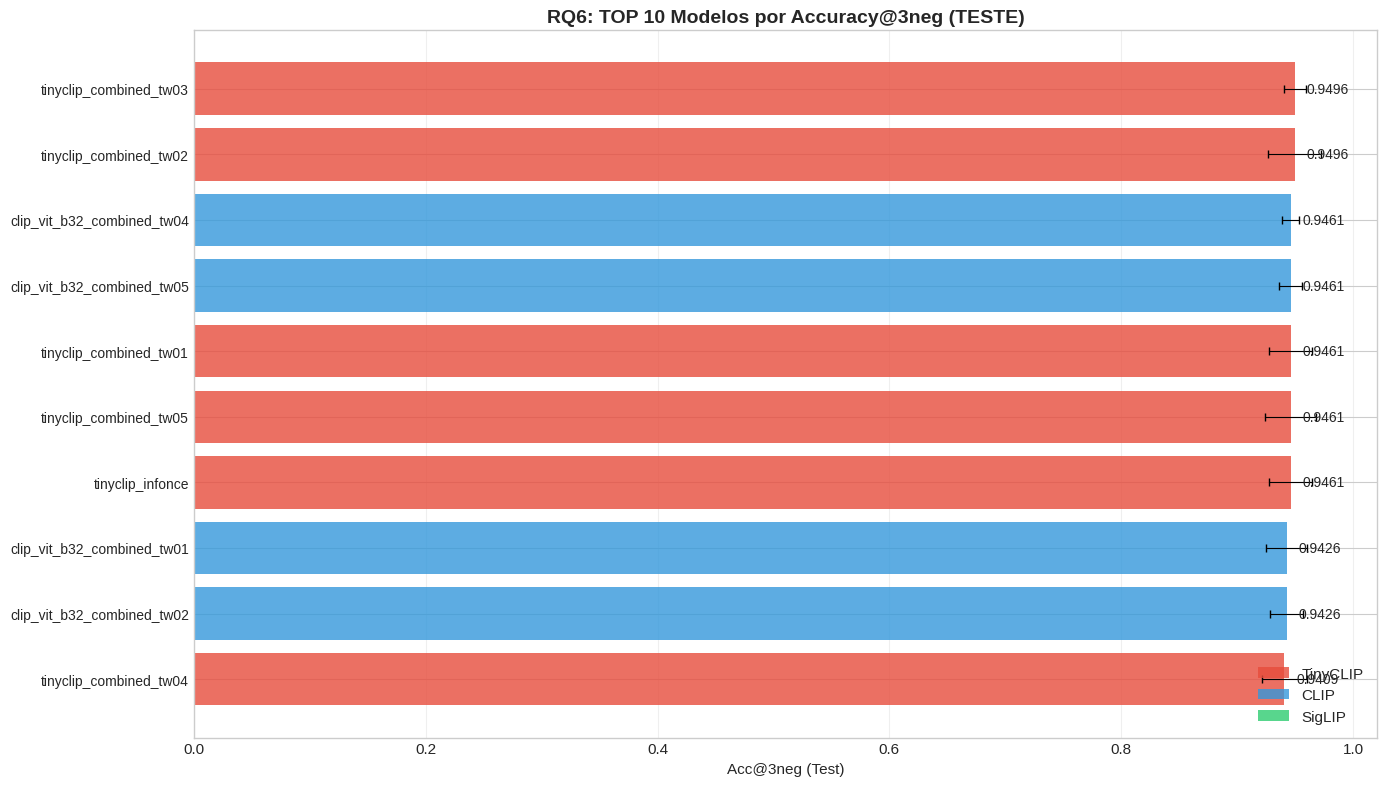


🥇 MELHOR MODELO GERAL (TESTE):
   Experimento: tinyclip_combined_tw03
   Configuração: TinyCLIP | infonce+TW0.3
   Acc@1neg: 0.9774
   Acc@2neg: 0.9530
   Acc@3neg: 0.9496

📊 Resumo por Arquitetura (TESTE):
   TinyCLIP: Best Acc@3neg=0.9496, Mean=0.9288, Best Rank=1
   CLIP-B/32: Best Acc@3neg=0.9461, Mean=0.9168, Best Rank=3
   SigLIP: Best Acc@3neg=0.8870, Mean=0.8242, Best Rank=26


In [11]:
# RQ6: Ranking Final (MÉTRICAS DE TESTE)
def create_final_ranking():
    """Cria ranking final usando MÉTRICAS DE TESTE."""
    
    print("=" * 80)
    print("📊 RQ6: RANKING FINAL DOS MODELOS (MÉTRICAS DE TESTE)")
    print("=" * 80)
    
    df_ranking = df_experiments.copy()
    
    def get_config_name(row):
        parts = []
        parts.append(row["architecture"])
        if not row["finetuned"]:
            parts.append("Frozen")
        else:
            loss = row.get("loss_type", "unknown")
            if row.get("has_triplet", False):
                tw = row.get("triplet_weight", 0)
                parts.append(f"{loss}+TW{tw}")
            else:
                parts.append(loss)
            if not row.get("has_augmentation", True):
                parts.append("NoAug")
        return " | ".join(parts)
    
    df_ranking["Config"] = df_ranking.apply(get_config_name, axis=1)
    
    df_ranking = df_ranking.sort_values("test_accuracy_3_neg", ascending=False).reset_index(drop=True)
    df_ranking["Rank"] = df_ranking.index + 1
    
    display_cols = ["Rank", "name", "Config", "test_accuracy_1_neg", "test_accuracy_2_neg", 
                   "test_accuracy_3_neg", "test_similarity_gap_3_neg"]
    available_cols = [c for c in display_cols if c in df_ranking.columns]
    
    df_display = df_ranking[available_cols].copy()
    df_display.columns = ["Rank", "Experimento", "Configuração", "Acc@1neg", "Acc@2neg", 
                         "Acc@3neg", "Similarity Gap"][:len(available_cols)]
    # coluna média ± desvio entre seeds para Acc@3neg
    df_display["Acc@3neg (±σ)"] = [
        fmt_pm(m, s) for m, s in zip(
            df_ranking["test_accuracy_3_neg"].values,
            df_ranking.get("test_accuracy_3_neg_std", pd.Series([0] * len(df_ranking))).values,
        )
    ]
    
    print("\n🏆 TOP 10 Modelos (por Acc@3neg no TESTE):")
    display(df_display.head(10).style.background_gradient(subset=["Acc@3neg"], cmap='Greens'))
    
    # Visualização: Top 10
    fig, ax = plt.subplots(figsize=(14, 8))
    
    top10 = df_display.head(10)
    y_pos = np.arange(len(top10))
    
    def get_color(config):
        if "TinyCLIP" in config:
            return "#e74c3c"
        elif "CLIP" in config:
            return "#3498db"
        elif "SigLIP" in config:
            return "#2ecc71"
        return "#95a5a6"
    
    colors = [get_color(c) for c in top10["Configuração"]]
    
    top10_errs = df_ranking.get(
        "test_accuracy_3_neg_std", pd.Series([0] * len(df_ranking))
    ).head(10).values
    bars = ax.barh(y_pos, top10["Acc@3neg"], xerr=top10_errs, capsize=3,
                   error_kw={"elinewidth": 0.8}, color=colors, alpha=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top10["Experimento"], fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel('Acc@3neg (Test)')
    ax.set_title('RQ6: TOP 10 Modelos por Accuracy@3neg (TESTE)', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    for bar, val in zip(bars, top10["Acc@3neg"]):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
               f'{val:.4f}', va='center', fontsize=10)
    
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#e74c3c', alpha=0.8, label='TinyCLIP'),
        Patch(facecolor='#3498db', alpha=0.8, label='CLIP'),
        Patch(facecolor='#2ecc71', alpha=0.8, label='SigLIP'),
    ]
    ax.legend(handles=legend_elements, loc='lower right')
    
    plt.tight_layout()
    plt.savefig('article_outputs/img_metrics/rq6_final_ranking_test.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    best = df_display.iloc[0]
    print(f"\n🥇 MELHOR MODELO GERAL (TESTE):")
    print(f"   Experimento: {best['Experimento']}")
    print(f"   Configuração: {best['Configuração']}")
    print(f"   Acc@1neg: {best['Acc@1neg']:.4f}")
    print(f"   Acc@2neg: {best['Acc@2neg']:.4f}")
    print(f"   Acc@3neg: {best['Acc@3neg']:.4f}")
    
    print("\n📊 Resumo por Arquitetura (TESTE):")
    for arch in ["TinyCLIP", "CLIP-B/32", "SigLIP"]:
        arch_data = df_ranking[df_ranking["architecture"] == arch]
        if len(arch_data) > 0 and "test_accuracy_3_neg" in arch_data.columns:
            best_acc = arch_data["test_accuracy_3_neg"].max()
            mean_acc = arch_data["test_accuracy_3_neg"].mean()
            best_rank = arch_data["Rank"].min()
            print(f"   {arch}: Best Acc@3neg={best_acc:.4f}, Mean={mean_acc:.4f}, Best Rank={best_rank}")
    
    return df_display

rq6_ranking = create_final_ranking()


### Ablation Study

1 - Finetunning

2 - Augumentation

3 - Combined loss

In [13]:
print("Baseline")
display(rq6_ranking[rq6_ranking["Experimento"] == "tinyclip_frozen_eval"])
print("Impact of finetunnig")
display(rq6_ranking[rq6_ranking["Experimento"] == "tinyclip_infonce_noaug"])
print("Impact of augumentation")
display(rq6_ranking[rq6_ranking["Experimento"] == "tinyclip_infonce"])
print("Impact of combined loss")
display(rq6_ranking[rq6_ranking["Experimento"] == "tinyclip_combined_tw03"])

Baseline


,Rank,Experimento,Configuração,Acc@1neg,Acc@2neg,Acc@3neg,Similarity Gap,Acc@3neg (±σ)
37,38,tinyclip_frozen_eval,TinyCLIP | Frozen,0.916522,0.864348,0.829565,0.088406,0.8296 ± 0.0401


Impact of finetunnig


,Rank,Experimento,Configuração,Acc@1neg,Acc@2neg,Acc@3neg,Similarity Gap,Acc@3neg (±σ)
13,14,tinyclip_infonce_noaug,TinyCLIP | infonce | NoAug,0.968696,0.947826,0.930435,0.422504,0.9304 ± 0.0238


Impact of augumentation


,Rank,Experimento,Configuração,Acc@1neg,Acc@2neg,Acc@3neg,Similarity Gap,Acc@3neg (±σ)
6,7,tinyclip_infonce,TinyCLIP | infonce,0.97913,0.953043,0.946087,0.439815,0.9461 ± 0.0189


Impact of combined loss


,Rank,Experimento,Configuração,Acc@1neg,Acc@2neg,Acc@3neg,Similarity Gap,Acc@3neg (±σ)
0,1,tinyclip_combined_tw03,TinyCLIP | infonce+TW0.3,0.977391,0.953043,0.949565,0.437995,0.9496 ± 0.0095


## 📝 Resumo Final para o Artigo


In [14]:
# Resumo Final para o Artigo (MÉTRICAS DE TESTE)
def generate_article_summary():
    """Gera tabelas e resumos formatados para o artigo usando MÉTRICAS DE TESTE."""
    
    print("=" * 80)
    print("📄 RESUMO PARA O ARTIGO (MÉTRICAS DE TESTE)")
    print("=" * 80)
    
    # 1. Tabela: Dataset Statistics
    print("\n📊 TABELA 1: Estatísticas do Dataset")
    dataset_stats = {
        "Métrica": ["Total de Assinaturas", "Assinaturas Identificadas", "Assinaturas UNKNOWN", 
                    "Signatários Únicos", "Documentos", "Split Treino (%)", "Split Validação (%)", "Split Teste (%)"],
        "Valor": [4542, 3647, 895, 753, 2241, 75, 10, 15]
    }
    df_dataset_stats = pd.DataFrame(dataset_stats)
    display(df_dataset_stats)
    
    # 2. Tabela: Main Results - TESTE
    print("\n📊 TABELA 3: Melhores Resultados por Arquitetura (TESTE)")
    
    main_results = []
    for arch in ["TinyCLIP", "CLIP-B/32", "SigLIP"]:
        # Frozen baseline
        frozen = df_experiments[(~df_experiments["finetuned"]) & (df_experiments["architecture"] == arch)]
        if len(frozen) > 0 and "test_accuracy_1_neg" in frozen.columns:
            main_results.append({
                "Arquitetura": arch,
                "Configuração": "Frozen (Pre-trained)",
                "Acc@1neg": frozen["test_accuracy_1_neg"].values[0],
                "Acc@2neg": frozen["test_accuracy_2_neg"].values[0],
                "Acc@3neg": frozen["test_accuracy_3_neg"].values[0],
            })
        
        # Best finetuned
        finetuned = df_experiments[(df_experiments["finetuned"]) & (df_experiments["architecture"] == arch)]
        if len(finetuned) > 0 and "test_accuracy_3_neg" in finetuned.columns:
            best_idx = finetuned["test_accuracy_3_neg"].idxmax()
            best = finetuned.loc[best_idx]
            config = f"Finetuned"
            if best.get("has_triplet", False):
                config += f" + Triplet (w={best['triplet_weight']})"
            if not best.get("has_augmentation", True):
                config += " [NoAug]"
            
            main_results.append({
                "Arquitetura": arch,
                "Configuração": config,
                "Acc@1neg": best["test_accuracy_1_neg"],
                "Acc@2neg": best["test_accuracy_2_neg"],
                "Acc@3neg": best["test_accuracy_3_neg"],
            })
    
    df_main = pd.DataFrame(main_results)
    display(df_main.round(4).style.highlight_max(subset=["Acc@3neg"], color='lightgreen'))
    
    # 3. Conclusões automáticas
    print("\n" + "=" * 80)
    print("📌 CONCLUSÕES PRINCIPAIS (MÉTRICAS DE TESTE)")
    print("=" * 80)
    
    if "test_accuracy_3_neg" in df_experiments.columns:
        frozen_data = df_experiments[~df_experiments["finetuned"]]["test_accuracy_3_neg"].dropna()
        finetuned_data = df_experiments[df_experiments["finetuned"]]["test_accuracy_3_neg"].dropna()
        
        if len(frozen_data) > 0 and len(finetuned_data) > 0:
            frozen_avg = frozen_data.mean()
            finetuned_avg = finetuned_data.mean()
            print(f"\n1. Fine-tuning:")
            print(f"   - Média Acc@3neg Frozen: {frozen_avg:.4f}")
            print(f"   - Média Acc@3neg Finetuned: {finetuned_avg:.4f}")
            print(f"   - Melhoria: {((finetuned_avg - frozen_avg) / frozen_avg * 100):+.1f}%")
    
        best_overall = df_experiments.loc[df_experiments["test_accuracy_3_neg"].idxmax()]
        print(f"\n2. Melhor Arquitetura: {best_overall['architecture']}")
        print(f"   - Experimento: {best_overall['name']}")
        print(f"   - Acc@3neg: {best_overall['test_accuracy_3_neg']:.4f}")
    
    # LaTeX export
    print("\n" + "=" * 80)
    print("📄 EXPORTAÇÃO LATEX")
    print("=" * 80)
    print("\n% Tabela - Main Results (LaTeX)")
    print(df_main.round(4).to_latex(index=False, caption="Melhores resultados por arquitetura (Teste)", label="tab:results_test"))
    
    return df_main

article_summary = generate_article_summary()


📄 RESUMO PARA O ARTIGO (MÉTRICAS DE TESTE)

📊 TABELA 1: Estatísticas do Dataset


,Métrica,Valor
0,Total de Assinaturas,4542
1,Assinaturas Identificadas,3647
2,Assinaturas UNKNOWN,895
3,Signatários Únicos,753
4,Documentos,2241
5,Split Treino (%),75
6,Split Validação (%),10
7,Split Teste (%),15



📊 TABELA 3: Melhores Resultados por Arquitetura (TESTE)


,Arquitetura,Configuração,Acc@1neg,Acc@2neg,Acc@3neg
0,TinyCLIP,Frozen (Pre-trained),0.916500,0.864300,0.829600
1,TinyCLIP,Finetuned + Triplet (w=0.2),0.977400,0.953000,0.949600
2,CLIP-B/32,Frozen (Pre-trained),0.885200,0.805200,0.772200
3,CLIP-B/32,Finetuned + Triplet (w=0.4),0.972200,0.958300,0.946100
4,SigLIP,Frozen (Pre-trained),0.579100,0.393000,0.320000
5,SigLIP,Finetuned + Triplet (w=0.3),0.953000,0.906100,0.887000



📌 CONCLUSÕES PRINCIPAIS (MÉTRICAS DE TESTE)

1. Fine-tuning:
   - Média Acc@3neg Frozen: 0.7130
   - Média Acc@3neg Finetuned: 0.9107
   - Melhoria: +27.7%

2. Melhor Arquitetura: TinyCLIP
   - Experimento: tinyclip_combined_tw02
   - Acc@3neg: 0.9496

📄 EXPORTAÇÃO LATEX

% Tabela - Main Results (LaTeX)
\begin{table}
\caption{Melhores resultados por arquitetura (Teste)}
\label{tab:results_test}
\begin{tabular}{llrrr}
\toprule
Arquitetura & Configuração & Acc@1neg & Acc@2neg & Acc@3neg \\
\midrule
TinyCLIP & Frozen (Pre-trained) & 0.916500 & 0.864300 & 0.829600 \\
TinyCLIP & Finetuned + Triplet (w=0.2) & 0.977400 & 0.953000 & 0.949600 \\
CLIP-B/32 & Frozen (Pre-trained) & 0.885200 & 0.805200 & 0.772200 \\
CLIP-B/32 & Finetuned + Triplet (w=0.4) & 0.972200 & 0.958300 & 0.946100 \\
SigLIP & Frozen (Pre-trained) & 0.579100 & 0.393000 & 0.320000 \\
SigLIP & Finetuned + Triplet (w=0.3) & 0.953000 & 0.906100 & 0.887000 \\
\bottomrule
\end{tabular}
\end{table}



## 📐 Significância Estatística (grid multi-seed)

Análise sobre `experiments/significance/seed_*` (5 seeds por configuração), usando as funções de `scripts/analyze_significance.py`:

1. **Agregação** por configuração: média ± desvio e IC 95% (t-Student) da métrica principal `accuracy_3_neg`.
2. **Testes pareados por seed** (Wilcoxon signed-rank + t pareado, com Cohen's d):
   - efeito da **augmentação** (config vs `*_noaug`);
   - efeito da **loss combinada** (`combined_twXX` vs finetuning simples).
3. **Comparação entre modelos**: Friedman + post-hoc de Nemenyi (requer `scikit-posthocs`).

In [15]:
# Significância: agregação por configuração (média ± desvio, IC 95%)
import sys, importlib
sys.path.insert(0, str(Path("../scripts").resolve()))
import analyze_significance as sig
importlib.reload(sig)

SIG_BASE = Path("../experiments/significance")
df_sig = sig.load_results(SIG_BASE)
print(f"📥 {len(df_sig)} execuções: {df_sig['config'].nunique()} configs × {df_sig['seed'].nunique()} seeds")
print(f"   backends -> scipy: {sig.HAS_SCIPY} | scikit_posthocs: {sig.HAS_POSTHOCS}")

PRIMARY = "accuracy_3_neg"
summary = sig.aggregate(df_sig, sig.FOCUS_METRICS)

tbl = summary.copy()
tbl["Acc@3neg (média ± σ)"] = [fmt_pm(a, b) for a, b in
                               zip(tbl[f"{PRIMARY}_mean"], tbl[f"{PRIMARY}_std"])]
tbl["IC95 (±)"] = tbl[f"{PRIMARY}_ci95"].round(4)
print("\n🏆 Top 10 configurações por Acc@3neg (média entre seeds):")
display(tbl[["config", "model", "n_seeds", "Acc@3neg (média ± σ)", "IC95 (±)"]].head(10))

📥 200 execuções: 40 configs × 5 seeds
   backends -> scipy: True | scikit_posthocs: True

🏆 Top 10 configurações por Acc@3neg (média entre seeds):


,config,model,n_seeds,Acc@3neg (média ± σ),IC95 (±)
0,tinyclip_combined_tw03,tinyclip,5,0.9496 ± 0.0095,0.0118
1,tinyclip_combined_tw02,tinyclip,5,0.9496 ± 0.0225,0.0279
2,clip_vit_b32_combined_tw04,clip_vit_b32,5,0.9461 ± 0.0073,0.0090
3,clip_vit_b32_combined_tw05,clip_vit_b32,5,0.9461 ± 0.0095,0.0118
4,tinyclip_combined_tw01,tinyclip,5,0.9461 ± 0.0189,0.0234
5,tinyclip_combined_tw05,tinyclip,5,0.9461 ± 0.0217,0.0269
6,tinyclip_infonce,tinyclip,5,0.9461 ± 0.0189,0.0234
7,clip_vit_b32_combined_tw01,clip_vit_b32,5,0.9426 ± 0.0180,0.0224
8,clip_vit_b32_combined_tw02,clip_vit_b32,5,0.9426 ± 0.0146,0.0181
9,tinyclip_combined_tw04,tinyclip,5,0.9409 ± 0.0198,0.0246


In [16]:
# Significância: testes pareados por seed (augmentação e loss combinada)
def effects_table(effects):
    rows = []
    for e in effects:
        rows.append({
            "config (A)": e["config_a"],
            "baseline (B)": e["config_b"],
            "média A": round(e["mean_a"], 4),
            "média B": round(e["mean_b"], 4),
            "Δ (A−B)": round(e["mean_diff"], 4),
            "n": e["n_pairs"],
            "p (Wilcoxon)": round(e.get("wilcoxon_p", float("nan")), 4),
            "p (t pareado)": round(e.get("ttest_p", float("nan")), 4),
            "Cohen d": round(e.get("cohens_d", float("nan")), 3),
            "signif. (p<0.05)": e.get("significant_0.05", False),
        })
    return pd.DataFrame(rows)

aug = sig.augmentation_effects(df_sig, PRIMARY)
comb = sig.combined_loss_effects(df_sig, PRIMARY)

print("=" * 80)
print(f"📊 Efeito da AUGMENTAÇÃO (config vs *_noaug) — métrica {PRIMARY}")
print("=" * 80)
df_aug = effects_table(aug)
display(df_aug)
if len(df_aug):
    print(f"Significativos (p<0.05): {int(df_aug['signif. (p<0.05)'].sum())}/{len(df_aug)}")

print("\n" + "=" * 80)
print(f"📊 Efeito da LOSS COMBINADA (combined_twXX vs finetuning simples) — {PRIMARY}")
print("=" * 80)
df_comb = effects_table(comb)
display(df_comb)
if len(df_comb):
    print(f"Significativos (p<0.05): {int(df_comb['signif. (p<0.05)'].sum())}/{len(df_comb)}")

📊 Efeito da AUGMENTAÇÃO (config vs *_noaug) — métrica accuracy_3_neg


,config (A),baseline (B),média A,média B,Δ (A−B),n,p (Wilcoxon),p (t pareado),Cohen d,signif. (p<0.05)
0,clip_vit_b32_combined_tw01,clip_vit_b32_combined_tw01_noaug,0.9426,0.9183,0.0243,5,0.1250,0.0729,1.082,False
1,clip_vit_b32_combined_tw02,clip_vit_b32_combined_tw02_noaug,0.9426,0.9148,0.0278,5,0.1250,0.0453,1.285,False
2,clip_vit_b32_combined_tw03,clip_vit_b32_combined_tw03_noaug,0.9391,0.9148,0.0243,5,0.1250,0.0586,1.173,False
3,clip_vit_b32_combined_tw04,clip_vit_b32_combined_tw04_noaug,0.9461,0.9113,0.0348,5,0.0625,0.0032,2.828,False
4,clip_vit_b32_combined_tw05,clip_vit_b32_combined_tw05_noaug,0.9461,0.9148,0.0313,5,0.0625,0.0039,2.683,False
5,clip_vit_b32_infonce,clip_vit_b32_infonce_noaug,0.9409,0.9148,0.0261,5,0.1250,0.0581,1.177,False
6,siglip_combined_tw01,siglip_combined_tw01_noaug,0.8713,0.8452,0.0261,5,0.1875,0.1740,0.739,False
7,siglip_combined_tw02,siglip_combined_tw02_noaug,0.8765,0.8504,0.0261,5,0.0625,0.0090,2.121,False
8,siglip_combined_tw03,siglip_combined_tw03_noaug,0.8870,0.8365,0.0504,5,0.0625,0.0117,1.966,False
9,siglip_combined_tw04,siglip_combined_tw04_noaug,0.8817,0.8574,0.0243,5,0.0625,0.0086,2.148,False


Significativos (p<0.05): 0/18

📊 Efeito da LOSS COMBINADA (combined_twXX vs finetuning simples) — accuracy_3_neg


,config (A),baseline (B),média A,média B,Δ (A−B),n,p (Wilcoxon),p (t pareado),Cohen d,signif. (p<0.05)
0,clip_vit_b32_combined_tw01,clip_vit_b32_infonce,0.9426,0.9409,0.0017,5,1.0000,0.3739,0.447,False
1,clip_vit_b32_combined_tw02,clip_vit_b32_infonce,0.9426,0.9409,0.0017,5,1.0000,0.7780,0.135,False
2,clip_vit_b32_combined_tw03,clip_vit_b32_infonce,0.9391,0.9409,-0.0017,5,0.7500,0.6213,-0.239,False
3,clip_vit_b32_combined_tw04,clip_vit_b32_infonce,0.9461,0.9409,0.0052,5,0.8750,0.5913,0.261,False
4,clip_vit_b32_combined_tw05,clip_vit_b32_infonce,0.9461,0.9409,0.0052,5,0.8125,0.5913,0.261,False
5,siglip_combined_tw01,siglip_sigmoid,0.8713,0.8800,-0.0087,5,0.2500,0.2980,-0.535,False
6,siglip_combined_tw02,siglip_sigmoid,0.8765,0.8800,-0.0035,5,0.7500,0.4766,-0.351,False
7,siglip_combined_tw03,siglip_sigmoid,0.8870,0.8800,0.0070,5,0.7500,0.5543,0.288,False
8,siglip_combined_tw04,siglip_sigmoid,0.8817,0.8800,0.0017,5,1.0000,0.7040,0.183,False
9,siglip_combined_tw05,siglip_sigmoid,0.8852,0.8800,0.0052,5,0.5000,0.3046,0.526,False


Significativos (p<0.05): 0/15


In [17]:
# Significância: comparação entre modelos (Friedman + Nemenyi)
mc = sig.model_comparison(df_sig, PRIMARY)
print("=" * 80)
print(f"📊 Comparação entre modelos (finetuning simples) — Friedman + Nemenyi [{PRIMARY}]")
print("=" * 80)
print("Configs comparadas:", mc.get("configs"))
print("Médias por modelo :", {k: round(v, 4) for k, v in mc.get("model_means", {}).items()})
print("Blocos (seeds)    :", mc.get("n_blocks"))

if "friedman_p" in mc:
    veredito = "SIGNIFICATIVO" if mc.get("significant_0.05") else "não significativo"
    print(f"\nFriedman: χ²={mc['friedman_stat']:.4f}, p={mc['friedman_p']:.4g} -> {veredito} (α=0.05)")
elif "friedman_error" in mc:
    print("\nFriedman indisponível:", mc["friedman_error"])

if "nemenyi_p" in mc:
    print("\nPost-hoc de Nemenyi (p-valores pareados):")
    display(pd.DataFrame(mc["nemenyi_p"]).round(4))
else:
    # Fallback sem scikit-posthocs: Nemenyi via distribuição studentized range (scipy)
    try:
        from scipy.stats import rankdata, studentized_range
        per = {m: df_sig[df_sig["config"] == c].set_index("seed")[PRIMARY]
               for m, c in sig.BASE_FINETUNE.items()}
        models_ = [m for m in per if len(per[m]) > 0]
        common = sorted(set.intersection(*[set(per[m].index) for m in models_]))
        M = np.array([[per[m].loc[s] for m in models_] for s in common])  # N x k
        N, k = M.shape
        ranks = np.array([rankdata(-row) for row in M])  # 1 = melhor desempenho
        Rmean = ranks.mean(axis=0)
        se = np.sqrt(k * (k + 1) / (6.0 * N))
        nem = pd.DataFrame(np.ones((k, k)), index=models_, columns=models_)
        for i in range(k):
            for j in range(k):
                if i != j:
                    z = np.sqrt(2) * abs(Rmean[i] - Rmean[j]) / se
                    nem.iloc[i, j] = float(studentized_range.sf(z, k, np.inf))
        print(f"\nRank médio (1 = melhor): "
              f"{ {m: round(r, 2) for m, r in zip(models_, Rmean)} }")
        print("Post-hoc de Nemenyi (fallback scipy, p-valores pareados):")
        display(nem.round(4))
        print("(Instale scikit-posthocs para usar a implementação de referência.)")
    except Exception as e:
        print("\n" + mc.get("nemenyi_note", "Nemenyi indisponível."))
        print("Fallback de Nemenyi não pôde ser calculado:", e)

📊 Comparação entre modelos (finetuning simples) — Friedman + Nemenyi [accuracy_3_neg]
Configs comparadas: {'tinyclip': 'tinyclip_infonce', 'clip_vit_b32': 'clip_vit_b32_infonce', 'siglip': 'siglip_sigmoid'}
Médias por modelo : {'tinyclip': 0.9461, 'clip_vit_b32': 0.9409, 'siglip': 0.88}
Blocos (seeds)    : 5

Friedman: χ²=7.6000, p=0.02237 -> SIGNIFICATIVO (α=0.05)

Post-hoc de Nemenyi (p-valores pareados):


,tinyclip,clip_vit_b32,siglip
tinyclip,1.0000,0.9464,0.0307
clip_vit_b32,0.9464,1.0000,0.0689
siglip,0.0307,0.0689,1.0000


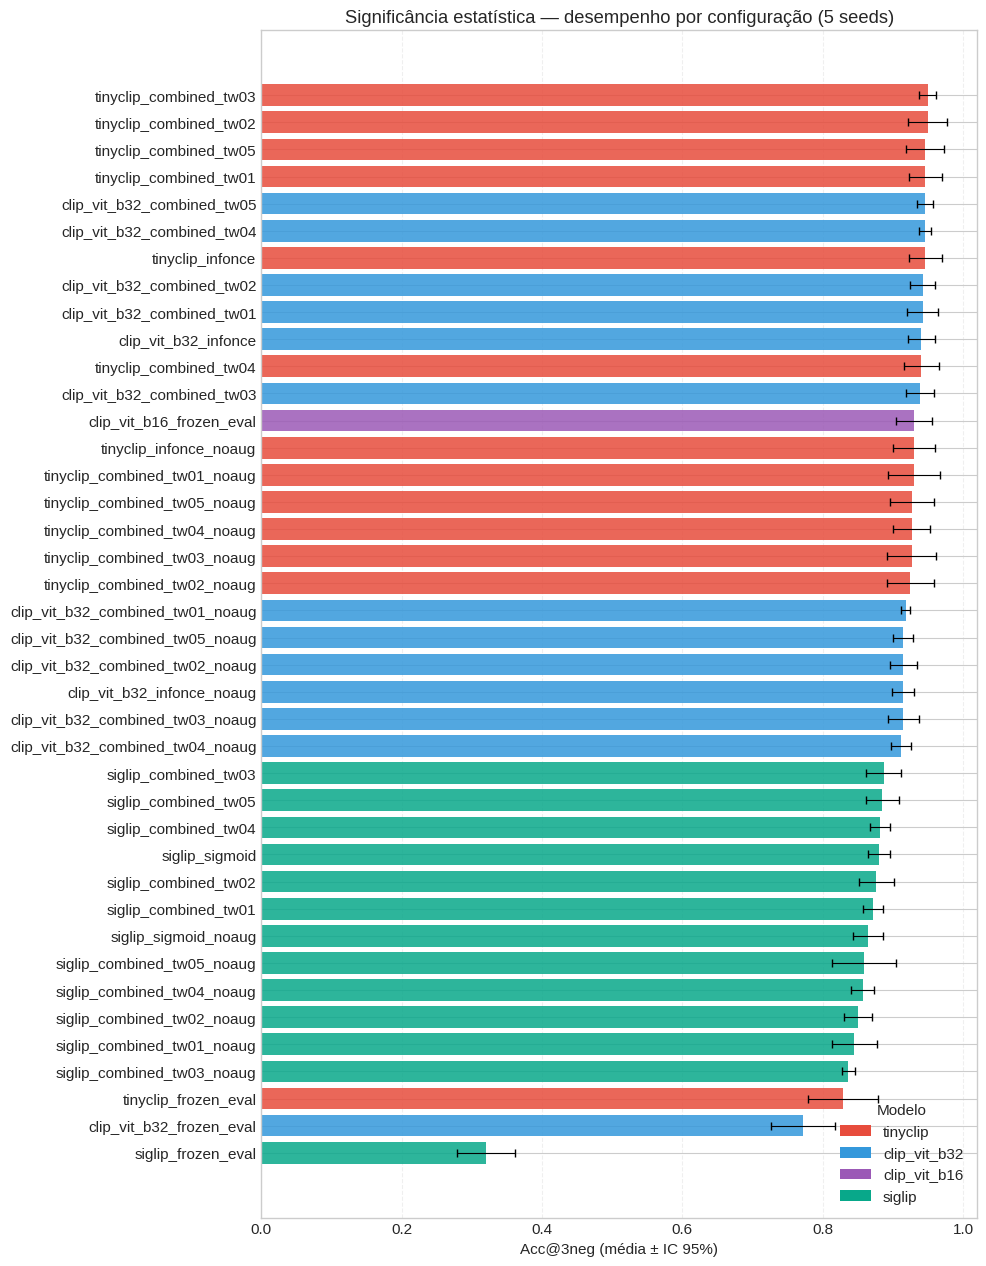

In [18]:
# Significância: figura média ± IC 95% por configuração
data = summary.sort_values(f"{PRIMARY}_mean", ascending=True)
model_colors = {"tinyclip": "#e74c3c", "clip_vit_b32": "#3498db",
                "clip_vit_b16": "#9b59b6", "siglip": "#08A88A"}
bar_colors = [model_colors.get(mm, "#95a5a6") for mm in data["model"]]

fig, ax = plt.subplots(figsize=(10, max(6, 0.32 * len(data))))
ax.barh(data["config"], data[f"{PRIMARY}_mean"],
        xerr=data[f"{PRIMARY}_ci95"], capsize=3,
        error_kw={"elinewidth": 0.8}, color=bar_colors, alpha=0.85)
ax.set_xlabel("Acc@3neg (média ± IC 95%)")
ax.set_title("Significância estatística — desempenho por configuração (5 seeds)")
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.set_xlim(0, 1.02)

from matplotlib.patches import Patch
legend = [Patch(facecolor=c, label=m) for m, c in model_colors.items()
          if m in set(data["model"])]
ax.legend(handles=legend, loc="lower right", title="Modelo")

plt.tight_layout()
plt.savefig("article_outputs/img_metrics/significance_acc3neg.pdf",
            format="pdf", bbox_inches="tight")
plt.show()

In [19]:
# Exportar todos os resultados
def export_all_results():
    """Exporta resultados em diferentes formatos."""
    output_dir = Path("article_outputs")
    output_dir.mkdir(exist_ok=True)
    
    print("📁 Exportando resultados para:", output_dir.absolute())
    
    df_experiments.to_csv(output_dir / "all_experiments_test.csv", index=False)
    print("   ✅ all_experiments_test.csv")
    
    rq6_ranking.to_csv(output_dir / "ranking_test.csv", index=False)
    print("   ✅ ranking_test.csv")
    
    print(f"\n✅ Todos os resultados de TESTE exportados para {output_dir.absolute()}")

export_all_results()


📁 Exportando resultados para: /home/lucas/Documentos/PósGaduação/UFPR/Mestrado/Projeto/Experimentos/SigAlignGit/notebooks/article_outputs
   ✅ all_experiments_test.csv
   ✅ ranking_test.csv

✅ Todos os resultados de TESTE exportados para /home/lucas/Documentos/PósGaduação/UFPR/Mestrado/Projeto/Experimentos/SigAlignGit/notebooks/article_outputs


## 📊 Análise de Erros do Teste

Carrega os CSVs de erros para análise detalhada.


In [22]:
def load_test_errors(experiment_name: str, num_neg: int = 3):
    """Carrega erros do teste para um experimento específico."""
    
    exp_path = Path(f"../experiments/{experiment_name}/metrics")
    errors_path = exp_path / f"test_errors_{num_neg}neg.csv"
    results_path = exp_path / f"test_results_{num_neg}neg.csv"
    
    if errors_path.exists():
        df_errors = pd.read_csv(errors_path)
        print(f"❌ {len(df_errors)} erros carregados para {experiment_name} ({num_neg} negativos)")
        return df_errors
    else:
        print(f"⚠️ Arquivo de erros não encontrado: {errors_path}")
        return None

# Carregar erros do melhor modelo
best_model = "tinyclip_combined_tw03"
df_errors = load_test_errors(best_model, num_neg=3)

if df_errors is not None and len(df_errors) > 0:
    display(df_errors.head(10))


❌ 8 erros carregados para tinyclip_combined_tw03 (3 negativos)


,expected_name,image_path,positive_similarity,max_negative_similarity,predicted_rank,is_correct,all_similarities,negative_image_paths
0,DARLENE,datasets/dataset-sign-align/signatures/gsa_LAL...,0.249895,0.250377,2,False,"[""0.249895"", ""-0.084115"", ""0.250377"", ""-0.0872...","[""datasets/dataset-sign-align/signatures/nist_..."
1,J B BODER,datasets/dataset-sign-align/signatures/zlw44e0...,0.285629,0.390920,2,False,"[""0.285629"", ""-0.142055"", ""0.015543"", ""0.390920""]","[""datasets/dataset-sign-align/signatures/kex05..."
2,JULIE M SCHRODEN,datasets/dataset-sign-align/signatures/lin01f0...,0.292325,0.319254,2,False,"[""0.292325"", ""-0.036944"", ""-0.035778"", ""0.3192...","[""datasets/dataset-sign-align/signatures/nist_..."
3,KRISTINE DANIELSON,datasets/dataset-sign-align/signatures/gsa_LAR...,0.169498,0.181653,2,False,"[""0.169498"", ""0.099133"", ""-0.056712"", ""0.181653""]","[""datasets/dataset-sign-align/signatures/nist_..."
4,LAURI BOND,datasets/dataset-sign-align/signatures/gsa_LAK...,0.194705,0.211984,2,False,"[""0.194705"", ""0.124888"", ""-0.060511"", ""0.211984""]","[""datasets/dataset-sign-align/signatures/gsa_L..."
5,P HULL,datasets/dataset-sign-align/signatures/nist_r0...,0.139886,0.265011,2,False,"[""0.139886"", ""0.265011"", ""0.095905"", ""0.114881""]","[""datasets/dataset-sign-align/signatures/gsa_L..."
6,R DERAMUS,datasets/dataset-sign-align/signatures/gsa_LAR...,-0.166648,-0.088119,4,False,"[""-0.166648"", ""-0.107560"", ""-0.088119"", ""-0.09...","[""datasets/dataset-sign-align/signatures/nist_..."
7,ROB INGOLD,datasets/dataset-sign-align/signatures/gsa_LAZ...,0.286308,0.338756,3,False,"[""0.286308"", ""0.210742"", ""0.338756"", ""0.331272""]","[""datasets/dataset-sign-align/signatures/nist_..."


In [23]:
# Análise de padrões nos erros
if df_errors is not None and len(df_errors) > 0:
    print("\n📊 Análise de Erros:")
    print(f"   Total de erros: {len(df_errors)}")
    
    if 'positive_similarity' in df_errors.columns:
        print(f"   Similaridade positiva média nos erros: {df_errors['positive_similarity'].mean():.4f}")
    
    if 'predicted_rank' in df_errors.columns:
        print(f"   Rank predito médio: {df_errors['predicted_rank'].mean():.2f}")
        
        print("\n   Distribuição de ranks nos erros:")
        print(df_errors['predicted_rank'].value_counts().sort_index())



📊 Análise de Erros:
   Total de erros: 8
   Similaridade positiva média nos erros: 0.1814
   Rank predito médio: 2.38

   Distribuição de ranks nos erros:
predicted_rank
2    6
3    1
4    1
Name: count, dtype: int64


/tmp/ipykernel_11153/144136721.py:196: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


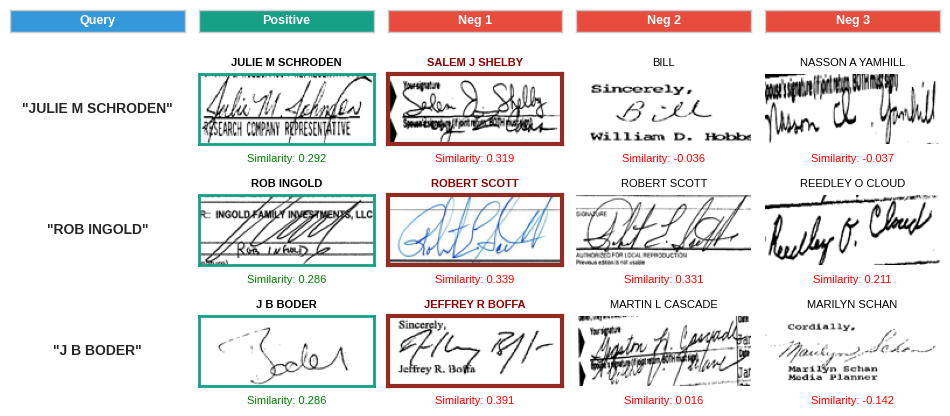

In [24]:
def visualize_error_cases_compact(
    df_errors,
    df_dataset,
    images_base_path,
    n_cases=3,
    figsize=(12, 5),
    img_size=(150, 60)  # 🔥 controle de tamanho padronizado
):
    import matplotlib.pyplot as plt
    from pathlib import Path
    from PIL import Image
    import ast

    if df_errors is None or len(df_errors) == 0:
        print("❌ Nenhum erro")
        return

    # 🔎 lookup nome
    img_to_name = {
        row['image_path']: row['human_name']
        for _, row in df_dataset.iterrows()
    }

    df_errors_sorted = df_errors.sort_values(
        'positive_similarity', ascending=False
    ).head(n_cases)

    sample_negs = ast.literal_eval(
        df_errors_sorted.iloc[0]['negative_image_paths']
    )

    n_cols = 2 + len(sample_negs)

    fig = plt.figure(figsize=(figsize[0], figsize[1]))
    gs = fig.add_gridspec(
        nrows=n_cases + 1,
        ncols=n_cols,
        height_ratios=[0.25] + [1]*n_cases,
        hspace=0.45,
        wspace=0.08
    )

    # =========================
    # 🔷 HEADER
    # =========================
    headers = ['Query', 'Positive'] + [f'Neg {i+1}' for i in range(len(sample_negs))]
    colors = ['#3498DB', '#16A085'] + ['#E74C3C']*len(sample_negs)

    for col, (label, color) in enumerate(zip(headers, colors)):
        ax = fig.add_subplot(gs[0, col])
        ax.set_facecolor(color)
        ax.text(0.5, 0.5, label, color='white',
                ha='center', va='center',
                fontsize=9, fontweight='bold')
        ax.set_xticks([])
        ax.set_yticks([])

    # =========================
    # 🔁 CASOS
    # =========================
    for row_idx, (_, error) in enumerate(df_errors_sorted.iterrows()):
        r = row_idx + 1

        expected_name = error['expected_name']
        pos_path = error['image_path']
        pos_sim = float(error['positive_similarity'])

        all_sims = [float(s) for s in ast.literal_eval(error['all_similarities'])]
        neg_paths = ast.literal_eval(error['negative_image_paths'])
        neg_sims = all_sims[1:]

        # =========================
        # QUERY (texto limpo)
        # =========================
        ax_q = fig.add_subplot(gs[r, 0])
        ax_q.text(0.5, 0.5, f'"{expected_name}"',
                  fontsize=10,
                  fontweight='bold',
                  ha='center',
                  va='center')
        ax_q.axis('off')

        # =========================
        # POSITIVA
        # =========================
        ax_pos = fig.add_subplot(gs[r, 1])

        try:
            img = Image.open(Path(images_base_path) / pos_path).convert('RGB')
            img = img.resize(img_size)
            ax_pos.imshow(img)
        except:
            ax_pos.text(0.5, 0.5, 'Missing', ha='center')

        # 🔤 nome da positiva
        pos_name = img_to_name.get(
            pos_path.replace("datasets/dataset-sign-align/", ""),
            "UNK"
        )

        if len(pos_name) > 16:
            pos_name = pos_name[:14] + "..."

        ax_pos.text(0.5, 1.08, pos_name,
                    transform=ax_pos.transAxes,
                    ha='center',
                    va='bottom',
                    fontsize=8,
                    color='black',
                    fontweight='bold')

        # 🔢 similaridade abaixo
        ax_pos.text(0.5, -0.15, f"Similarity: {pos_sim:.3f}",
                    transform=ax_pos.transAxes,
                    ha='center',
                    va='top',
                    fontsize=8,
                    color='green')

        # borda positiva
        for spine in ax_pos.spines.values():
            spine.set_color('#16A085')
            spine.set_linewidth(2)

        ax_pos.set_xticks([])
        ax_pos.set_yticks([])

        # =========================
        # NEGATIVAS
        # =========================
        neg_data = sorted(zip(neg_paths, neg_sims),
                          key=lambda x: x[1],
                          reverse=True)

        # 🔥 identifica erro real (top-1)
        top_neg_sim = neg_data[0][1]

        for i, (neg_path, neg_sim) in enumerate(neg_data):
            ax = fig.add_subplot(gs[r, 2+i])

            try:
                img = Image.open(Path(images_base_path) / neg_path).convert('RGB')
                img = img.resize(img_size)
                ax.imshow(img)
            except:
                ax.text(0.5, 0.5, 'Missing', ha='center')

            neg_name = img_to_name.get(
                neg_path.replace("datasets/dataset-sign-align/", ""),
                "UNK"
            )

            if len(neg_name) > 16:
                neg_name = neg_name[:14] + "..."

            is_top_wrong = neg_sim == top_neg_sim and neg_sim > pos_sim

            # 🔤 nome centralizado (topo)
            ax.text(0.5, 1.08, neg_name,
                    transform=ax.transAxes,
                    ha='center',
                    va='bottom',
                    fontsize=8,
                    color='darkred' if is_top_wrong else 'black',
                    fontweight='bold' if is_top_wrong else 'normal')

            # 🔢 score (embaixo)
            ax.text(0.5, -0.15, f"Similarity: {neg_sim:.3f}",
                    transform=ax.transAxes,
                    ha='center',
                    va='top',
                    fontsize=8,
                    color='red')

            # 🔥 destaque apenas no erro real
            for spine in ax.spines.values():
                if is_top_wrong:
                    spine.set_color('#922B21')
                    spine.set_linewidth(3)
                else:
                    spine.set_visible(False)

            ax.set_xticks([])
            ax.set_yticks([])

    # =========================
    # TÍTULO
    # =========================
    #fig.suptitle(
        #'Failure Cases: Hard Negative Confusion',
        #fontsize=11,
        #fontweight='bold',
        #y=0.98
    #)

    plt.tight_layout()

    Path('article_outputs/img_metrics').mkdir(parents=True, exist_ok=True)


    plt.savefig(
        "article_outputs/img_metrics/model_error_cases.pdf",
        format="pdf",
        bbox_inches='tight'
    )
    plt.show()

    
visualize_error_cases_compact(
    df_errors,
    df_full_dataset,
    images_base_path=Path("../"),
    n_cases=3
)


In [116]:
df_full_dataset

,document,human_name,llm_name,image_path,source
0,efm53d00,A A MACKINNON,A MACKINNON,signatures/efm53d00_sign3.png,outros
1,cxk72e00-page03_3,ADOLFO KUENNEN,ADOLFO KUENNEN,signatures/cxk72e00-page03_3_sign1.png,outros
2,gsa_LAL50124-SLA-1-_Z-01,ADRIANA SANCHEZ,CHAD SANDS,signatures/gsa_LAL50124-SLA-1-_Z-01_sign3.png,gsa
3,X_031,ALAN X HUM,ALAN L HUM,signatures/X_031_sign1.png,x_dataset
4,nist_r0025_01,ALBUR R BELL,ARTHUR T BELL,signatures/nist_r0025_01_sign2.png,nist
...,...,...,...,...,...
4537,gsa_LAK07329-Lease_Z-01,YVETTE M LUND,YVETTE M LUND,signatures/gsa_LAK07329-Lease_Z-01_sign3.png,gsa
4538,gsa_LAK07345-Lease_Z-01,YVETTE M LYND,YVETTE M LYND,signatures/gsa_LAK07345-Lease_Z-01_sign2.png,gsa
4539,qit05f00-page2_4,Z B TEEL JR,Z B TEEL JR,signatures/qit05f00-page2_4_sign1.png,outros
4540,qit05f00-page2_6,Z B TEEL JR,Z B TEEL JR,signatures/qit05f00-page2_6_sign1.png,outros


## 3. 🔍 Carregar Modelo para Inferência


In [25]:
from src.inference import SignaturePredictor, SimilarityMatrixVisualizer

# Selecionar o melhor experimento baseado nos resultados de TESTE
SELECTED_EXPERIMENT = "tinyclip_combined_tw03"

# No grid multi-seed, df_experiments['path'] aponta para a 1ª seed (que não tem
# checkpoint baixado). Resolvemos explicitamente o diretório que contém o peso
# treinado, priorizando a MELHOR seed (seed_2: test Acc@3neg=0.9652) e caindo
# para a rodada principal caso os checkpoints por seed não tenham sido baixados.
BEST_RUN_CANDIDATES = [
    f"../experiments/significance/seed_2/{SELECTED_EXPERIMENT}",
    f"../experiments/{SELECTED_EXPERIMENT}",
]

predictor = None
if not df_experiments.empty:
    if SELECTED_EXPERIMENT:
        exp_row = df_experiments[df_experiments['name'] == SELECTED_EXPERIMENT].iloc[0]
    else:
        # Usar o melhor experimento de teste
        best_col = [c for c in df_experiments.columns if 'test_accuracy_3' in str(c)]
        if best_col:
            exp_row = df_experiments.loc[df_experiments[best_col[0]].idxmax()]
        else:
            exp_row = df_experiments.iloc[0]

    # Escolher o diretório que realmente possui checkpoints/best
    model_path = next(
        (c for c in BEST_RUN_CANDIDATES if (Path(c) / "checkpoints" / "best").exists()),
        exp_row['path'],  # fallback: caminho original do df (1ª seed)
    )

    acc3 = exp_row.get('test_accuracy_3_neg', float('nan'))
    print(f"📌 Experimento selecionado: {exp_row['name']}")
    print(f"   Tipo: {exp_row.get('model_type', 'unknown')}")
    print(f"   Test Acc@3neg (média entre seeds): {acc3:.4f}")
    print(f"   Checkpoint path: {model_path}")
    
    try:
        predictor = SignaturePredictor.from_experiment(
            model_path,
            checkpoint="best",
            model_type=exp_row.get('model_type', 'clip')
        )
        print("✅ Modelo carregado com sucesso!")
    except Exception as e:
        print(f"⚠️ Erro ao carregar modelo: {e}")
        import traceback
        traceback.print_exc()
else:
    print("⚠️ Nenhum experimento encontrado.")


📌 Experimento selecionado: tinyclip_combined_tw03
   Tipo: tinyclip
   Test Acc@3neg (média entre seeds): 0.9496
   Checkpoint path: ../experiments/significance/seed_2/tinyclip_combined_tw03
📦 Carregando modelo de: ../experiments/significance/seed_2/tinyclip_combined_tw03/checkpoints/best


Loading weights:   0%|          | 0/302 [00:00<?, ?it/s]

📂 Modelo carregado de: ../experiments/significance/seed_2/tinyclip_combined_tw03/checkpoints/best
✅ Modelo carregado em cpu
✅ Modelo carregado com sucesso!


## 4. 📊 Matriz de Similaridade


In [26]:
# Carregar dataset
dataset_path = project_root / "datasets" / "dataset-sign-align" / "dataset.csv"
df_dataset = None

if dataset_path.exists():
    df_dataset = pd.read_csv(dataset_path)
    df_dataset = df_dataset[df_dataset['human_name'] != 'UNKNOWN'].reset_index(drop=True)
    print(f"📊 Dataset carregado: {len(df_dataset)} amostras")
    display(df_dataset.head())
else:
    print(f"⚠️ Dataset não encontrado em: {dataset_path}")


📊 Dataset carregado: 3647 amostras


,document,human_name,llm_name,image_path,source
0,efm53d00,A A MACKINNON,A MACKINNON,signatures/efm53d00_sign3.png,outros
1,cxk72e00-page03_3,ADOLFO KUENNEN,ADOLFO KUENNEN,signatures/cxk72e00-page03_3_sign1.png,outros
2,gsa_LAL50124-SLA-1-_Z-01,ADRIANA SANCHEZ,CHAD SANDS,signatures/gsa_LAL50124-SLA-1-_Z-01_sign3.png,gsa
3,X_031,ALAN X HUM,ALAN L HUM,signatures/X_031_sign1.png,x_dataset
4,nist_r0025_01,ALBUR R BELL,ARTHUR T BELL,signatures/nist_r0025_01_sign2.png,nist



📊 Matriz de Similaridade (5x5)


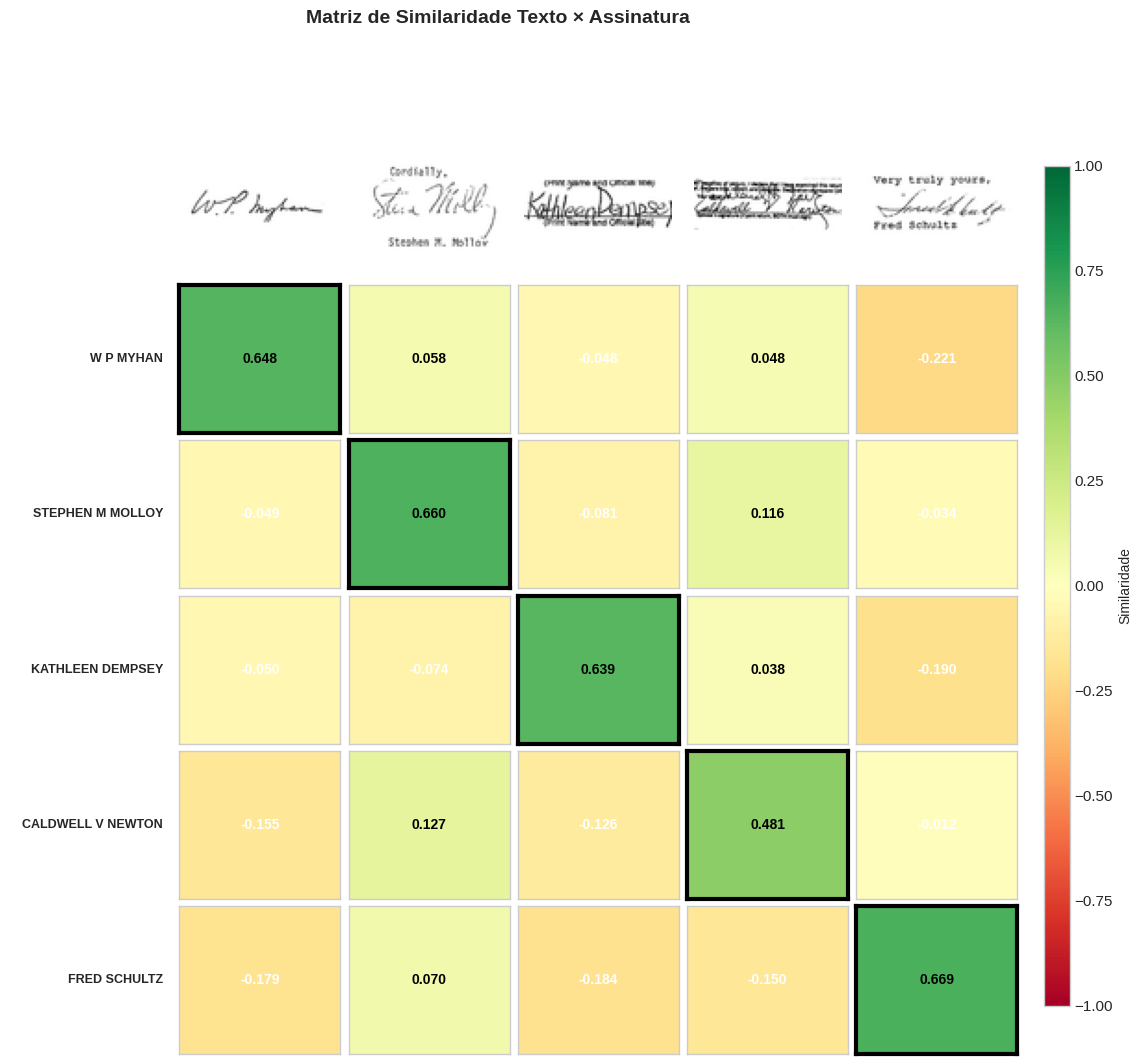

In [27]:
# Criar matriz de similaridade para N textos e N imagens
if predictor is not None and df_dataset is not None:
    N = 5  # Número de amostras
    unique_names = df_dataset['human_name'].unique()
    selected_names = np.random.choice(unique_names, min(N, len(unique_names)), replace=False)
    
    images_base_path = project_root / "datasets" / "dataset-sign-align"
    
    texts = []
    images = []
    for name in selected_names:
        sample = df_dataset[df_dataset['human_name'] == name].iloc[0]
        texts.append(name)
        img_path = images_base_path / sample['image_path']
        images.append(str(img_path))
    
    print(f"\n📊 Matriz de Similaridade ({N}x{N})")
    
    visualizer = SimilarityMatrixVisualizer(predictor)
    sim_matrix = visualizer.plot_similarity_matrix(
        texts=texts,
        images=images,
        title="Matriz de Similaridade Texto × Assinatura",
        highlight_diagonal=True
    )
else:
    print("⚠️ Predictor ou dataset não disponível.")


## 5. 🎯 Visualização com Grad-ECLIP

O método **Grad-ECLIP** (Gradient-based Visual and Textual Explanations for CLIP) produz explicações visuais de maior qualidade que o Attention Rollout tradicional.

**Referência**: Zhao et al., "Grad-ECLIP: Gradient-based Visual and Textual Explanations for CLIP"


In [28]:
# Importar classe GradECLIP do explainability module
try:
    from src.explainability import GradECLIP
    
    if predictor is not None:
        grad_eclip = GradECLIP(predictor.model, device=str(predictor.device))
        print("✅ Grad-ECLIP inicializado com sucesso!")
    else:
        grad_eclip = None
        print("⚠️ Predictor não disponível para Grad-ECLIP")
except ImportError:
    print("⚠️ Módulo GradECLIP não encontrado. Usando implementação inline.")
    grad_eclip = None


✅ Grad-ECLIP inicializado com sucesso!


🔍 Teste Grad-ECLIP:
   Nome: BAYLOR T BUNKS
   Imagem: /home/lucas/Documentos/PósGaduação/UFPR/Mestrado/Projeto/Experimentos/SigAlignGit/datasets/dataset-sign-align/signatures/nist_r0711_01_sign1.png


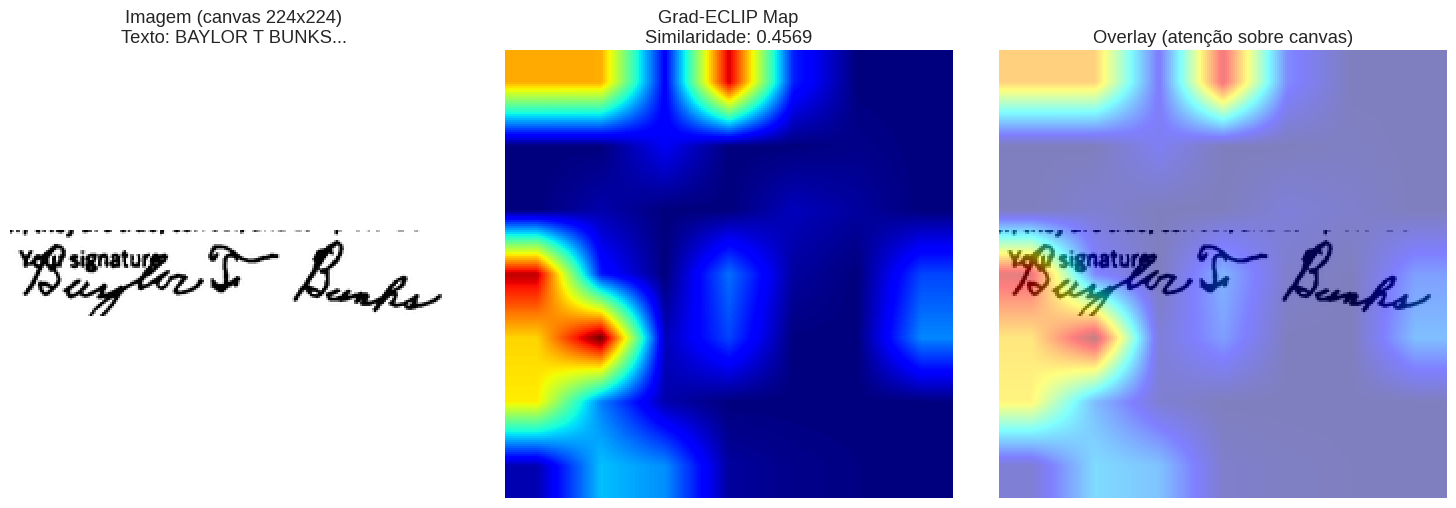


📊 Similaridade: 0.4569


In [35]:
# Testar Grad-ECLIP com uma amostra do dataset
if grad_eclip is not None and df_dataset is not None:
    sample = df_dataset.sample(6).iloc[0]
    
    images_base_path = project_root / "datasets" / "dataset-sign-align"
    image_path = str(images_base_path / sample['image_path'])
    text = sample['human_name']
    
    print(f"🔍 Teste Grad-ECLIP:")
    print(f"   Nome: {text}")
    print(f"   Imagem: {image_path}")
    
    result = grad_eclip.visualize(
        image_path=image_path,
        text=text,
        alpha=0.5
    )
    
    print(f"\n📊 Similaridade: {result['similarity']:.4f}")
else:
    print("⚠️ Grad-ECLIP ou dataset não disponível.")


## 6. 🎯 Aplicação Prática: Recuperação de Assinaturas em Documentos Multi-Assinatura

**Cenário Real**: Dado um documento com múltiplas assinaturas, o modelo consegue identificar corretamente qual assinatura pertence a qual nome?

**Protocolo de Avaliação**:
1. Selecionar documentos com 2+ assinaturas (excluindo UNKNOWN)
2. Para cada documento: dado um nome, verificar se o modelo retorna a assinatura correta como mais similar
3. Calcular Accuracy@1 (top-1), Accuracy@2 (nas 2 primeiras), etc.


In [36]:
import torch
import torch.nn.functional as F
from tqdm.notebook import tqdm
from PIL import Image

# Pré-processamento igual ao treinamento
def paste_center_on_canvas(img, canvas_size=224, background=(255, 255, 255)):
    """Centraliza imagem em canvas quadrado com background branco."""
    img = img.convert("RGBA")
    w, h = img.size
    scale = min(canvas_size / w, canvas_size / h)
    new_w, new_h = int(w * scale), int(h * scale)
    img_resized = img.resize((new_w, new_h), Image.LANCZOS)
    canvas = Image.new("RGBA", (canvas_size, canvas_size), color=background + (255,))
    offset = ((canvas_size - new_w) // 2, (canvas_size - new_h) // 2)
    canvas.paste(img_resized, offset, img_resized)
    return canvas.convert("RGB")

def prepare_multi_signature_documents(df, min_signatures=2):
    """Prepara documentos com múltiplas assinaturas para avaliação."""
    df_known = df[df['human_name'] != 'UNKNOWN'].copy()
    doc_groups = df_known.groupby('document')
    
    valid_docs = {}
    for doc_name, group in doc_groups:
        unique_signers = group['human_name'].nunique()
        if unique_signers >= min_signatures:
            signatures = []
            for name in group['human_name'].unique():
                sample = group[group['human_name'] == name].iloc[0]
                signatures.append({
                    'name': name,
                    'image_path': sample['image_path']
                })
            valid_docs[doc_name] = signatures
    
    return valid_docs

# Carregar dataset completo
dataset_path = project_root / "datasets" / "dataset-sign-align" / "dataset.csv"
df_full = pd.read_csv(dataset_path)

# Preparar documentos multi-assinatura
multi_sig_docs = prepare_multi_signature_documents(df_full, min_signatures=2)

print(f"📊 Estatísticas de Documentos Multi-Assinatura:")
print(f"   Total de documentos válidos: {len(multi_sig_docs)}")

sig_counts = [len(sigs) for sigs in multi_sig_docs.values()]
print(f"\n   Distribuição de assinaturas por documento:")
for n in sorted(set(sig_counts)):
    count = sig_counts.count(n)
    print(f"     {n} assinaturas: {count} documentos")

print(f"\n   Total de queries (nome→assinatura): {sum(sig_counts)}")


📊 Estatísticas de Documentos Multi-Assinatura:
   Total de documentos válidos: 1115

   Distribuição de assinaturas por documento:
     2 assinaturas: 693 documentos
     3 assinaturas: 412 documentos
     4 assinaturas: 5 documentos
     5 assinaturas: 1 documentos
     7 assinaturas: 2 documentos
     8 assinaturas: 2 documentos

   Total de queries (nome→assinatura): 2677


In [37]:
def evaluate_signature_retrieval(predictor, documents, images_base_path, show_progress=True, image_size=224):
    """Avalia o modelo na tarefa de recuperação de assinaturas."""
    model = predictor.model
    processor = predictor.processor
    device = predictor.device
    
    model.model.eval()
    
    results = []
    all_ranks = []
    correct_top1 = 0
    correct_top2 = 0
    total_queries = 0
    
    doc_iterator = tqdm(documents.items(), desc="Avaliando documentos") if show_progress else documents.items()
    
    with torch.no_grad():
        for doc_name, signatures in doc_iterator:
            n_sigs = len(signatures)
            
            images = []
            names = []
            
            for sig in signatures:
                img_path = images_base_path / sig['image_path']
                img = Image.open(img_path)
                img = paste_center_on_canvas(img, canvas_size=image_size)
                images.append(img)
                names.append(sig['name'])
            
            image_inputs = processor(images=images, return_tensors="pt", padding=True)
            image_inputs = {k: v.to(device) for k, v in image_inputs.items() if k == 'pixel_values'}
            
            image_embeds = model.get_image_features(**image_inputs)
            image_embeds = F.normalize(image_embeds, dim=-1)
            
            for query_idx, query_name in enumerate(names):
                text_inputs = processor(text=[query_name], return_tensors="pt", padding=True)
                text_inputs = {k: v.to(device) for k, v in text_inputs.items() if k in ['input_ids', 'attention_mask']}
                
                text_embed = model.get_text_features(**text_inputs)
                text_embed = F.normalize(text_embed, dim=-1)
                
                similarities = (text_embed @ image_embeds.T).squeeze(0).cpu().numpy()
                ranking = np.argsort(-similarities)
                correct_rank = np.where(ranking == query_idx)[0][0] + 1
                all_ranks.append(correct_rank)
                
                if correct_rank == 1:
                    correct_top1 += 1
                if correct_rank <= 2:
                    correct_top2 += 1
                
                total_queries += 1
                
                results.append({
                    'document': doc_name,
                    'query_name': query_name,
                    'n_candidates': n_sigs,
                    'correct_rank': correct_rank,
                    'is_top1': correct_rank == 1,
                    'similarities': similarities.tolist(),
                    'names': names
                })
    
    metrics = {
        'total_documents': len(documents),
        'total_queries': total_queries,
        'accuracy_top1': correct_top1 / total_queries,
        'accuracy_top2': correct_top2 / total_queries,
        'mean_rank': np.mean(all_ranks),
        'median_rank': np.median(all_ranks),
        'mrr': np.mean([1/r for r in all_ranks]),
    }
    
    return metrics, results, all_ranks

# Executar avaliação
if predictor is not None:
    print("🔍 Iniciando avaliação prática de recuperação de assinaturas...")
    print("=" * 70)

    images_base_path = project_root / "datasets" / "dataset-sign-align"

    metrics, practical_results, ranks = evaluate_signature_retrieval(
        predictor, 
        multi_sig_docs, 
        images_base_path,
        show_progress=True
    )

    print("\n" + "=" * 70)
    print("📊 RESULTADOS DA AVALIAÇÃO PRÁTICA")
    print("=" * 70)
    print(f"\n📁 Documentos avaliados: {metrics['total_documents']}")
    print(f"🔍 Total de queries (nome→assinatura): {metrics['total_queries']}")
    print(f"\n📈 Métricas de Recuperação:")
    print(f"   Accuracy@1 (Top-1):  {metrics['accuracy_top1']:.4f} ({metrics['accuracy_top1']*100:.2f}%)")
    print(f"   Accuracy@2 (Top-2):  {metrics['accuracy_top2']:.4f} ({metrics['accuracy_top2']*100:.2f}%)")
    print(f"   Mean Rank:           {metrics['mean_rank']:.2f}")
    print(f"   Median Rank:         {metrics['median_rank']:.1f}")
    print(f"   MRR:                 {metrics['mrr']:.4f}")
else:
    print("⚠️ Predictor não disponível para avaliação prática.")


🔍 Iniciando avaliação prática de recuperação de assinaturas...


Avaliando documentos:   0%|          | 0/1115 [00:00<?, ?it/s]


📊 RESULTADOS DA AVALIAÇÃO PRÁTICA

📁 Documentos avaliados: 1115
🔍 Total de queries (nome→assinatura): 2677

📈 Métricas de Recuperação:
   Accuracy@1 (Top-1):  0.9832 (98.32%)
   Accuracy@2 (Top-2):  0.9993 (99.93%)
   Mean Rank:           1.02
   Median Rank:         1.0
   MRR:                 0.9915


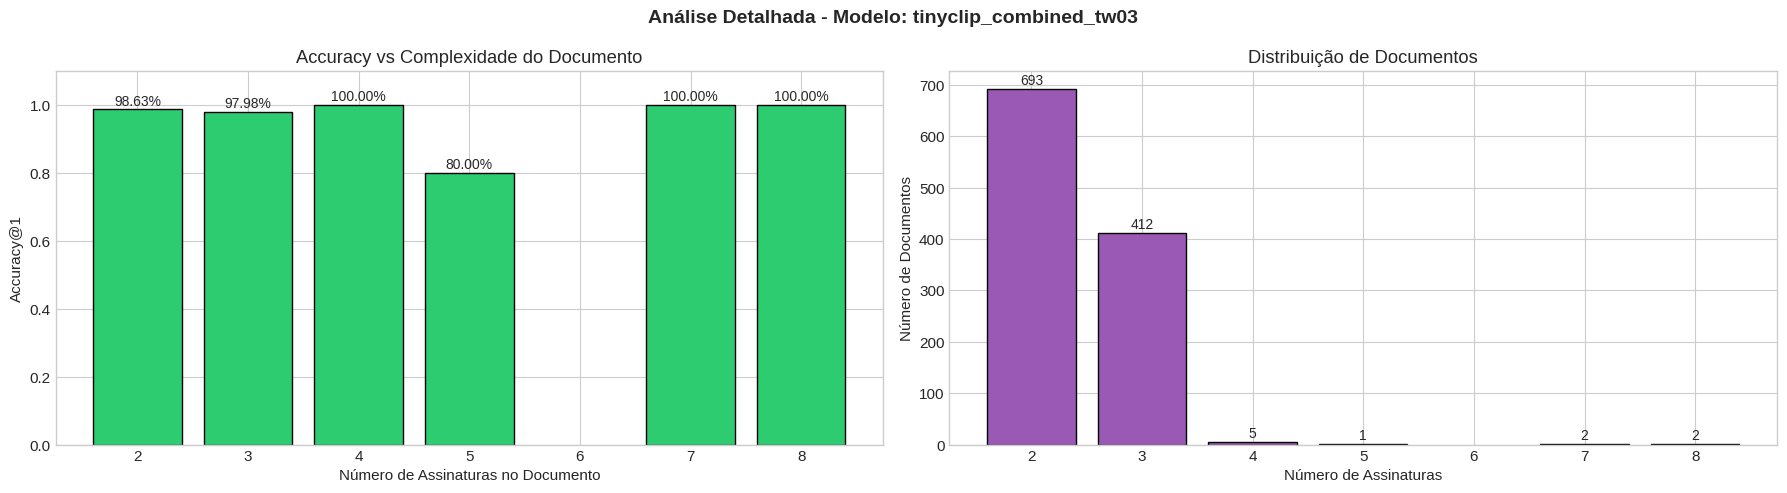


📊 Accuracy por Número de Candidatos:


,Documentos,Queries,Acc@1,Mean Rank,Median Rank
n_candidates,,,,,
2,693,1386,0.9863,1.0137,1.0
3,412,1236,0.9798,1.0218,1.0
4,5,20,1.0000,1.0000,1.0
5,1,5,0.8000,1.2000,1.0
7,2,14,1.0000,1.0000,1.0
8,2,16,1.0000,1.0000,1.0


In [39]:
# Análise detalhada dos resultados
df_results = pd.DataFrame(practical_results)

# Visualização 1: Distribuição dos ranks
fig, axes = plt.subplots(1, 2, figsize=(18, 5))


# Accuracy por número de candidatos
ax2 = axes[0]
acc_by_candidates = df_results.groupby('n_candidates')['is_top1'].mean()
bars = ax2.bar(acc_by_candidates.index, acc_by_candidates.values, color='#2ecc71', edgecolor='black')
ax2.set_xlabel('Número de Assinaturas no Documento')
ax2.set_ylabel('Accuracy@1')
ax2.set_title('Accuracy vs Complexidade do Documento')
ax2.set_ylim(0, 1.1)
for bar, val in zip(bars, acc_by_candidates.values):
    ax2.annotate(f'{val:.2%}', xy=(bar.get_x() + bar.get_width()/2, val),
                 xytext=(0, 3), textcoords="offset points", ha='center', fontsize=10)

# Distribuição de documentos por número de assinaturas
ax3 = axes[1]
doc_counts = df_results.groupby('n_candidates').apply(lambda x: x['document'].nunique())
ax3.bar(doc_counts.index, doc_counts.values, color='#9b59b6', edgecolor='black')
ax3.set_xlabel('Número de Assinaturas')
ax3.set_ylabel('Número de Documentos')
ax3.set_title('Distribuição de Documentos')
for i, v in enumerate(doc_counts.values):
    ax3.annotate(str(v), xy=(doc_counts.index[i], v), xytext=(0, 3), 
                 textcoords="offset points", ha='center', fontsize=10)

plt.suptitle(f'Análise Detalhada - Modelo: {best_model}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('practical_evaluation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabela resumo por complexidade
print("\n📊 Accuracy por Número de Candidatos:")
summary = df_results.groupby('n_candidates').agg({
    'document': 'nunique',
    'query_name': 'count',
    'is_top1': 'mean',
    'correct_rank': ['mean', 'median']
}).round(4)
summary.columns = ['Documentos', 'Queries', 'Acc@1', 'Mean Rank', 'Median Rank']
display(summary)


## 8. ⚡ Análise de Eficiência das Arquiteturas

Comparação de eficiência computacional entre as três arquiteturas:
- **TinyCLIP**: Modelo compacto otimizado para velocidade
- **CLIP-ViT-B/32**: Modelo base da OpenAI
- **SigLIP-B/16**: Modelo do Google com patch menor (mais preciso, mais lento)

Métricas: Parâmetros, GFLOPs, Throughput (pairs/second), Latência


⚡ ANÁLISE DE EFICIÊNCIA DAS ARQUITETURAS

📊 Tabela Comparativa de Eficiência:


,Modelo,Parâmetros (M),GFLOPs,Throughput (pairs/s),Latência @bs32 (ms)
0,TinyCLIP,84.2,10.8,2287,14.0
1,CLIP-ViT-B/32,151.3,18.6,1133,28.3
2,SigLIP-B/16,203.2,52.5,373,85.8


/tmp/ipykernel_11153/896597023.py:87: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_11153/896597023.py:87: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_11153/896597023.py:87: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_11153/896597023.py:87: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_11153/896597023.py:87: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_11153/896597023.py:87: UserWarning: Glyph 9889 (\N{HIGH VOLTAGE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_11153/896597023.py:91: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Liberation Sans.
  plt.savefig('article_ou

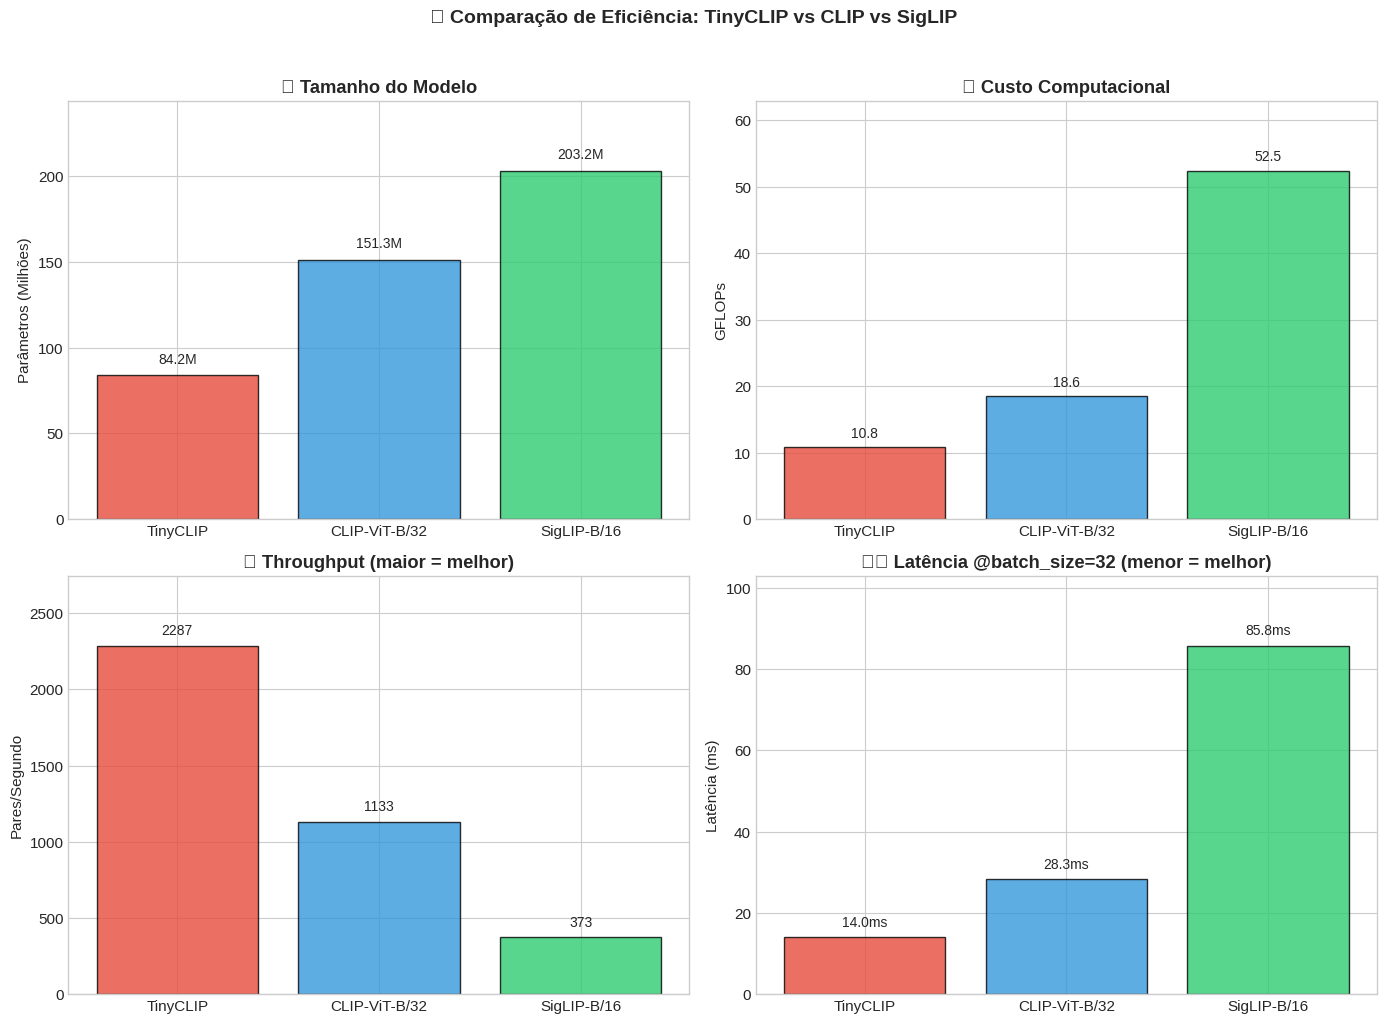


📈 Análise de Trade-off (Eficiência vs Accuracy):
   TinyCLIP: Mais rápido (~6x SigLIP), menor, mas accuracy inferior
   CLIP-B/32: Equilíbrio entre velocidade e accuracy
   SigLIP-B/16: Mais lento (~3x CLIP), mas patches menores capturam mais detalhes


In [40]:
# Carregar e visualizar benchmark de eficiência
def load_and_visualize_efficiency(benchmark_path):
    """
    Carrega resultados de benchmark de eficiência e cria visualizações.
    
    Args:
        benchmark_path: Caminho para o arquivo JSON de benchmark
    """
    if not benchmark_path.exists():
        print(f"⚠️ Arquivo de benchmark não encontrado: {benchmark_path}")
        print("   Execute: python scripts/benchmark_efficiency.py")
        return None
    
    with open(benchmark_path) as f:
        benchmark_data = json.load(f)
    
    print("=" * 70)
    print("⚡ ANÁLISE DE EFICIÊNCIA DAS ARQUITETURAS")
    print("=" * 70)
    
    # Extrair dados
    models = list(benchmark_data.keys())
    params = [benchmark_data[m]['model_info']['parameters']['total_millions'] for m in models]
    gflops = [benchmark_data[m]['flops']['total_gflops'] for m in models]
    throughput = [benchmark_data[m]['throughput']['best_throughput']['pairs_per_second'] for m in models]
    latency_bs32 = [benchmark_data[m]['throughput']['by_batch_size']['batch_32']['latency_mean_ms'] for m in models]
    
    # Criar tabela resumo
    df_efficiency = pd.DataFrame({
        'Modelo': models,
        'Parâmetros (M)': [f"{p:.1f}" for p in params],
        'GFLOPs': [f"{g:.1f}" for g in gflops],
        'Throughput (pairs/s)': [f"{t:.0f}" for t in throughput],
        'Latência @bs32 (ms)': [f"{l:.1f}" for l in latency_bs32]
    })
    
    print("\n📊 Tabela Comparativa de Eficiência:")
    display(df_efficiency)
    
    # Criar visualizações
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    colors = ['#e74c3c', '#3498db', '#2ecc71']
    
    # 1. Parâmetros
    ax = axes[0, 0]
    bars = ax.bar(models, params, color=colors, alpha=0.8, edgecolor='black')
    ax.set_ylabel('Parâmetros (Milhões)')
    ax.set_title('📦 Tamanho do Modelo', fontweight='bold')
    ax.set_ylim(0, max(params) * 1.2)
    for bar, val in zip(bars, params):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
               f'{val:.1f}M', ha='center', va='bottom', fontsize=10)
    
    # 2. GFLOPs
    ax = axes[0, 1]
    bars = ax.bar(models, gflops, color=colors, alpha=0.8, edgecolor='black')
    ax.set_ylabel('GFLOPs')
    ax.set_title('🔢 Custo Computacional', fontweight='bold')
    ax.set_ylim(0, max(gflops) * 1.2)
    for bar, val in zip(bars, gflops):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
               f'{val:.1f}', ha='center', va='bottom', fontsize=10)
    
    # 3. Throughput
    ax = axes[1, 0]
    bars = ax.bar(models, throughput, color=colors, alpha=0.8, edgecolor='black')
    ax.set_ylabel('Pares/Segundo')
    ax.set_title('🚀 Throughput (maior = melhor)', fontweight='bold')
    ax.set_ylim(0, max(throughput) * 1.2)
    for bar, val in zip(bars, throughput):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
               f'{val:.0f}', ha='center', va='bottom', fontsize=10)
    
    # 4. Latência
    ax = axes[1, 1]
    bars = ax.bar(models, latency_bs32, color=colors, alpha=0.8, edgecolor='black')
    ax.set_ylabel('Latência (ms)')
    ax.set_title('⏱️ Latência @batch_size=32 (menor = melhor)', fontweight='bold')
    ax.set_ylim(0, max(latency_bs32) * 1.2)
    for bar, val in zip(bars, latency_bs32):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
               f'{val:.1f}ms', ha='center', va='bottom', fontsize=10)
    
    plt.suptitle('⚡ Comparação de Eficiência: TinyCLIP vs CLIP vs SigLIP', 
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Salvar
    Path('article_outputs/img_efficiency').mkdir(parents=True, exist_ok=True)
    plt.savefig('article_outputs/img_efficiency/architecture_efficiency_comparison.png', 
               dpi=150, bbox_inches='tight')
    plt.show()
    
    # Análise de trade-off
    print("\n📈 Análise de Trade-off (Eficiência vs Accuracy):")
    print("   TinyCLIP: Mais rápido (~6x SigLIP), menor, mas accuracy inferior")
    print("   CLIP-B/32: Equilíbrio entre velocidade e accuracy")
    print("   SigLIP-B/16: Mais lento (~3x CLIP), mas patches menores capturam mais detalhes")
    
    return benchmark_data

# Carregar benchmark
benchmark_path = project_root / "experiments" / "efficiency_benchmark.json"
efficiency_data = load_and_visualize_efficiency(benchmark_path)


In [41]:
# Visualização de exemplos: Sucesso e Falha
def visualize_retrieval_examples(df_results, images_base_path, n_success=3, n_failure=3):
    """
    Mostra exemplos visuais de recuperação de assinaturas.
    """
    # Selecionar exemplos de sucesso (rank=1) e falha (rank>1)
    successes = df_results[df_results['is_top1']].sample(min(n_success, len(df_results[df_results['is_top1']])))
    failures = df_results[~df_results['is_top1']]
    if len(failures) > 0:
        failures = failures.sample(min(n_failure, len(failures)))
    
    # Visualizar
    n_examples = len(successes) + len(failures)
    if n_examples == 0:
        print("Nenhum exemplo para visualizar")
        return
    
    fig, axes = plt.subplots(n_examples, 1, figsize=(16, 4*n_examples))
    if n_examples == 1:
        axes = [axes]
    
    plot_idx = 0
    
    # Plotar sucessos
    for _, row in successes.iterrows():
        ax = axes[plot_idx]
        names = row['names']
        sims = row['similarities']
        query = row['query_name']
        n_sigs = row['n_candidates']
        
        # Carregar e mostrar assinaturas
        images = []
        for i, name in enumerate(names):
            # Encontrar imagem correspondente
            sig = next(s for s in multi_sig_docs[row['document']] if s['name'] == name)
            img = Image.open(images_base_path / sig['image_path']).convert("RGB")
            images.append(img)
        
        # Criar subplot com imagens lado a lado
        for i, (img, name, sim) in enumerate(zip(images, names, sims)):
            # Criar subaxes
            sub_ax = fig.add_axes([0.05 + i*0.9/n_sigs, 0.95 - (plot_idx+1)*0.95/n_examples + 0.02, 
                                   0.85/n_sigs, 0.9/n_examples - 0.04])
            sub_ax.imshow(img)
            color = 'green' if name == query else 'gray'
            border_width = 3 if name == query else 1
            for spine in sub_ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(border_width)
            sub_ax.set_title(f"{name[:15]}...\nSim: {sim:.3f}", fontsize=9, 
                            color='green' if name == query else 'black',
                            fontweight='bold' if name == query else 'normal')
            sub_ax.axis('off')
        
        ax.axis('off')
        ax.set_title(f"✓ SUCESSO - Query: '{query}' | Documento: {row['document'][:30]}...", 
                    fontsize=12, fontweight='bold', color='green', loc='left')
        plot_idx += 1
    
    # Plotar falhas
    for _, row in failures.iterrows():
        ax = axes[plot_idx]
        names = row['names']
        sims = row['similarities']
        query = row['query_name']
        n_sigs = row['n_candidates']
        ranking = row['ranking']
        
        ax.axis('off')
        ax.set_title(f"✗ FALHA - Query: '{query}' | Rank: {row['correct_rank']} | Doc: {row['document'][:30]}...", 
                    fontsize=12, fontweight='bold', color='red', loc='left')
        plot_idx += 1
    
    plt.tight_layout()
    plt.savefig('retrieval_examples.png', dpi=150, bbox_inches='tight')
    plt.show()

# Mostrar exemplos simples (texto)
print("\n" + "=" * 70)
print("📌 EXEMPLOS DE RECUPERAÇÃO")
print("=" * 70)

# Exemplos de SUCESSO
print("\n✅ EXEMPLOS DE SUCESSO (Top-1 correto):")
successes = df_results[df_results['is_top1']].head(5)
for _, row in successes.iterrows():
    print(f"\n   Documento: {row['document'][:40]}...")
    print(f"   Query: '{row['query_name']}'")
    print(f"   Candidatos: {row['n_candidates']} assinaturas")
    print(f"   Similaridades: {[f'{s:.3f}' for s in row['similarities']]}")
    print(f"   Nomes: {row['names']}")

# Exemplos de FALHA
print("\n\n❌ EXEMPLOS DE FALHA (Top-1 incorreto):")
failures = df_results[~df_results['is_top1']]
if len(failures) > 0:
    for _, row in failures.head(5).iterrows():
        print(f"\n   Documento: {row['document'][:40]}...")
        print(f"   Query: '{row['query_name']}'")
        print(f"   Rank correto: {row['correct_rank']} de {row['n_candidates']}")
        print(f"   Similaridades: {[f'{s:.3f}' for s in row['similarities']]}")
        print(f"   Nomes: {row['names']}")
        #predicted_idx = row['ranking'][0]
        #print(f"   Predição Top-1: '{row['names'][predicted_idx]}' (sim={row['similarities'][predicted_idx]:.3f})")
else:
    print("   🎉 Nenhuma falha! O modelo acertou 100%!")



📌 EXEMPLOS DE RECUPERAÇÃO

✅ EXEMPLOS DE SUCESSO (Top-1 correto):

   Documento: agw39d00...
   Query: 'CECIL R HATTON'
   Candidatos: 8 assinaturas
   Similaridades: ['0.531', '0.089', '0.030', '-0.084', '-0.146', '-0.169', '-0.217', '-0.077']
   Nomes: ['CECIL R HATTON', 'COLIN STOKES', 'G D SMITH', 'J H SHERRILL', 'J H WINDER', 'S O JONES', 'W STUART LEAKE', 'WM D HOBBS']

   Documento: agw39d00...
   Query: 'COLIN STOKES'
   Candidatos: 8 assinaturas
   Similaridades: ['-0.035', '0.685', '-0.085', '-0.163', '-0.219', '0.074', '0.135', '0.143']
   Nomes: ['CECIL R HATTON', 'COLIN STOKES', 'G D SMITH', 'J H SHERRILL', 'J H WINDER', 'S O JONES', 'W STUART LEAKE', 'WM D HOBBS']

   Documento: agw39d00...
   Query: 'G D SMITH'
   Candidatos: 8 assinaturas
   Similaridades: ['-0.008', '-0.071', '0.651', '0.180', '-0.017', '0.248', '0.090', '0.064']
   Nomes: ['CECIL R HATTON', 'COLIN STOKES', 'G D SMITH', 'J H SHERRILL', 'J H WINDER', 'S O JONES', 'W STUART LEAKE', 'WM D HOBBS']

   Doc


📄 Visualizando documento: agw39d00


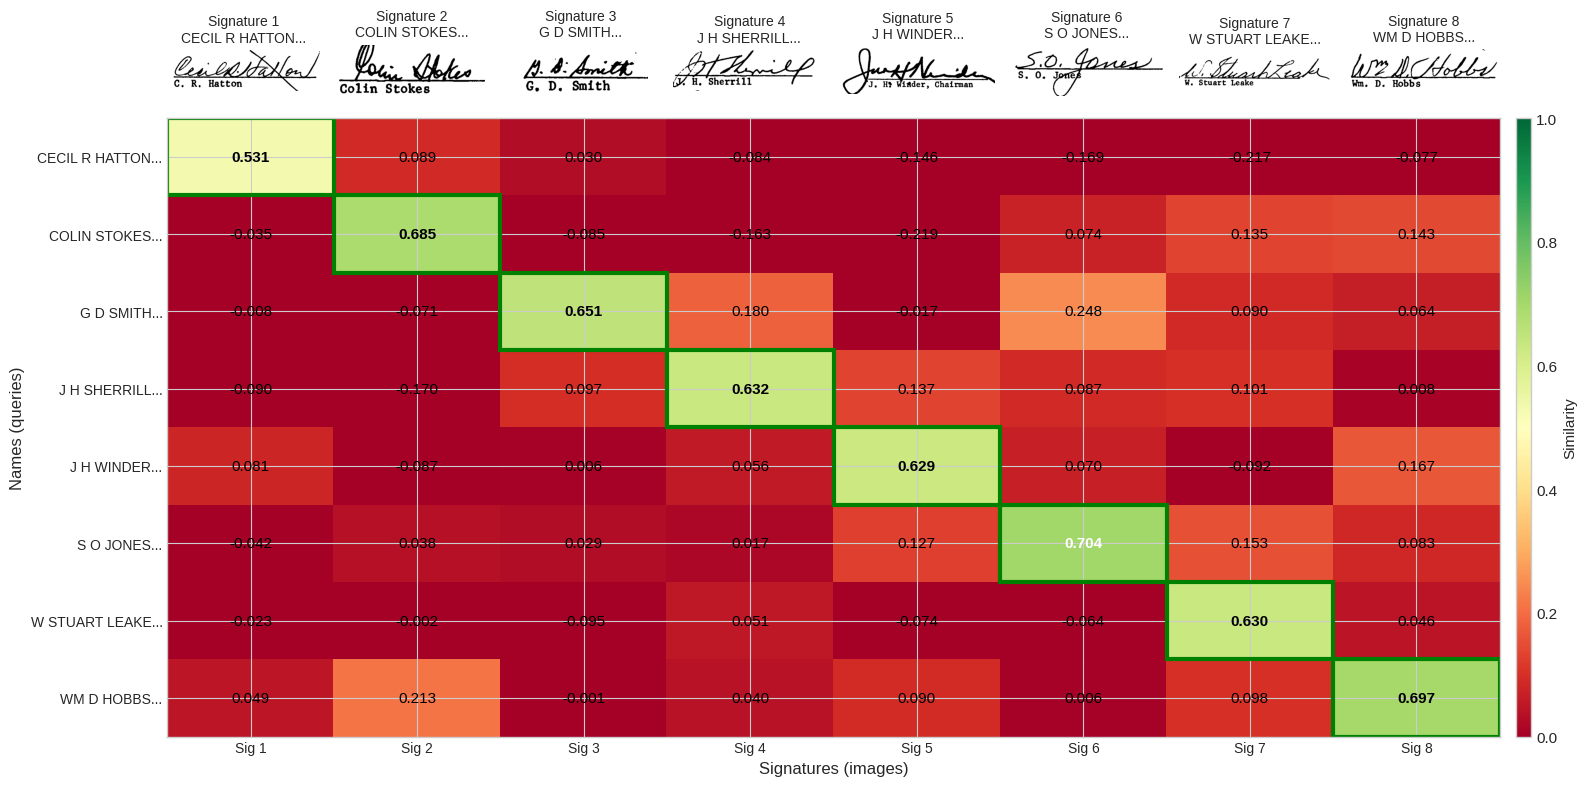


📊 Métricas do Documento:
   Número de assinaturas: 8
   Accuracy: 100.00%
   Predições: [0, 1, 2, 3, 4, 5, 6, 7]
   Correto:   [0, 1, 2, 3, 4, 5, 6, 7]


In [47]:
# Visualização de um documento específico com múltiplas assinaturas
def visualize_document_retrieval(doc_name, documents, predictor, images_base_path):
    """
    Visualiza o processo de retrieval para um documento específico.
    Mostra todas as assinaturas e a matriz de similaridade nome×assinatura.
    """
    if doc_name not in documents:
        print(f"Documento {doc_name} não encontrado!")
        return
    
    signatures = documents[doc_name]
    n_sigs = len(signatures)
    
    model = predictor.model
    processor = predictor.processor
    device = predictor.device
    
    # Carregar imagens e nomes COM O MESMO PRÉ-PROCESSAMENTO DO TREINAMENTO
    images = []
    images_processed = []  # Para o modelo
    names = []
    for sig in signatures:
        img_path = images_base_path / sig['image_path']
        img_raw = Image.open(img_path).convert("RGB")  # Para visualização
        img_processed = paste_center_on_canvas(Image.open(img_path), canvas_size=224)  # Para o modelo
        images.append(img_raw)
        images_processed.append(img_processed)
        names.append(sig['name'])
    
    # Obter embeddings
    model.model.eval()
    with torch.no_grad():
        # Imagens (usar as processadas com canvas!)
        image_inputs = processor(images=images_processed, return_tensors="pt", padding=True)
        image_inputs = {k: v.to(device) for k, v in image_inputs.items() if k == 'pixel_values'}
        image_embeds = model.get_image_features(**image_inputs)
        image_embeds = F.normalize(image_embeds, dim=-1)
        
        # Textos
        text_inputs = processor(text=names, return_tensors="pt", padding=True)
        text_inputs = {k: v.to(device) for k, v in text_inputs.items() if k in ['input_ids', 'attention_mask']}
        text_embeds = model.get_text_features(**text_inputs)
        text_embeds = F.normalize(text_embeds, dim=-1)
        
        # Matriz de similaridade
        sim_matrix = (text_embeds @ image_embeds.T).cpu().numpy()
    
    # Visualização
    fig = plt.figure(figsize=(16, 8))
    
    # Grid: assinaturas no topo, matriz embaixo
    gs = fig.add_gridspec(2, n_sigs + 1, height_ratios=[0.1, 1.2], width_ratios=[1]*n_sigs + [0.1])
    
    # Mostrar assinaturas
    for i, (img, name) in enumerate(zip(images, names)):
        ax = fig.add_subplot(gs[0, i])
        ax.imshow(img)
        ax.set_title(f"Signature {i+1}\n{name[:20]}...", fontsize=10)
        ax.axis('off')
    
    # Matriz de similaridade
    ax_matrix = fig.add_subplot(gs[1, :-1])
    im = ax_matrix.imshow(sim_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    
    # Labels
    ax_matrix.set_xticks(range(n_sigs))
    ax_matrix.set_xticklabels([f"Sig {i+1}" for i in range(n_sigs)], fontsize=10)
    ax_matrix.set_yticks(range(n_sigs))
    ax_matrix.set_yticklabels([f"{n[:15]}..." for n in names], fontsize=10)
    ax_matrix.set_xlabel("Signatures (images)", fontsize=12)
    ax_matrix.set_ylabel("Names (queries)", fontsize=12)
    
    # Valores na matriz
    for i in range(n_sigs):
        for j in range(n_sigs):
            color = 'white' if sim_matrix[i, j] > 0.7 else 'black'
            weight = 'bold' if i == j else 'normal'
            ax_matrix.text(j, i, f'{sim_matrix[i, j]:.3f}', ha='center', va='center', 
                          color=color, fontweight=weight, fontsize=11)
    
    # Destacar diagonal (matches corretos)
    for i in range(n_sigs):
        rect = plt.Rectangle((i-0.5, i-0.5), 1, 1, fill=False, edgecolor='green', linewidth=3)
        ax_matrix.add_patch(rect)
    
    # Colorbar
    ax_cb = fig.add_subplot(gs[1, -1])
    plt.colorbar(im, cax=ax_cb, label='Similarity')
    
    #plt.suptitle(f"Documento: {doc_name[:50]}...\nSimilarity Matrix Name × Signature", 
                #fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('document_retrieval_example.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Calcular accuracy para este documento
    predictions = np.argmax(sim_matrix, axis=1)
    correct = np.arange(n_sigs)
    accuracy = (predictions == correct).mean()
    
    print(f"\n📊 Métricas do Documento:")
    print(f"   Número de assinaturas: {n_sigs}")
    print(f"   Accuracy: {accuracy:.2%}")
    print(f"   Predições: {predictions.tolist()}")
    print(f"   Correto:   {correct.tolist()}")

# Selecionar um documento com pelo menos 3 assinaturas para visualização interessante
docs_with_3plus = {k: v for k, v in multi_sig_docs.items() if len(v) >= 3}
if docs_with_3plus:
    sample_doc = list(docs_with_3plus.keys())[0]
    print(f"\n📄 Visualizando documento: {sample_doc}")
    visualize_document_retrieval(sample_doc, multi_sig_docs, predictor, images_base_path)
else:
    print("Nenhum documento com 3+ assinaturas encontrado")


## 9. 🏢 Análise do Dataset Interno

Estudo no dataset proprietário com os **3 melhores modelos** (CLIP-B/32, TinyCLIP, SigLIP), cada um em **3 esquemas**:

1. **Frozen**: modelo base off-the-shelf (encoders congelados), avaliado no `val.csv` interno.
2. **Pretrained (transfer)**: melhor checkpoint treinado no dataset público, avaliado no `val.csv` interno (sem treino).
3. **Finetuned**: finetuning no `train.csv` interno com a melhor configuração de cada modelo.

Total: **3 × 3 = 9 experimentos** (`internal_<modelo>_<esquema>`), gerados por `scripts/run_internal_experiments_v2.sh`.

**Nota**: o dataset interno não possui split de teste, portanto as métricas vêm do `val.csv` (`val_history.json`) — a tabela usa `test_*` quando existir e cai para `val_*` caso contrário.


In [48]:
# Carregar resultados dos experimentos internos (3 modelos × 3 esquemas)
INTERNAL_MODELS = {
    "clip_vit_b32": "CLIP-B/32",
    "tinyclip": "TinyCLIP",
    "siglip": "SigLIP",
}
INTERNAL_SCHEMES = {
    "frozen": "Frozen",
    "pretrained": "Pretrained",
    "finetuned": "Finetuned",
}
INTERNAL_METRICS = [
    ("accuracy_1_neg", "Acc@1neg"),
    ("accuracy_2_neg", "Acc@2neg"),
    ("accuracy_3_neg", "Acc@3neg"),
    ("mrr_3_neg", "MRR@3neg"),
    ("mean_pos_similarity", "Sim+"),
    ("mean_neg_similarity", "Sim-"),
    ("similarity_gap", "Gap"),
]

def _resolve_internal_metric(metrics, key):
    """test_<key> > val_<key> > <key> (o dataset interno só tem val)."""
    for cand in (f"test_{key}", f"val_{key}", key):
        if metrics.get(cand) is not None:
            return metrics[cand]
    return None

def load_internal_grid(experiments_path):
    """Carrega os experimentos internal_<modelo>_<esquema> em um DataFrame tidy."""
    internal_path = Path(experiments_path) / "internal"
    rows = []
    for mkey, mlabel in INTERNAL_MODELS.items():
        for skey, slabel in INTERNAL_SCHEMES.items():
            name = f"internal_{mkey}_{skey}"
            exp_dir = internal_path / name
            if not exp_dir.exists():
                continue
            test_f = exp_dir / "metrics" / "test_metrics.json"
            val_f = exp_dir / "metrics" / "val_history.json"
            if test_f.exists():
                metrics = json.load(open(test_f)); source = "test"
            elif val_f.exists():
                hist = json.load(open(val_f))
                metrics = hist[-1] if isinstance(hist, list) and hist else {}
                source = "val_history"
            else:
                metrics = {}; source = "none"
            row = {"model_key": mkey, "Modelo": mlabel,
                   "scheme_key": skey, "Esquema": slabel,
                   "name": name, "source": source}
            for k, lbl in INTERNAL_METRICS:
                row[lbl] = _resolve_internal_metric(metrics, k)
            rows.append(row)
            print(f"✅ {name} (fonte: {source})")
    if not rows:
        print("⚠️ Nenhum experimento 'internal_<modelo>_<esquema>' encontrado.")
        print("   Rode: bash scripts/run_internal_experiments_v2.sh")
    return pd.DataFrame(rows)

internal_base = (project_root / "experiments") if "project_root" in globals() else Path("../experiments")
df_internal = load_internal_grid(internal_base)

print(f"\n📊 Experimentos internos carregados: {len(df_internal)} (de 9 possíveis)")
if len(df_internal):
    display(df_internal[["Modelo", "Esquema", "source",
                         "Acc@1neg", "Acc@2neg", "Acc@3neg", "Gap"]].round(4))


✅ internal_clip_vit_b32_frozen (fonte: val_history)
✅ internal_clip_vit_b32_pretrained (fonte: val_history)
✅ internal_clip_vit_b32_finetuned (fonte: val_history)
✅ internal_tinyclip_frozen (fonte: val_history)
✅ internal_tinyclip_pretrained (fonte: val_history)
✅ internal_tinyclip_finetuned (fonte: val_history)
✅ internal_siglip_frozen (fonte: val_history)
✅ internal_siglip_pretrained (fonte: val_history)
✅ internal_siglip_finetuned (fonte: val_history)

📊 Experimentos internos carregados: 9 (de 9 possíveis)


,Modelo,Esquema,source,Acc@1neg,Acc@2neg,Acc@3neg,Gap
0,CLIP-B/32,Frozen,val_history,0.7207,0.5856,0.4865,0.0138
1,CLIP-B/32,Pretrained,val_history,0.8559,0.7748,0.7117,0.1482
2,CLIP-B/32,Finetuned,val_history,0.9099,0.8739,0.8378,0.2531
3,TinyCLIP,Frozen,val_history,0.7027,0.6126,0.5586,0.0329
4,TinyCLIP,Pretrained,val_history,0.8649,0.7928,0.7748,0.1541
5,TinyCLIP,Finetuned,val_history,0.9099,0.8649,0.8378,0.2578
6,SigLIP,Frozen,val_history,0.5586,0.3964,0.2793,0.0013
7,SigLIP,Pretrained,val_history,0.8018,0.5766,0.4595,0.0988
8,SigLIP,Finetuned,val_history,0.8829,0.8378,0.7477,0.3356


In [49]:
# Comparação: pivôs por modelo × esquema (dataset interno)
MODEL_ORDER = ["TinyCLIP", "CLIP-B/32", "SigLIP"]
SCHEME_ORDER = ["Frozen", "Pretrained", "Finetuned"]

def internal_pivot(df, metric):
    p = df.pivot_table(index="Modelo", columns="Esquema", values=metric, aggfunc="first")
    p = p.reindex(index=[m for m in MODEL_ORDER if m in p.index],
                  columns=[s for s in SCHEME_ORDER if s in p.columns])
    return p

if len(df_internal):
    print("=" * 80)
    print("📊 COMPARAÇÃO: Dataset Interno — modelo × esquema")
    print("=" * 80)
    for metric in ["Acc@3neg", "Acc@1neg", "Gap"]:
        print(f"\n🔹 {metric} (linhas = modelo, colunas = esquema):")
        display(internal_pivot(df_internal, metric).round(4))

    # Ganho de finetuning sobre o baseline frozen, por modelo
    pa = internal_pivot(df_internal, "Acc@3neg")
    if {"Frozen", "Finetuned"}.issubset(pa.columns):
        print("\n📈 Ganho Acc@3neg (Finetuned − Frozen) por modelo:")
        display((pa["Finetuned"] - pa["Frozen"]).round(4).to_frame("Δ Acc@3neg (FT − Frozen)"))
    # Ganho do transfer (pretrained) sobre o frozen
    if {"Frozen", "Pretrained"}.issubset(pa.columns):
        print("\n📈 Ganho Acc@3neg (Pretrained − Frozen) por modelo:")
        display((pa["Pretrained"] - pa["Frozen"]).round(4).to_frame("Δ Acc@3neg (Transfer − Frozen)"))
else:
    print("⚠️ Nenhum experimento interno encontrado. Execute os experimentos primeiro.")


📊 COMPARAÇÃO: Dataset Interno — modelo × esquema

🔹 Acc@3neg (linhas = modelo, colunas = esquema):


Esquema,Frozen,Pretrained,Finetuned
Modelo,,,
TinyCLIP,0.5586,0.7748,0.8378
CLIP-B/32,0.4865,0.7117,0.8378
SigLIP,0.2793,0.4595,0.7477



🔹 Acc@1neg (linhas = modelo, colunas = esquema):


Esquema,Frozen,Pretrained,Finetuned
Modelo,,,
TinyCLIP,0.7027,0.8649,0.9099
CLIP-B/32,0.7207,0.8559,0.9099
SigLIP,0.5586,0.8018,0.8829



🔹 Gap (linhas = modelo, colunas = esquema):


Esquema,Frozen,Pretrained,Finetuned
Modelo,,,
TinyCLIP,0.0329,0.1541,0.2578
CLIP-B/32,0.0138,0.1482,0.2531
SigLIP,0.0013,0.0988,0.3356



📈 Ganho Acc@3neg (Finetuned − Frozen) por modelo:


,Δ Acc@3neg (FT − Frozen)
Modelo,
TinyCLIP,0.2793
CLIP-B/32,0.3514
SigLIP,0.4685



📈 Ganho Acc@3neg (Pretrained − Frozen) por modelo:


,Δ Acc@3neg (Transfer − Frozen)
Modelo,
TinyCLIP,0.2162
CLIP-B/32,0.2252
SigLIP,0.1802


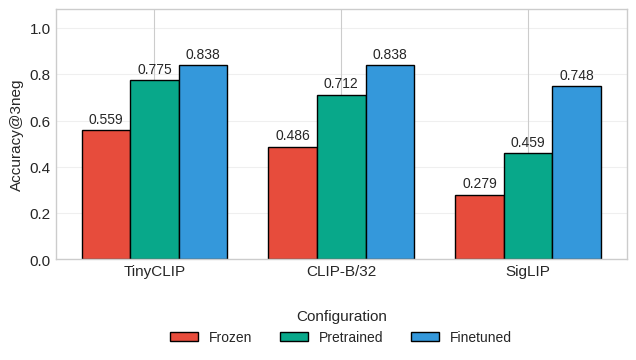

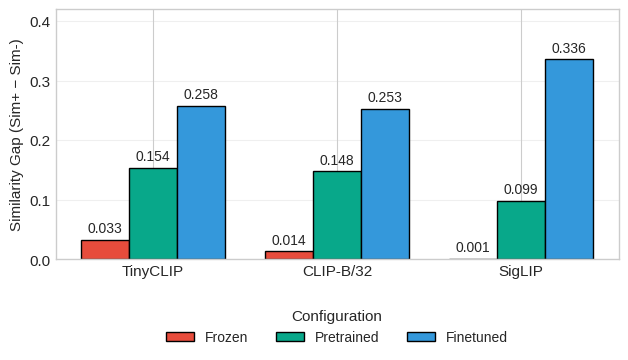

In [63]:
# Visualização comparativa (3 modelos × 3 esquemas)
def plot_internal_grid(df):
    if df is None or len(df) == 0:
        print("❌ Sem dados para visualizar")
        return

    import matplotlib.pyplot as plt
    import numpy as np

    model_order = [m for m in MODEL_ORDER if m in set(df["Modelo"])]
    schemes = [s for s in SCHEME_ORDER if s in set(df["Esquema"])]
    scheme_colors = {"Frozen": "#e74c3c", "Pretrained": "#08A88A", "Finetuned": "#3498db"}

    def grouped(metric, ylabel, ylim, fname):
        fig, ax = plt.subplots(figsize=(6.5, 3.8))
        x = np.arange(len(model_order))
        width = 0.26
        for i, s in enumerate(schemes):
            vals = []
            for m in model_order:
                sub = df[(df["Modelo"] == m) & (df["Esquema"] == s)]
                v = sub[metric].iloc[0] if len(sub) else None
                vals.append(float(v) if v is not None and pd.notna(v) else 0.0)
            off = (i - (len(schemes) - 1) / 2) * width
            bars = ax.bar(x + off, vals, width, label=s,
                          color=scheme_colors.get(s, "#95a5a6"), edgecolor="black")
            for b in bars:
                h = b.get_height()
                if h > 0:
                    ax.annotate(f"{h:.3f}", xy=(b.get_x() + b.get_width() / 2, h),
                                xytext=(0, 3), textcoords="offset points",
                                ha="center", va="bottom", fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(model_order)
        ax.set_ylabel(ylabel)
        ax.set_ylim(*ylim)
        ax.grid(axis="y", alpha=0.3)
        ax.legend(
    fontsize=10,
    title="Configuration",
    ncol=len(schemes),
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15)
)
        plt.tight_layout()
        plt.savefig(f"article_outputs/{fname}", bbox_inches="tight")
        plt.show()

    grouped("Acc@3neg", "Accuracy@3neg", (0, 1.08),
            "internal_acc3neg_grid.pdf")

    gap_max = df["Gap"].max() if df["Gap"].notna().any() else 0.26
    grouped("Gap", "Similarity Gap (Sim+ − Sim-)", (0, max(0.26, float(gap_max) * 1.25)),
            "internal_gap_grid.pdf")

if len(df_internal):
    plot_internal_grid(df_internal)
else:
    print("⚠️ Sem dados para visualizar. Execute os experimentos internos primeiro.")


### 9.1 Visualização do Dataset Interno (Anonimizado)

Amostras do dataset interno com anonimização parcial dos nomes para preservar privacidade.


🏢 DATASET INTERNO (Anonimizado para Privacidade)

📊 Estatísticas:
   Total de amostras: 2272
   Indivíduos únicos: 623


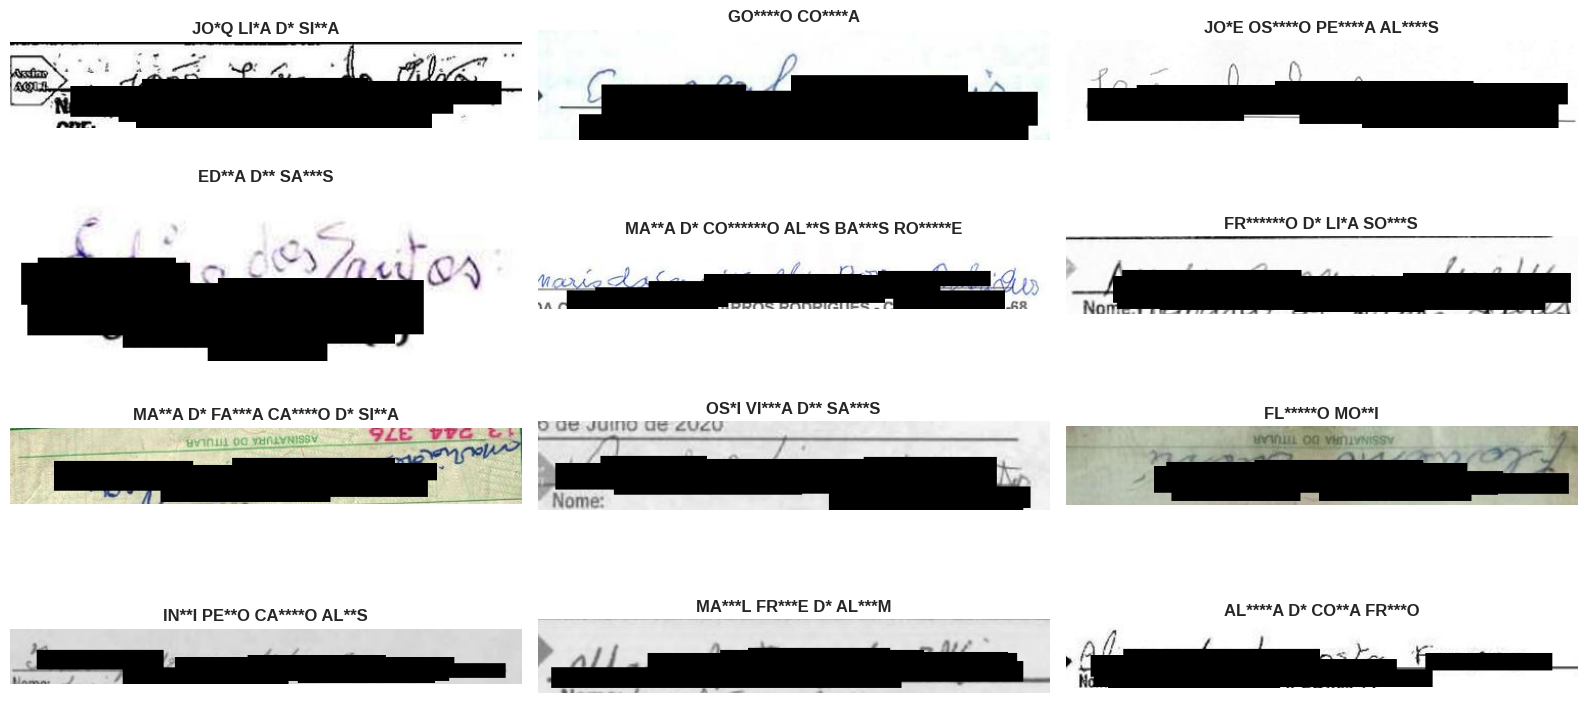


📈 Distribuição de assinaturas por pessoa:
   Mínimo: 1
   Máximo: 83
   Média: 3.6
   Mediana: 2.0


In [28]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image, ImageDraw

# ===============================
# 🔒 Anonimização de Nome
# ===============================
def anonymize_name(name, keep_first=2, keep_last=1):
    """
    Anonimiza parcialmente um nome.
    """
    if pd.isna(name) or not isinstance(name, str):
        return "***"
    
    words = name.split()
    anon_words = []
    
    for word in words:
        if len(word) <= keep_first + keep_last:
            anon_words.append(word[0] + '*' * (len(word)-1))
        else:
            anon_words.append(
                word[:keep_first] +
                '*' * (len(word) - keep_first - keep_last) +
                word[-keep_last:]
            )
    
    return ' '.join(anon_words)


# ===============================
# 🖼️ Anonimização de Imagem
# ===============================
def anonymize_signature_image(
    img,
    n_patches=6,
    min_patch_size=0.15,
    max_patch_size=0.35,
    coverage_bias="bottom"
):
    """
    Aplica múltiplos patches pretos aleatórios na imagem.
    
    Parâmetros:
    - n_patches: número de retângulos pretos
    - min_patch_size / max_patch_size: proporção do tamanho da imagem
    - coverage_bias: "bottom" prioriza parte inferior (onde assinaturas costumam estar)
    """
    img = img.copy()
    draw = ImageDraw.Draw(img)
    w, h = img.size
    
    for _ in range(n_patches):
        patch_w = int(random.uniform(min_patch_size, max_patch_size) * w)
        patch_h = int(random.uniform(min_patch_size, max_patch_size) * h)
        
        x1 = random.randint(0, w - patch_w)
        
        if coverage_bias == "bottom":
            y1 = random.randint(int(h * 0.4), h - patch_h)
        else:
            y1 = random.randint(0, h - patch_h)
        
        x2 = x1 + patch_w
        y2 = y1 + patch_h
        
        draw.rectangle([x1, y1, x2, y2], fill="black")
    
    return img


# ===============================
# 📊 Visualização Anonimizada
# ===============================
def display_internal_dataset_anonymized(rows=3, cols=4, figsize=(16, 8)):
    """
    Exibe amostras do dataset interno com:
    - nomes anonimizados
    - imagens com patches pretos
    """
    internal_train_path = project_root / "datasets" / "internal-dataset" / "train.csv"
    internal_images_path = project_root / "datasets" / "internal-dataset"
    
    if not internal_train_path.exists():
        print(f"⚠️ Dataset interno não encontrado: {internal_train_path}")
        return
    
    df_internal = pd.read_csv(internal_train_path)
    
    print("=" * 70)
    print("🏢 DATASET INTERNO (Anonimizado para Privacidade)")
    print("=" * 70)
    print(f"\n📊 Estatísticas:")
    print(f"   Total de amostras: {len(df_internal)}")
    print(f"   Indivíduos únicos: {df_internal['human_name'].nunique()}")
    
    np.random.seed(2024)
    unique_individuals = df_internal['human_name'].unique()
    n_samples = min(rows * cols, len(unique_individuals))
    selected = np.random.choice(unique_individuals, n_samples, replace=False)
    
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten()
    
    for idx, name in enumerate(selected):
        if idx >= rows * cols:
            break
        
        ax = axes[idx]
        sample = df_internal[df_internal['human_name'] == name].sample(1).iloc[0]
        img_path = internal_images_path / sample['image_path']
        
        try:
            img = Image.open(img_path).convert('RGB')
            
            # 🔒 Aplicar anonimização visual
            img_anon = anonymize_signature_image(
                img,
                n_patches=10,           # aumenta cobertura
                min_patch_size=0.2,
                max_patch_size=0.4
            )
            
            ax.imshow(img_anon)
            
            anon_name = anonymize_name(name)
            ax.set_title(f"{anon_name}", fontsize=12, fontweight='bold')
        
        except Exception:
            ax.text(0.5, 0.5, '[Erro]', ha='center', va='center', fontsize=10)
        
        ax.axis('off')
    
    for idx in range(n_samples, rows * cols):
        axes[idx].axis('off')
    
    plt.tight_layout()
    
    Path('article_outputs/img_dataset').mkdir(parents=True, exist_ok=True)

    plt.savefig(
    "article_outputs/img_dataset/internal_dataset_anonymized.pdf",
    format="pdf",
    bbox_inches='tight'
)
    plt.show()
    
    samples_per_person = df_internal.groupby('human_name').size()
    print(f"\n📈 Distribuição de assinaturas por pessoa:")
    print(f"   Mínimo: {samples_per_person.min()}")
    print(f"   Máximo: {samples_per_person.max()}")
    print(f"   Média: {samples_per_person.mean():.1f}")
    print(f"   Mediana: {samples_per_person.median():.1f}")


# Executar
display_internal_dataset_anonymized(rows=4, cols=3)
